<a href="https://colab.research.google.com/github/meem-5971/Multi-Label-Uterine-Disorders-Diagnosis/blob/main/CV_uterine_diagnosis_new_models(with_resample).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re

# Load the CSV file
df = pd.read_csv("Thesis_data_text_cleaned.csv")

# Clean the Diagnosis column: handle NaN, lowercase, strip, normalize commas and spaces
df['Diagnosis'] = df['Diagnosis'].fillna('').astype(str).str.lower().str.strip()
df['Diagnosis'] = df['Diagnosis'].apply(lambda x: re.sub(r'\s+', ' ', re.sub(r',', ' , ', x)))

# Clean the 'Severe Cramps' column
df['Severe Cramps'] = df['Severe Cramps'].replace(' Yes', 'Yes')

# Clean 'Cycle Length (days)' column
df['Cycle Length (days)'] = df['Cycle Length (days)'].replace({'18-32': '28-32', '<21 ': '<21', '>21': '<21'})

# Clean 'Flow days' column
df['Flow days'] = df['Flow days'].replace({'>5': '>7'})


# Updated and improved group_keywords based on observed diagnoses
# Improvements: Added more keywords from data like "bulky", "prolapsed", "retroverted", "hematometra", "bicornuat", "elongated", "endometrioma",
# "dermoid", "follicular", "prominent ovary", "enlarged ovary", "pid", "cervicitis", "hepatomegaly" to liver, "splenomegaly" to spleno,
# "sol", "gartner", "post partum", "cholelithiasis" specifics, etc.
# Ensured broad coverage to avoid misses; "other" catches unmatched rows.
group_keywords = {
    "pelvic_organ_findings": [
        # Uterus
        "uter", "fibroid", "myoma", "myomet", "adenomyosis", "bulky uterus",
        "retroverted", "globular", "inhomogeneous", "hematometra", "bicornuat",
        "elongated", "mayoma", "fibroid uterus", "endometriotic changes", "low lying uterus",

        # Cervix
        "naboth", "nabothian cyst", "cervix", "cervical",
        "gartner duct cyst", "cervical fibroid",

        # Endometrium
        "endomet", "endometrial", "hyperplasia", "thickened endometrium",
        "thin endometrium", "endometrial collection", "endometrial cavity",
        "clotted blood", "endometritis", "cervicitis", "endometritis", "pid", "pelvic infection",
        "pelvic congestion"
    ],

    "ovary_adnexa_cysts": [
        # Ovary & Adnexa
        "ovary", "ovarian", "ovaries", "adnexal", "ovarian cyst", "endometrioma",
        "dermoid", "follicular cyst", "chocolate cyst", "haemorrhagic cyst",
        "hemorrhagic cyst", "ovarian mass", "adnexal mass", "prominent ovary",
        "enlarged ovary", "ovarian endometriotic cyst", "adnexal cyst",

        # PCOS
        "pcos", "polycystic", "polycystic ovaries", "polycystic appearing",

        # General cyst terms
        "cyst", "cysts", "cystic", "cystic lesion", "septate cyst", "clear cyst"
    ],

    "non_pelvic_systems": [
        # Liver & Gallbladder
        "liver", "fatty", "fatty liver", "hepatomegaly", "biliary",
        "sludge", "gb", "polyp", "chole", "moderate hepatomegaly",

        # Kidney
        "renal", "kidney", "hydronephrosis", "renal calculus",
        "renal cortical cyst", "small kidney",

        # Stones
        "cholelithiasis", "gall stone", "stones", "calculi",

        # Spleen & Pancreas
        "splen", "splenomegaly", "pancreas", "hyperechoic pancreas"
    ],

    "pregnancy_infection_fluid": [
        # Pregnancy-related
        "pregnancy", "post partum", "postpartum", "retained product",
        "incomplete abortion", "early pregnancy",
        "retained product of conception",

        # Infection / UTI
        "cystitis", "uti", "urinary", "infection", "infect",
        "cervicitis", "endometritis", "pid", "pelvic infection",
        "pelvic congestion",

        # Free fluid / collection
        "collection", "free fluid", "fluid collection", "pelvic collection",
        "cul-de-sac", "cul de sac", "ascites"
    ]
}

# Create new columns for each group (except 'other' initially)
for group in group_keywords:
    if group != "other":
        keywords = [k.lower() for k in group_keywords[group]]
        df[f'group_{group}'] = df['Diagnosis'].apply(lambda x: 1 if any(re.search(r'\b' + re.escape(k) + r'\b', x) for k in keywords) else 0)

# For 'other': set to 1 if no other group is 1 (i.e., unmatched diagnosis)
other_cols = [f'group_{g}' for g in group_keywords if g != 'other']
df['group_normal'] = ((df[other_cols].sum(axis=1) == 0) & (df['Diagnosis'] != '')).astype(int)

# Save the updated DataFrame to a new CSV (preserves original serial/SL and all columns)
df.to_csv("Thesis_data_grouped.csv", index=False)

# Print a sample to verify
print(df.head())

   SL    Age         BMI Menopause Cycle Length (days) Flow days Irregularity  \
0   1  36-45      Normal        No               21-27       2-3          Yes   
1   2  18-25      Normal        No                 <21       2-3          Yes   
2   3  36-45  Overweight        No                 <21       2-3          Yes   
3   4  26-35       Obese        No                 >32        >7          Yes   
4   5  26-35  Overweight        No                 >32       4-5          Yes   

  Severe Cramps Heavy Bleeding Clotting  ... Sleep schedule (Hours)  \
0            No            Yes      Yes  ...                  8-Jul   
1           Yes            Yes      Yes  ...                    <4    
2           Yes             No      Yes  ...                    <4    
3           Yes            Yes      Yes  ...                  6-Apr   
4            No             No       No  ...                     <4   

  Stress Level Physical activity  \
0    Sometimes          Moderate   
1    Sometimes

In [ ]:
# Drop rows where 'Diagnosis' is an empty string
df = df[df['Diagnosis'] != '']

print(f"DataFrame shape after dropping rows with empty diagnosis: {df.shape}")

DataFrame shape after dropping rows with empty diagnosis: (216, 34)


In [ ]:
condition = (
    (df["group_normal"] == 0) &
    (df["group_pelvic_organ_findings"] == 0) &
    (df["group_ovary_adnexa_cysts"] == 0) &
    (df["group_non_pelvic_systems"] == 0) &
    (df["group_pregnancy_infection_fluid"] == 1)
)

result = df[condition]

result

,SL,Age,BMI,Menopause,Cycle Length (days),Flow days,Irregularity,Severe Cramps,Heavy Bleeding,Clotting,...,Sleep schedule (Hours),Stress Level,Physical activity,Diagnosis,Unnamed: 28,group_pelvic_organ_findings,group_ovary_adnexa_cysts,group_non_pelvic_systems,group_pregnancy_infection_fluid,group_normal
7,8,18-25,Normal,No,28-32,4-5,Yes,No,Yes,Yes,...,6-Apr,Sometimes,Moderate,early pregnancy,NaN,0,0,0,1,0
15,16,18-25,Normal,No,28-32,2-3,No,No,No,No,...,<4,Sometimes,Moderate,suggestive of cystitis,NaN,0,0,0,1,0
16,17,36-45,Underweight,No,21-27,4-5,Yes,Yes,No,Yes,...,6-Apr,Sometimes,No,suggestive of a case of retained product of co...,NaN,0,0,0,1,0
36,37,26-35,Normal,No,<21,4-5,Yes,Yes,Yes,Yes,...,<4,Sometimes,Moderate,incomplete abortion,NaN,0,0,0,1,0
50,51,18-25,Underweight,No,28-32,NaN,No,No,Yes,Yes,...,6-Apr,Sometimes,No,"suggestive of cystitis , mild pelvic collection",NaN,0,0,0,1,0
57,58,26-35,Normal,No,>32,>7,No,No,Yes,No,...,6-Apr,Sometimes,No,old retained product of conception,NaN,0,0,0,1,0
60,61,>45,Normal,No,>32,>7,Yes,No,Yes,Yes,...,6-Apr,Sometimes,Moderate,mild collection is seen in the cul-de sac,NaN,0,0,0,1,0
66,67,26-35,Normal,No,28-32,>7,No,Yes,Yes,Yes,...,>8,Sometimes,No,mild collection is seen in the cul-de sac,NaN,0,0,0,1,0
84,85,26-35,Normal,No,21-27,4-5,No,No,No,No,...,>8,sometimes,Yes,"mild pelvic collection , cystitis",NaN,0,0,0,1,0
87,88,26-35,Normal,No,21-27,4-5,No,No,No,No,...,8-Jul,No,Yes,"features suggestive of cystitis , pvr: 18.4 cc",NaN,0,0,0,1,0


In [ ]:
df['group_no_reproductive_issue'] = (((df['group_normal'] == 1) |
                                (df['group_non_pelvic_systems'] == 1) |(df["group_pregnancy_infection_fluid"] == 1))&(df["group_pelvic_organ_findings"] == 0) &
    (df["group_ovary_adnexa_cysts"] == 0) ).astype(int)


In [ ]:
df['Clotting'].unique()

array(['Yes', 'No', nan], dtype=object)

In [ ]:
df.drop(columns=['Unnamed: 28','SL'], inplace=True)
df.drop(columns=['Diagnosis'], inplace=True)
df.drop(columns=['group_normal'],inplace=True)
df.drop(columns=['group_non_pelvic_systems'],inplace=True)
df.drop(columns=['group_pregnancy_infection_fluid'],inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
BMI,1
Menopause,0
Cycle Length (days),13
Flow days,14
Irregularity,13
Severe Cramps,13
Heavy Bleeding,13
Clotting,13
Dizziness,13


In [ ]:
df.columns

Index(['Age', 'BMI', 'Menopause', 'Cycle Length (days)', 'Flow days',
       'Irregularity', 'Severe Cramps', 'Heavy Bleeding', 'Clotting',
       'Dizziness', 'Extreme Fatigue', 'Nausea', 'Extreme light flow',
       'Family History', 'Previous History', 'Hair Loss', 'Mood Swing',
       'Excess Facial / Body Hair', 'Acne', 'Sudden Weight gain/loss',
       'Process Food Consumption', 'Sugar Consumption', 'Caffeine Consumption',
       'Sleep schedule (Hours)', 'Stress Level', 'Physical activity',
       'group_pelvic_organ_findings', 'group_ovary_adnexa_cysts',
       'group_no_reproductive_issue'],
      dtype='object')

In [ ]:
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))



===== Age =====
Age
26-35    74
18-25    58
36-45    57
>45      17
<18       7
45        1
26-32     1
>18       1
Name: count, dtype: int64

===== BMI =====
BMI
Normal         109
Underweight     58
Overweight      38
Obese           10
NaN              1
Name: count, dtype: int64

===== Menopause =====
Menopause
No     203
Yes     13
Name: count, dtype: int64

===== Cycle Length (days) =====
Cycle Length (days)
>32      72
28-32    54
<21      51
21-27    25
NaN      13
<32       1
Name: count, dtype: int64

===== Flow days =====
Flow days
>7     75
4-5    48
6-7    46
2-3    33
NaN    14
Name: count, dtype: int64

===== Irregularity =====
Irregularity
Yes    141
No      62
NaN     13
Name: count, dtype: int64

===== Severe Cramps =====
Severe Cramps
Yes    147
No      56
NaN     13
Name: count, dtype: int64

===== Heavy Bleeding =====
Heavy Bleeding
Yes    138
No      65
NaN     13
Name: count, dtype: int64

===== Clotting =====
Clotting
Yes    142
No      61
NaN     13
Name: coun

In [ ]:
# ============================
# AGE
# ============================
df['Age'] = df['Age'].astype(str).str.strip().replace({
    '45': '>45',
    '26-32': '26-35',
    '>18': '<18'
})

# ============================
# CYCLE LENGTH
# ============================
df['Cycle Length (days)'] = df['Cycle Length (days)'].astype(str).str.strip().replace({
    '<32': '>32'
})

# ============================
# FAMILY HISTORY
# ============================
df['Family History'] = df['Family History'].astype(str).str.strip().replace({
    'Yes': 'Yes',
    'yes': 'Yes',
    'No': 'No'
})

# ============================
# HAIR LOSS
# ============================
df['Hair Loss'] = df['Hair Loss'].astype(str).str.strip().replace({
    'yes': 'Yes'
})

# ============================
# MOOD SWING
# ============================
df['Mood Swing'] = df['Mood Swing'].astype(str).str.strip().replace({
    'Np': 'No'
})

# ============================
# PROCESSED FOOD CONSUMPTION
# Real categories = 1/week, 2-3/week, Daily, Rarely
# ============================
df['Process Food Consumption'] = df['Process Food Consumption'].astype(str).str.strip().replace({
    '1/weeek': '1/week',
    '1/Week': '1/week',
})

# Keep Rarely as valid category
df['Process Food Consumption'] = df['Process Food Consumption'].replace({
    'Rarely': 'Rarely'
})

# ============================
# SUGAR CONSUMPTION
# ============================
df['Sugar Consumption'] = df['Sugar Consumption'].replace({
    'HIgh': 'High'
})

# ============================
# CAFFEINE CONSUMPTION
# Real categories = Rarely, 1-2/day
# ============================
df['Caffeine Consumption'] = df['Caffeine Consumption'].astype(str).str.strip().replace({
    '1-2 /day': '1-2/day',
    '1-2/ay': '1-2/day',
    '1-2/day0': '1-2/day',
    '>2/day': '1-2/day'
})

# ============================
# SLEEP SCHEDULE (HOURS)
# Real categories = 4-6, 7-8, <4, >8
# ============================
df['Sleep schedule (Hours)'] = df['Sleep schedule (Hours)'].astype(str).str.strip().replace({
    '6-Apr': '4-6',
    '6-May': '4-6',
    '8-Jul': '7-8',
    '7-Jun': '7-8'
})

# Some repeated <4 entries
df['Sleep schedule (Hours)'] = df['Sleep schedule (Hours)'].replace({
    '<4': '<4'
})

# ============================
# STRESS LEVEL
# Real categories = Sometimes, Very Often, No
# ============================
df['Stress Level'] = df['Stress Level'].astype(str).str.strip().str.lower().replace({
    'sometimes': 'Sometimes',
    'very often': 'Very Often',
    'no': 'No'
})

# ============================
# PHYSICAL ACTIVITY
# Real categories = Yes, No
# Moderate → Yes
# Rarely → No
# ============================
df['Physical activity'] = df['Physical activity'].astype(str).str.strip().replace({
    'Moderate': 'Yes',
    'Rarely': 'No'
})


In [ ]:
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Age =====
Age
26-35    75
18-25    58
36-45    57
>45      18
<18       8
Name: count, dtype: int64

===== BMI =====
BMI
Normal         109
Underweight     58
Overweight      38
Obese           10
NaN              1
Name: count, dtype: int64

===== Menopause =====
Menopause
No     203
Yes     13
Name: count, dtype: int64

===== Cycle Length (days) =====
Cycle Length (days)
>32      73
28-32    54
<21      51
21-27    25
nan      13
Name: count, dtype: int64

===== Flow days =====
Flow days
>7     75
4-5    48
6-7    46
2-3    33
NaN    14
Name: count, dtype: int64

===== Irregularity =====
Irregularity
Yes    141
No      62
NaN     13
Name: count, dtype: int64

===== Severe Cramps =====
Severe Cramps
Yes    147
No      56
NaN     13
Name: count, dtype: int64

===== Heavy Bleeding =====
Heavy Bleeding
Yes    138
No      65
NaN     13
Name: count, dtype: int64

===== Clotting =====
Clotting
Yes    142
No      61
NaN     13
Name: count, dtype: int64

===== Dizziness =====
Dizziness

In [ ]:
menopause_cols = ['Cycle Length (days)', 'Flow days', 'Irregularity',
                  'Severe Cramps', 'Heavy Bleeding', 'Clotting', 'Dizziness',
                  'Extreme Fatigue', 'Nausea', 'Extreme light flow']

df.loc[df['Menopause'] == 'Yes', menopause_cols] = "NA_after_menopause"


In [ ]:
import numpy as np

# Replace string 'nan' or 'NaN' with real NaN
df.replace({'nan': np.nan, 'NaN': np.nan}, inplace=True)

# Now pandas will treat them as missing values
print(df.isna().sum())  # Count of missing values


Age                             0
BMI                             1
Menopause                       0
Cycle Length (days)             0
Flow days                       1
Irregularity                    0
Severe Cramps                   0
Heavy Bleeding                  0
Clotting                        0
Dizziness                       0
Extreme Fatigue                 0
Nausea                          0
Extreme light flow              0
Family History                 26
Previous History                2
Hair Loss                       2
Mood Swing                      2
Excess Facial / Body Hair       2
Acne                            2
Sudden Weight gain/loss         2
Process Food Consumption        2
Sugar Consumption               3
Caffeine Consumption            3
Sleep schedule (Hours)          3
Stress Level                    3
Physical activity               4
group_pelvic_organ_findings     0
group_ovary_adnexa_cysts        0
group_no_reproductive_issue     0
dtype: int64


In [ ]:
df.isnull().sum()

,0
Age,0
BMI,1
Menopause,0
Cycle Length (days),0
Flow days,1
Irregularity,0
Severe Cramps,0
Heavy Bleeding,0
Clotting,0
Dizziness,0


In [ ]:
df['BMI'].unique()

array(['Overweight', 'Obese', 'Normal', 'Underweight', nan], dtype=object)

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42
)
train_mask = df.index.isin(train_idx)

# Snapshot of the dataframe BEFORE any statistic (imputation / encoding) is
# fit. Used later by the nested cross-validation block so each fold can
# refit its own imputers / encoders / MLSMOTE independently, without ever
# touching the held-out test_idx rows.
df_raw_snapshot = df.copy()

In [ ]:
import numpy as np
import pandas as pd

# Convert string 'nan' and 'NaN' to proper missing values
df.replace({'nan': np.nan, 'NaN': np.nan}, inplace=True)

# ========== 1. BMI: Fill by AGE MODE==========



# ========== 2. Flow days Fill by AGE MODE ==========
def grouped_mode(series):
    m = series.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

def impute_bmi_flow(target_df, fit_mask):
    bmi_mode_by_age = target_df.loc[fit_mask].groupby('Age')['BMI'].apply(grouped_mode)
    target_df['BMI'] = target_df['BMI'].fillna(target_df['Age'].map(bmi_mode_by_age))

    flow_mode_by_age = target_df.loc[fit_mask].groupby('Age')['Flow days'].apply(grouped_mode)
    target_df['Flow days'] = target_df['Flow days'].fillna(target_df['Age'].map(flow_mode_by_age))

impute_bmi_flow(df, train_mask)

# ========== 3. Family & Previous History: Fill with 'Unknown' ==========
df['Family History'] = df['Family History'].fillna('Unknown')
df['Previous History'] = df['Previous History'].fillna('Unknown')

df.isnull().sum()

,0
Age,0
BMI,0
Menopause,0
Cycle Length (days),0
Flow days,0
Irregularity,0
Severe Cramps,0
Heavy Bleeding,0
Clotting,0
Dizziness,0


In [ ]:
def get_flow_pattern(row):
    # 1. Abnormal flow condition (priority)
    if row['Menopause']=='Yes':
        return 'Invalid'
    elif row['Flow days'] in ['2-3', '>7']:
        return 'Abnormal Flow'

    # 2. Heavy flow condition
    elif row['Heavy Bleeding'] == 'Yes':
        return 'Heavy Flow'

    # 3. Extreme light flow condition
    elif row['Extreme light flow'] == 'Yes':
        return 'Light Flow'

    # 4. Otherwise normal
    else:
        return 'Normal Flow'

# Apply the function row-wise
df['flow pattern'] = df.apply(get_flow_pattern, axis=1)

# Show results
df[['Flow days', 'Heavy Bleeding', 'Extreme light flow', 'flow pattern']].head()


,Flow days,Heavy Bleeding,Extreme light flow,flow pattern
2,2-3,No,Yes,Abnormal Flow
3,>7,Yes,No,Abnormal Flow
5,>7,Yes,No,Abnormal Flow
6,4-5,Yes,No,Heavy Flow
7,4-5,Yes,No,Heavy Flow


In [ ]:
df.drop(columns=['Heavy Bleeding'], inplace=True)
df.drop(columns=['Extreme light flow'],inplace=True)

In [ ]:
cols = [
    'Hair Loss',
    'Mood Swing',
    'Excess Facial / Body Hair',
    'Acne',
    'Sudden Weight gain/loss',
    'Process Food Consumption',
    'Sugar Consumption',
    'Caffeine Consumption',
    'Sleep schedule (Hours)',
    'Stress Level',
    'Physical activity'
]


In [ ]:
from scipy.stats import kruskal
df_train_eda = df.loc[train_mask]
for col in cols:
    groups = [g["Age"].dropna() for name, g in df.groupby(col)]
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        print(f"Kruskal Test ({col} vs Age) → p = {p:.4f}")


Kruskal Test (Hair Loss vs Age) → p = 0.8098
Kruskal Test (Mood Swing vs Age) → p = 0.1024
Kruskal Test (Excess Facial / Body Hair vs Age) → p = 0.0042
Kruskal Test (Acne vs Age) → p = 0.2122
Kruskal Test (Sudden Weight gain/loss vs Age) → p = 0.6990
Kruskal Test (Process Food Consumption vs Age) → p = 0.3060
Kruskal Test (Sugar Consumption vs Age) → p = 0.0467
Kruskal Test (Caffeine Consumption vs Age) → p = 0.8742
Kruskal Test (Sleep schedule (Hours) vs Age) → p = 0.0108
Kruskal Test (Stress Level vs Age) → p = 0.3521
Kruskal Test (Physical activity vs Age) → p = 0.7106


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

for col in cols:
    table = pd.crosstab(df['flow pattern'], df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi-square Test ({col} vs flow pattern) → p = {p:.4f}")


Chi-square Test (Hair Loss vs flow pattern) → p = 0.6591
Chi-square Test (Mood Swing vs flow pattern) → p = 0.1235
Chi-square Test (Excess Facial / Body Hair vs flow pattern) → p = 0.0077
Chi-square Test (Acne vs flow pattern) → p = 0.0426
Chi-square Test (Sudden Weight gain/loss vs flow pattern) → p = 0.0116
Chi-square Test (Process Food Consumption vs flow pattern) → p = 0.0147
Chi-square Test (Sugar Consumption vs flow pattern) → p = 0.0010
Chi-square Test (Caffeine Consumption vs flow pattern) → p = 0.0081
Chi-square Test (Sleep schedule (Hours) vs flow pattern) → p = 0.4014
Chi-square Test (Stress Level vs flow pattern) → p = 0.0014
Chi-square Test (Physical activity vs flow pattern) → p = 0.0777


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

for col in cols:
    table = pd.crosstab(df['Irregularity'], df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi-square Test ({col} vs Irregularity) → p = {p:.4f}")

Chi-square Test (Hair Loss vs Irregularity) → p = 0.2711
Chi-square Test (Mood Swing vs Irregularity) → p = 0.0461
Chi-square Test (Excess Facial / Body Hair vs Irregularity) → p = 0.0105
Chi-square Test (Acne vs Irregularity) → p = 0.1475
Chi-square Test (Sudden Weight gain/loss vs Irregularity) → p = 0.0618
Chi-square Test (Process Food Consumption vs Irregularity) → p = 0.0006
Chi-square Test (Sugar Consumption vs Irregularity) → p = 0.0026
Chi-square Test (Caffeine Consumption vs Irregularity) → p = 0.0413
Chi-square Test (Sleep schedule (Hours) vs Irregularity) → p = 0.5700
Chi-square Test (Stress Level vs Irregularity) → p = 0.0020
Chi-square Test (Physical activity vs Irregularity) → p = 0.1403


🔵 Age is the strongest predictor for:

Excess Facial/Body Hair

Sleep schedule

➡️ Means these conditions differ significantly across age groups.

🔴 Flow pattern is the strongest predictor for:

Acne

Sudden weight change

Sugar consumption

Caffeine consumption

Stress level

Physical activity

➡️ Flow characteristics are strongly tied to lifestyle and metabolic symptoms.

🟢 Irregularity is the strongest predictor for:

Hair loss

Mood swing

Process food consumption

➡️ Cycle irregularity is more associated with behavior and hormonal symptoms.

In [ ]:
df.isnull().sum()

,0
Age,0
BMI,0
Menopause,0
Cycle Length (days),0
Flow days,0
Irregularity,0
Severe Cramps,0
Clotting,0
Dizziness,0
Extreme Fatigue,0


In [ ]:
def get_mode(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else None

# [DATA-LEAKAGE FIX] Generic helper: computes the group-wise mode using
# ONLY rows where `fit_mask` is True (the training partition, or an inner
# training fold during cross-validation), then uses that train-fit mode to
# fill missing values for every row inside `subset_mask` (train AND test).
def fill_group_mode_train_fit(target_df, subset_mask, group_col, value_col, fit_mask):
    fit_rows = subset_mask & fit_mask
    mode_map = target_df.loc[fit_rows].groupby(group_col)[value_col].apply(get_mode)
    fill_values = target_df.loc[subset_mask, group_col].map(mode_map)
    target_df.loc[subset_mask, value_col] = target_df.loc[subset_mask, value_col].fillna(fill_values)

def impute_group_mode_menopause(target_df, fit_mask):
    age_based_cols = [
        "Excess Facial / Body Hair",
        "Sleep schedule (Hours)"
    ]
    full_mask = pd.Series(True, index=target_df.index)
    for col in age_based_cols:
        fill_group_mode_train_fit(target_df, full_mask, "Age", col, fit_mask)

    flow_pattern_cols = [
        "Acne",
        "Sudden Weight gain/loss",
        "Sugar Consumption",
        "Caffeine Consumption",
        "Stress Level",
        "Physical activity"
    ]

    mask_yes = target_df["Menopause"] == "Yes"

    for col in flow_pattern_cols:
        fill_group_mode_train_fit(target_df, mask_yes, "flow pattern", col, fit_mask)

    irregularity_cols = [
        "Hair Loss",
        "Mood Swing",
        "Process Food Consumption"
    ]

    for col in irregularity_cols:
        fill_group_mode_train_fit(target_df, mask_yes, "Irregularity", col, fit_mask)

    mask_no = target_df["Menopause"] == "No"
    remaining_cols = flow_pattern_cols + irregularity_cols

    for col in remaining_cols:
        fill_group_mode_train_fit(target_df, mask_no, "Age", col, fit_mask)

impute_group_mode_menopause(df, train_mask)

In [ ]:
df.isnull().sum()

,0
Age,0
BMI,0
Menopause,0
Cycle Length (days),0
Flow days,0
Irregularity,0
Severe Cramps,0
Clotting,0
Dizziness,0
Extreme Fatigue,0


In [ ]:
# Count the occurrences of 1 in each group column
group_counts = {}
for col in df.columns:
    if col.startswith('group_'):
        group_counts[col] = df.loc[train_mask, col].sum()

# Display the counts
for group, count in group_counts.items():
    print(f"{group}: {count}")

group_pelvic_organ_findings: 109
group_ovary_adnexa_cysts: 62
group_no_reproductive_issue: 77


In [ ]:
print(df.loc['group_no_reproductive_issue'].value_counts())
print(df.loc['group_pelvic_organ_findings'].value_counts())
print(df.loc['group_ovary_adnexa_cysts'].value_counts())

group_no_reproductive_issue
0    139
1     77
Name: count, dtype: int64
group_pelvic_organ_findings
1    109
0    107
Name: count, dtype: int64
group_ovary_adnexa_cysts
0    154
1     62
Name: count, dtype: int64


In [ ]:
print("Imbalance Ratio (0s : 1s) for each target class (TRAINING partition only):")

targets = ['group_no_reproductive_issue',
           'group_pelvic_organ_findings',
           'group_ovary_adnexa_cysts']

for col in targets:
    counts = df.loc[train_mask, col].value_counts()
    zeros = counts.get(0.0, 0)
    ones = counts.get(1.0, 0)

    print(f"--- {col} ---")

    if ones > 0:
        ir = zeros / ones
        print(f"  0s: {zeros}, 1s: {ones}, IR (0s:1s): {ir:.2f}")
    else:
        print(f"  0s: {zeros}, 1s: {ones}, IR: Undefined (no 1s found)")


Imbalance Ratio (0s : 1s) for each target class:
--- group_no_reproductive_issue ---
  0s: 139, 1s: 77, IR (0s:1s): 1.81
--- group_pelvic_organ_findings ---
  0s: 107, 1s: 109, IR (0s:1s): 0.98
--- group_ovary_adnexa_cysts ---
  0s: 154, 1s: 62, IR (0s:1s): 2.48


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid SettingWithCopyWarning
df_encoded = df.copy()

# fitted vocabulary.
UNSEEN_TOKEN = "__unseen__"

def fit_apply_label_encoders(target_df, fit_mask):
    encoders = {}
    # Encode only feature columns that are object/string
    for col in target_df.columns:
        if (not col.startswith('group_')) and target_df[col].dtype == 'object':
            col_str = target_df[col].astype(str)
            train_values = col_str.loc[fit_mask]

            le = LabelEncoder()
            le.fit(train_values)

            known_classes = set(le.classes_)
            if not col_str.isin(known_classes).all():
                le.classes_ = np.append(le.classes_, UNSEEN_TOKEN)

            safe_values = col_str.where(col_str.isin(known_classes), UNSEEN_TOKEN)
            target_df[col] = le.transform(safe_values)
            encoders[col] = le
    return encoders

label_encoders = fit_apply_label_encoders(df, train_mask)


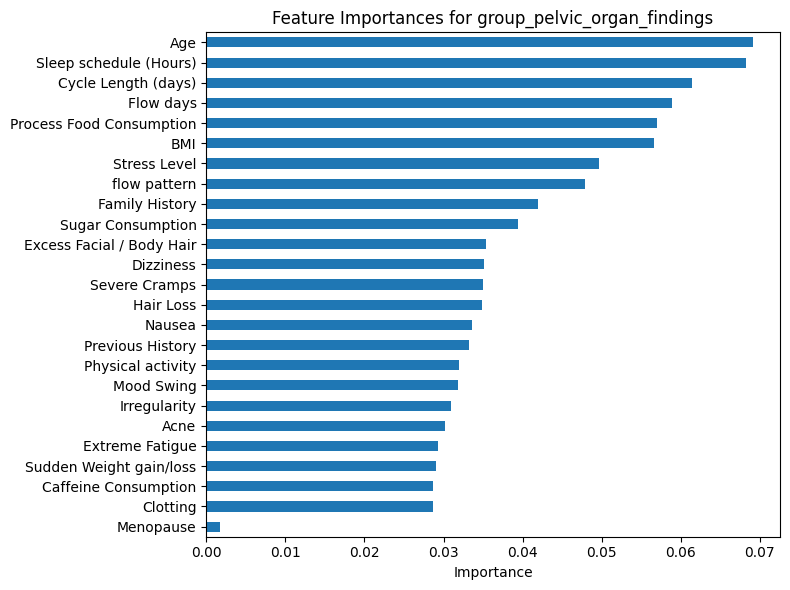

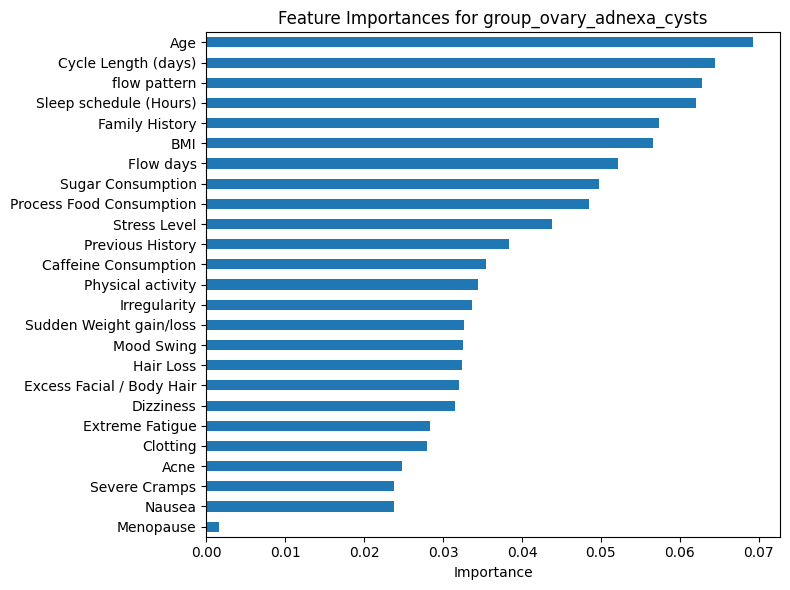

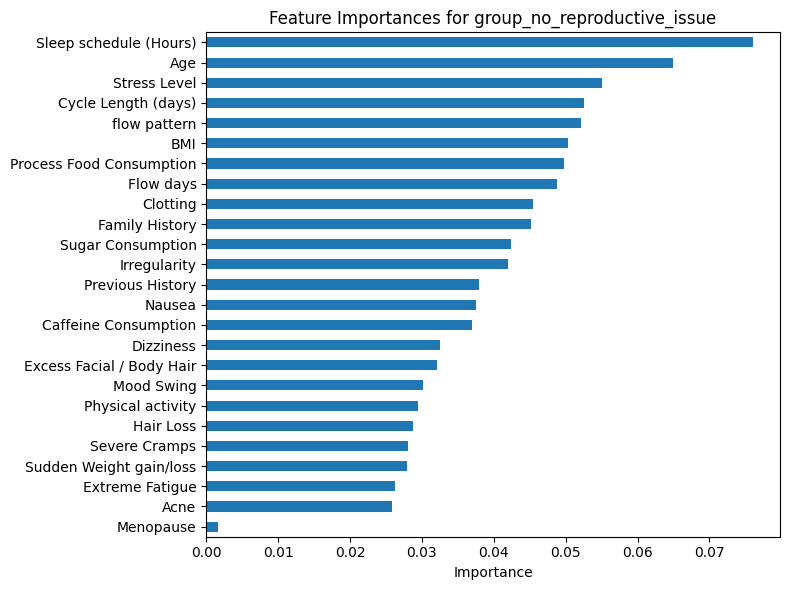

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# List of target columns
targets = ['group_pelvic_organ_findings', 'group_ovary_adnexa_cysts', 'group_no_reproductive_issue']

# Features (exclude targets)
feature_cols = df.columns.difference(targets)

# Dictionary to store feature importances
feature_importances_dict = {}

# [DATA-LEAKAGE FIX] Fit only on the training partition, since this
# importance ranking is exploratory model-selection information.
# Train a Random Forest for each target
for target in targets:
    X = df.loc[train_mask, feature_cols]
    y = df.loc[train_mask, target]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',  # handles imbalance
        n_jobs=-1
    )

    rf.fit(X, y)

    # Save feature importances
    feature_importances_dict[target] = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

    # Plot horizontal bar chart
    plt.figure(figsize=(8, 6))
    feature_importances_dict[target].plot(kind='barh')
    plt.title(f'Feature Importances for {target}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


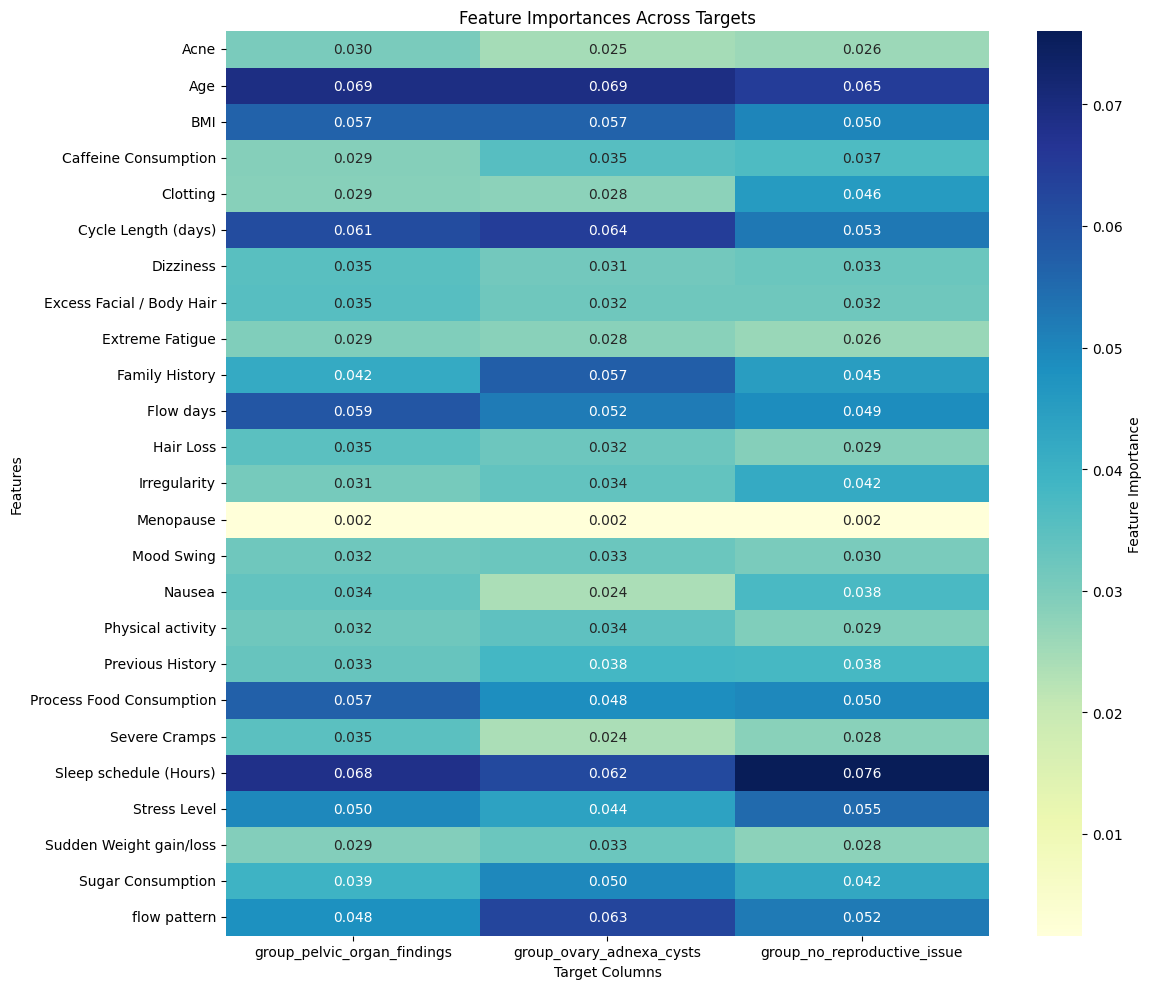

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# List of target columns
targets = ['group_pelvic_organ_findings', 'group_ovary_adnexa_cysts', 'group_no_reproductive_issue']

# Features (exclude targets)
feature_cols = df.columns.difference(targets)

# DataFrame to store feature importances for all targets
importance_df = pd.DataFrame(index=feature_cols)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# List of target columns
targets = ['group_pelvic_organ_findings', 'group_ovary_adnexa_cysts', 'group_no_reproductive_issue']

# Features (exclude targets)
feature_cols = df.columns.difference(targets)

# DataFrame to store feature importances for all targets
importance_df = pd.DataFrame(index=feature_cols)

# [DATA-LEAKAGE FIX] Fit only on the training partition.
# Train Random Forest for each target and store importances
for target in targets:
    X = df.loc[train_mask, feature_cols]
    y = df.loc[train_mask, target]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    rf.fit(X, y)

    # Add importances to the DataFrame
    importance_df[target] = rf.feature_importances_

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    importance_df,
    annot=True, fmt=".3f",
    cmap='YlGnBu',
    cbar_kws={'label': 'Feature Importance'}
)
plt.title('Feature Importances Across Targets')
plt.ylabel('Features')
plt.xlabel('Target Columns')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Identify target columns (all columns starting with 'group_')
y_cols = [col for col in df.columns if col.startswith('group_')]
X_cols = [col for col in df.columns if col not in y_cols]

X = df[X_cols]
y = df[y_cols]

# [DATA-LEAKAGE FIX] Reuse the single train/test partition created right
# after cell 14 (train_mask / train_idx / test_idx) instead of drawing a
# fresh random split here. Every statistical preprocessing step upstream
# (missing-value imputation in the BMI/Flow-days and menopause-conditional
# cells, and the hybrid label encoding cell) was already fit using ONLY
# the rows in this same partition, so reusing it guarantees X_test/y_test
# have never contributed to a fitted statistic.
X_train, X_test = X.loc[train_mask], X.loc[~train_mask]
y_train, y_test = y.loc[train_mask], y.loc[~train_mask]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (172, 25)
X_test shape: (44, 25)
y_train shape: (172, 3)
y_test shape: (44, 3)


In [ ]:
X = X.drop('Menopause', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (172, 25)
X_test_scaled shape: (44, 25)


In [ ]:
# -*- coding: utf-8 -*-
# Importing required Library
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification
from sklearn.neighbors import NearestNeighbors

def create_dataset(n_sample=1000):
    '''
    Create a unevenly distributed sample data set multilabel
    classification using make_classification function

    args
    nsample: int, Number of sample to be created

    return
    X: pandas.DataFrame, feature vector dataframe with 10 features
    y: pandas.DataFrame, target vector dataframe with 5 labels
    '''
    X, y = make_classification(n_classes=5, class_sep=2,
                           weights=[0.1,0.025, 0.205, 0.008, 0.9], n_informative=3, n_redundant=1, flip_y=0,
                           n_features=10, n_clusters_per_class=1, n_samples=1000, random_state=10)
    y = pd.get_dummies(y, prefix='class')
    return pd.DataFrame(X), y

def get_tail_label(df):
    """
    Give tail label colums of the given target dataframe

    args
    df: pandas.DataFrame, target label df whose tail label has to identified

    return
    tail_label: list, a list containing column name of all the tail label
    """
    columns = df.columns
    n = len(columns)
    irpl = np.zeros(n)
    for column in range(n):
        irpl[column] = df[columns[column]].value_counts()[1]
    irpl = max(irpl)/irpl
    mir = np.average(irpl)
    tail_label = []
    for i in range(n):
        if irpl[i] > mir:
            tail_label.append(columns[i])
    return tail_label

def get_index(df):
  """
  give the index of all tail_label rows
  args
  df: pandas.DataFrame, target label df from which index for tail label has to identified

  return
  index: list, a list containing index number of all the tail label
  """
  tail_labels = get_tail_label(df)
  index = set()
  for tail_label in tail_labels:
    sub_index = set(df[df[tail_label]==1].index)
    index = index.union(sub_index)
  return list(index)

def get_minority_instace(X, y):
    """
    Give minority dataframe containing all the tail labels

    args
    X: pandas.DataFrame, the feature vector dataframe
    y: pandas.DataFrame, the target vector dataframe

    return
    X_sub: pandas.DataFrame, the feature vector minority dataframe
    y_sub: pandas.DataFrame, the target vector minority dataframe
    """
    index = get_index(y)
    X_sub = X[X.index.isin(index)].reset_index(drop = True)
    y_sub = y[y.index.isin(index)].reset_index(drop = True)
    return X_sub, y_sub

def nearest_neighbour(X):
    """
    Give index of 5 nearest neighbor of all the instance

    args
    X: np.array, array whose nearest neighbor has to find

    return
    indices: list of list, index of 5 NN of each element in X
    """
    nbs=NearestNeighbors(n_neighbors=5,metric='euclidean',algorithm='kd_tree').fit(X)
    euclidean,indices= nbs.kneighbors(X)
    return indices

def MLSMOTE(X,y, n_sample):
    """
    Give the augmented data using MLSMOTE algorithm

    args
    X: pandas.DataFrame, input vector DataFrame
    y: pandas.DataFrame, feature vector dataframe
    n_sample: int, number of newly generated sample

    return
    new_X: pandas.DataFrame, augmented feature vector data
    target: pandas.DataFrame, augmented target vector data
    """
    indices2 = nearest_neighbour(X)
    n = len(indices2)
    new_X = np.zeros((n_sample, X.shape[1]))
    target = np.zeros((n_sample, y.shape[1]))
    for i in range(n_sample):
        reference = random.randint(0,n-1)
        neighbour = random.choice(indices2[reference,1:])
        all_point = indices2[reference]
        nn_df = y[y.index.isin(all_point)]
        ser = nn_df.sum(axis = 0, skipna = True)
        target[i] = np.array([1 if val>2 else 0 for val in ser])
        ratio = random.random()
        gap = X.loc[reference,:] - X.loc[neighbour,:]
        new_X[i] = np.array(X.loc[reference,:] + ratio * gap)
    new_X = pd.DataFrame(new_X, columns=X.columns)
    target = pd.DataFrame(target, columns=y.columns)
    new_X = pd.concat([X, new_X], axis=0)
    target = pd.concat([y, target], axis=0)
    return new_X, target

if __name__=='__main__':
    """
    main function to use the MLSMOTE
    """
    X, y = create_dataset()                     #Creating a Dataframe
    X_sub, y_sub = get_minority_instace(X, y)   #Getting minority instance of that datframe
    X_res,y_res =MLSMOTE(X_sub, y_sub, 100)     #Applying MLSMOTE to augment the dataframe

/tmp/ipykernel_10723/1568767580.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  irpl[column] = df[columns[column]].value_counts()[1]


In [ ]:
# ------------------------- MLSMOTE BLOCK -------------------------

# 1. Split features and labels
X = df[[col for col in df.columns if not col.startswith('group_')]]
y = df[[col for col in df.columns if col.startswith('group_')]]

# 2. Get minority instances (tail labels)
X_minority, y_minority = get_minority_instace(X, y)

# 3. Apply MLSMOTE
# Choose the number of synthetic samples (e.g., 200)
X_synth, y_synth = MLSMOTE(X_minority, y_minority, n_sample=200)

# 4. Combine original + synthetic
X_resampled = pd.concat([X, X_synth], ignore_index=True)
y_resampled = pd.concat([y, y_synth], ignore_index=True)




In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score as _cv_acc, f1_score as _cv_f1
import numpy as np

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_subset_acc, cv_macro_f1 = [], []

train_rows = df_raw_snapshot.loc[train_idx].index.to_numpy()

for fold_i, (inner_tr_pos, inner_val_pos) in enumerate(kf.split(train_rows), start=1):
    inner_tr_rows = train_rows[inner_tr_pos]
    inner_val_rows = train_rows[inner_val_pos]

    # Fresh, un-imputed / un-encoded copy of this fold's rows only
    # (test_idx rows are excluded from the loop entirely).
    fold_df = df_raw_snapshot.loc[np.concatenate([inner_tr_rows, inner_val_rows])].copy()
    fold_fit_mask = fold_df.index.isin(inner_tr_rows)

    # 1) Missing-value imputation -- fit on inner-training rows only
    impute_bmi_flow(fold_df, fold_fit_mask)
    fold_df['flow pattern'] = fold_df.apply(get_flow_pattern, axis=1)
    fold_df.drop(columns=['Heavy Bleeding', 'Extreme light flow'], inplace=True)
    impute_group_mode_menopause(fold_df, fold_fit_mask)

    # 2) Hybrid encoding -- fit on inner-training rows only
    fit_apply_label_encoders(fold_df, fold_fit_mask)

    fold_y_cols = [c for c in fold_df.columns if c.startswith('group_')]
    fold_X_cols = [c for c in fold_df.columns if c not in fold_y_cols]

    Xf_tr = fold_df.loc[fold_fit_mask, fold_X_cols]
    yf_tr = fold_df.loc[fold_fit_mask, fold_y_cols]
    Xf_val = fold_df.loc[~fold_fit_mask, fold_X_cols]
    yf_val = fold_df.loc[~fold_fit_mask, fold_y_cols]

    # 3) MLSMOTE -- inner-training rows only
    Xf_min, yf_min = get_minority_instace(Xf_tr.reset_index(drop=True), yf_tr.reset_index(drop=True))
    Xf_synth, yf_synth = MLSMOTE(Xf_min, yf_min, n_sample=200)
    Xf_res = pd.concat([Xf_tr.reset_index(drop=True), Xf_synth], ignore_index=True)
    yf_res = pd.concat([yf_tr.reset_index(drop=True), yf_synth], ignore_index=True)

    # 4) Fit + score a representative model on the untouched inner-validation rows
    fold_model = MultiOutputClassifier(
        RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
    )
    fold_model.fit(Xf_res, yf_res)
    yf_pred = fold_model.predict(Xf_val)

    acc = _cv_acc(yf_val.values, yf_pred)
    f1m = _cv_f1(yf_val.values, yf_pred, average='macro', zero_division=0)
    cv_subset_acc.append(acc)
    cv_macro_f1.append(f1m)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
     X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [ ]:
X_tr_c=X_train.copy()
X_te_c=X_test.copy()
y_tr_c=y_train.copy()
y_te_c=y_test.copy()

In [ ]:
# ── 7. CLASS 1 — Tree / Boosting Models ──────────────────────────────────────
# Add necessary imports for advanced evaluation
from sklearn.metrics import multilabel_confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print('='*65)
print('CLASS 1: Random Forest | XGBoost | LightGBM')
print('='*65)

# Prepare target names for reports and plots
# target_names is available from cell cKQiM1gmXV18
target_names = y_resampled.columns.tolist() # Define target_names
short_target_names = [t.replace('group_','').replace('_',' ').title() for t in target_names]


def evaluate_and_report_advanced(model_name, y_true, y_pred, y_proba, target_names):
    """
    Performs advanced evaluation (classification report, AUC, confusion matrix, ROC curves)
    and prints/plots the results for multi-label classification.
    """
    print(f"\n--- Detailed Evaluation for {model_name} ---")

    # 1. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    # 2. Macro AUC calculation (One-vs-Rest)
    # Check if y_proba is available and correct shape
    if y_proba is not None and y_proba.shape == y_true.shape:
        macro_roc_auc_ovr = roc_auc_score(y_true, y_proba, average="macro", multi_class="ovr")
        print(f"Macro AUC (One-vs-Rest): {macro_roc_auc_ovr:.4f}")
    else:
        print("Warning: Probability predictions not available or incorrect shape for AUC calculation.")
        macro_roc_auc_ovr = np.nan # Assign NaN if not available

    # 3. Confusion Matrix Plot and Per-Class Accuracy
    print("\nConfusion Matrices:")
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    n_labels = len(target_names)
    fig, axes = plt.subplots(1, n_labels, figsize=(5 * n_labels, 4))
    if n_labels == 1: # Handle case with a single subplot correctly
        axes = [axes]

    per_class_accuracy = {}
    for i, cm in enumerate(mcm):
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1]) # Handle potential 2x2 or other sizes
        # If any division by zero might occur, handle it (e.g., if there are no samples for a class)
        total_samples = tn + fp + fn + tp
        acc = (tp + tn) / total_samples if total_samples > 0 else 0.0
        per_class_accuracy[target_names[i]] = acc

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                    xticklabels=['Predicted 0', 'Predicted 1'],
                    yticklabels=['Actual 0', 'Actual 1'])
        axes[i].set_title(f'CM for {target_names[i]}\nAcc: {acc:.2f}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.tight_layout()
    plt.suptitle(f'Confusion Matrices for {model_name}', y=1.05, fontsize=16)
    plt.show()

    print("\nPer-Label Accuracy:")
    for label, acc in per_class_accuracy.items():
        print(f"  {label:25s}: {acc:.4f}")

    # 4. Individual and Macro-average ROC Curves
    print("\nROC Curves:")
    plt.figure(figsize=(10, 8))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calculate ROC for each label
    for i in range(n_labels):
        # Ensure y_proba has probabilities for both classes for roc_curve
        if y_proba is not None and y_proba.shape == y_true.shape:
            fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
        else:
            # If no probabilities, plot a dummy line or skip
            print(f"  Skipping ROC for {target_names[i]} due to missing probabilities.")

    # Compute macro-average ROC curve
    if y_proba is not None and y_proba.shape == y_true.shape:
        # First aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_labels) if i in fpr]))

        # Then interpolate all ROC curves at these points
        mean_tpr = np.zeros_like(all_fpr)
        count_valid_labels = 0
        for i in range(n_labels):
            if i in fpr: # Only include labels for which ROC was calculated
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
                count_valid_labels += 1

        # Finally average it and compute AUC
        if count_valid_labels > 0:
            mean_tpr /= count_valid_labels
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

            plt.plot(fpr["macro"], tpr["macro"],
                     label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
                     color='deeppink', linestyle=':', linewidth=4)
        else:
            print("  Macro-average ROC skipped: No valid labels for calculation.")
    else:
        print("  Macro-average ROC skipped: Probability predictions not available.")

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return macro_roc_auc_ovr

CLASS 1: Random Forest | XGBoost | LightGBM


In [ ]:
from sklearn.model_selection import train_test_split

# Correctly perform train-test split using the original X_resampled and y_resampled
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


rf = MultiOutputClassifier(RandomForestClassifier())

rf.fit(X_train, Y_train)

MultiOutputClassifier(estimator=RandomForestClassifier())


Comprehensive Evaluation Report for RandomForestClassifier

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.96      0.65      0.78        40
   group_ovary_adnexa_cysts       0.86      0.88      0.87        48
group_no_reproductive_issue       0.81      0.89      0.85        44

                  micro avg       0.86      0.81      0.84       132
                  macro avg       0.88      0.80      0.83       132
               weighted avg       0.87      0.81      0.83       132
                samples avg       0.78      0.79      0.78       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7658
   Macro F1 Score: 0.8300
   Hamming Loss: 0.1261

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.8649
     group_ovary_adnexa_cysts : 0.8829
     group_no_reproductive_issue: 0.8739

3. Confusion Matrices per Label:


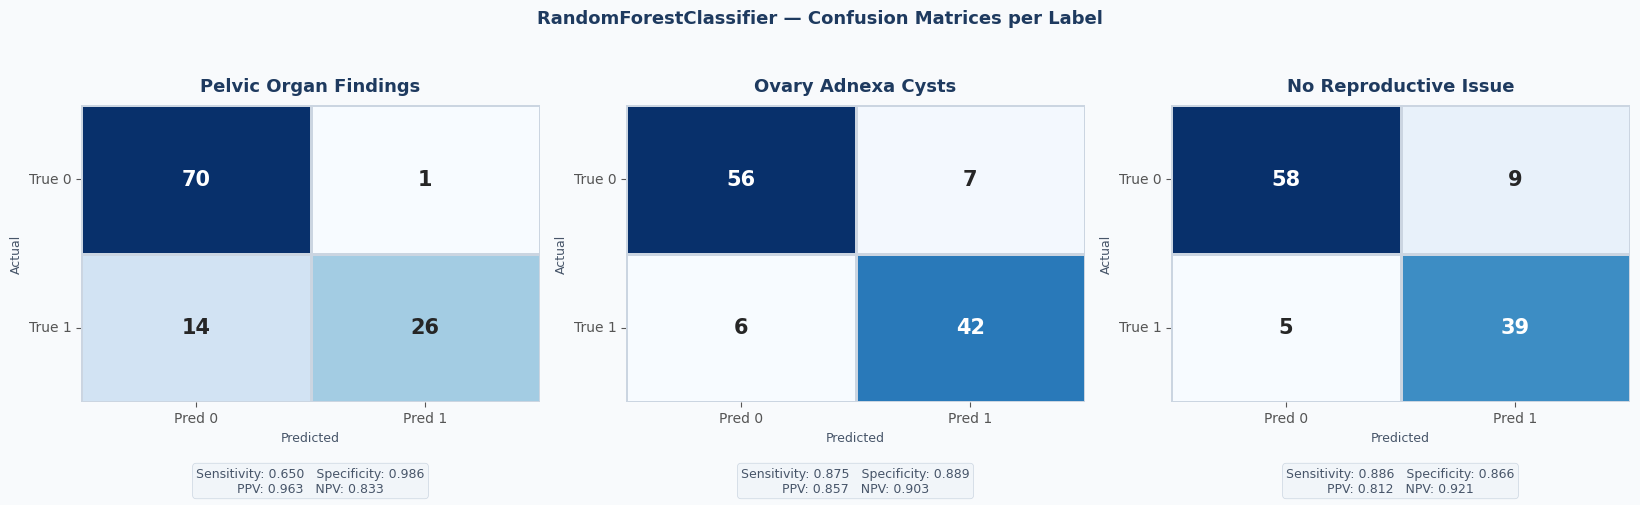

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


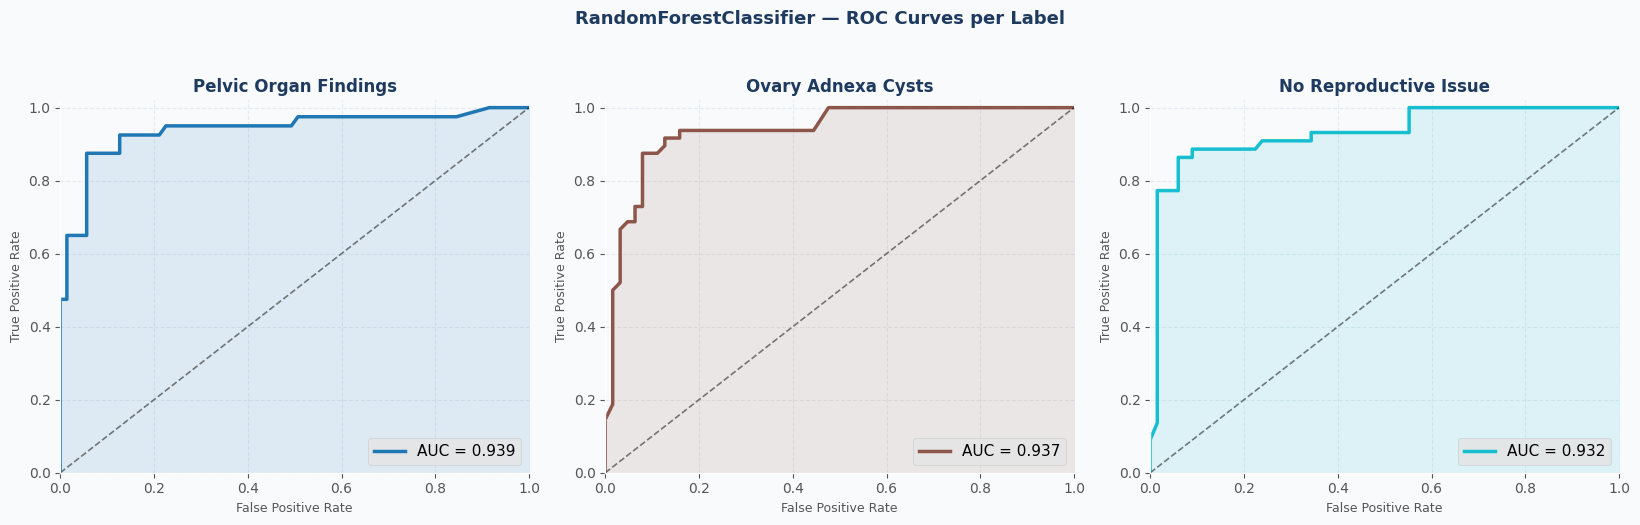


4b. Combined (Macro-Average) ROC Curve:


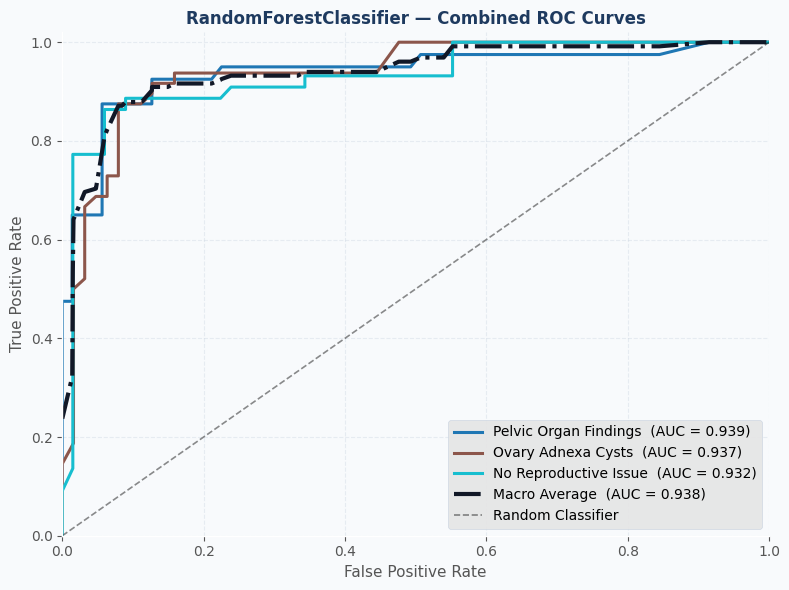

   Macro-Average AUC: 0.9380


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    hamming_loss, multilabel_confusion_matrix,
    roc_curve, auc
)

# Ensure y_test is a numpy array for consistent indexing in evaluation functions
y_true_np = Y_test.values

# Generate predictions and probabilities from the trained model
y_pred = rf.predict(X_test)
# MultiOutputClassifier's predict_proba returns a list of arrays (one for each label).
# Each array is (n_samples, 2), containing prob for class 0 and class 1.
# We need to stack the probabilities for class 1 for each label.
y_proba_list = rf.predict_proba(X_test)
y_proba = np.column_stack([p[:, 1] for p in y_proba_list])

# Get target names from the original DataFrame
target_names = Y_test.columns.tolist()
short_names  = [t.replace('group_','').replace('_',' ').title() for t in target_names]
n_labels     = len(target_names)

def comprehensive_evaluation_report(y_true, y_pred, y_proba, target_names, short_names, n_labels, model_name="Model"):
    """
    Provides a comprehensive evaluation report for multi-label classification.

    Args:
        y_true (np.ndarray): True labels.
        y_pred (np.ndarray): Predicted labels (binary).
        y_proba (np.ndarray): Predicted probabilities for the positive class.
        target_names (list): Full column names of the labels.
        short_names (list): Shorter, human-readable names for the labels.
        n_labels (int): Number of labels.
        model_name (str): Name of the model being evaluated.
    """
    print(f"\n{'='*70}")
    print(f"Comprehensive Evaluation Report for {model_name}")
    print(f"{'='*70}\n")

    # 1. Classification Report
    print("1. Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    # 2. Summary Metrics
    subset_accuracy = accuracy_score(y_true, y_pred)
    macro_f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    hamming_loss_score = hamming_loss(y_true, y_pred)

    print(f"\n2. Summary Metrics:")
    print(f"   Subset Accuracy (all labels correctly predicted per sample): {subset_accuracy:.4f}")
    print(f"   Macro F1 Score: {macro_f1:.4f}")
    print(f"   Hamming Loss: {hamming_loss_score:.4f}")

    # Per-Class Accuracy
    print("\n   Per-Class Accuracy:")
    for i, label_name in enumerate(target_names):
        class_accuracy = accuracy_score(y_true[:, i], y_pred[:, i])
        print(f"     {label_name:25s}: {class_accuracy:.4f}")

    # 3. Confusion Matrix Plots per Label
    print("\n3. Confusion Matrices per Label:")
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    fig_cm, axes_cm = plt.subplots(1, n_labels, figsize=(5.5 * n_labels, 5), facecolor='#F8FAFC')
    if n_labels == 1:
        axes_cm = [axes_cm] # Ensure axes is iterable for single label case

    for i, (cm, sname) in enumerate(zip(mcm, short_names)):
        ax = axes_cm[i]
        ax.set_facecolor('#F8FAFC')
        tn, fp, fn, tp = cm.ravel()
        sns.heatmap(
            [[tn, fp], [fn, tp]],
            annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.8, linecolor='#CBD5E1', cbar=False,
            annot_kws={'size': 15, 'weight': 'bold'}
        )
        ax.set_title(sname, fontsize=13, fontweight='bold', pad=10, color='#1E3A5F')
        ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=10)
        ax.set_yticklabels(['True 0', 'True 1'], fontsize=10, rotation=0)
        ax.set_xlabel('Predicted', fontsize=9, color='#475569')
        ax.set_ylabel('Actual',    fontsize=9, color='#475569')

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0

        stats = (f'Sensitivity: {sensitivity:.3f}   Specificity: {specificity:.3f}\n'
                 f'PPV: {ppv:.3f}   NPV: {npv:.3f}')
        ax.text(0.5, -0.22, stats,
                ha='center', va='top', transform=ax.transAxes,
                fontsize=9, color='#475569',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F1F5F9', edgecolor='#CBD5E1'))
    fig_cm.suptitle(f'{model_name} — Confusion Matrices per Label',
                  fontsize=13, fontweight='bold', y=1.04, color='#1E3A5F')
    plt.tight_layout()
    plt.show()


    # 4. ROC Curves
    label_colors = plt.cm.get_cmap('tab10', n_labels)

    # 4a. Per-label ROC
    print("\n4a. Individual ROC Curves per Label:")
    fig_roc_ind, axes_roc_ind = plt.subplots(1, n_labels, figsize=(5.5 * n_labels, 5), facecolor='#F8FAFC')
    if n_labels == 1:
        axes_roc_ind = [axes_roc_ind]

    auc_scores = []
    for i, sname in enumerate(short_names):
        ax  = axes_roc_ind[i]
        ax.set_facecolor('#F8FAFC')
        col = label_colors(i)

        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)

        ax.fill_between(fpr, tpr, alpha=0.12, color=col)
        ax.plot(fpr, tpr, color=col, lw=2.5, label=f'AUC = {roc_auc:.3f}')
        ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5)

        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.set_xlabel('False Positive Rate', fontsize=9)
        ax.set_ylabel('True Positive Rate',  fontsize=9)
        ax.set_title(sname, fontsize=12, fontweight='bold', color='#1E3A5F')
        ax.legend(loc='lower right', fontsize=11, framealpha=0.85)
        ax.grid(True, linestyle='--', alpha=0.4, color='#CBD5E1')
        for sp in ['top','right']:
            ax.spines[sp].set_visible(False)
    fig_roc_ind.suptitle(f'{model_name} — ROC Curves per Label',
                       fontsize=13, fontweight='bold', y=1.04, color='#1E3A5F')
    plt.tight_layout()
    plt.show()

    # 4b. Combined ROC
    print("\n4b. Combined (Macro-Average) ROC Curve:")
    fig_roc_comb, ax_roc_comb = plt.subplots(figsize=(8, 6), facecolor='#F8FAFC')
    ax_roc_comb.set_facecolor('#F8FAFC')

    all_fpr  = np.unique(np.concatenate(
        [roc_curve(y_true[:, i], y_proba[:, i])[0] for i in range(n_labels)]
    ))
    mean_tpr = np.zeros_like(all_fpr)

    for i, (sname, col) in enumerate(zip(short_names, [label_colors(j) for j in range(n_labels)])):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        ax_roc_comb.plot(fpr, tpr, color=col, lw=2.2,
                         label=f'{sname}  (AUC = {auc_scores[i]:.3f})')
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr  /= n_labels
    macro_auc  = auc(all_fpr, mean_tpr)

    ax_roc_comb.plot(all_fpr, mean_tpr,
             color='#111827', lw=3.0, linestyle='-.',
             label=f'Macro Average  (AUC = {macro_auc:.3f})')
    ax_roc_comb.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.45, label='Random Classifier')

    ax_roc_comb.set_xlim([0,1]); ax_roc_comb.set_ylim([0,1.02])
    ax_roc_comb.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc_comb.set_ylabel('True Positive Rate',  fontsize=11)
    ax_roc_comb.set_title(
        f'{model_name} — Combined ROC Curves',
        fontsize=12, fontweight='bold', color='#1E3A5F'
    )
    ax_roc_comb.legend(loc='lower right', fontsize=10, framealpha=0.9, edgecolor='#CBD5E1')
    ax_roc_comb.grid(True, linestyle='--', alpha=0.4, color='#CBD5E1')
    for sp in ['top','right']:
            ax_roc_comb.spines[sp].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'   Macro-Average AUC: {macro_auc:.4f}')

# Call the comprehensive evaluation function for the RandomForest model
comprehensive_evaluation_report(y_true_np, y_pred, y_proba, target_names, short_names, n_labels, model_name="RandomForestClassifier")


Comprehensive Evaluation Report for XGBoostClassifier

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.96      0.68      0.79        40
   group_ovary_adnexa_cysts       0.84      0.90      0.87        48
group_no_reproductive_issue       0.75      0.86      0.80        44

                  micro avg       0.83      0.82      0.82       132
                  macro avg       0.85      0.81      0.82       132
               weighted avg       0.85      0.82      0.82       132
                samples avg       0.77      0.80      0.78       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7387
   Macro F1 Score: 0.8209
   Hamming Loss: 0.1381

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.8739
     group_ovary_adnexa_cysts : 0.8829
     group_no_reproductive_issue: 0.8288

3. Confusion Matrices per Label:


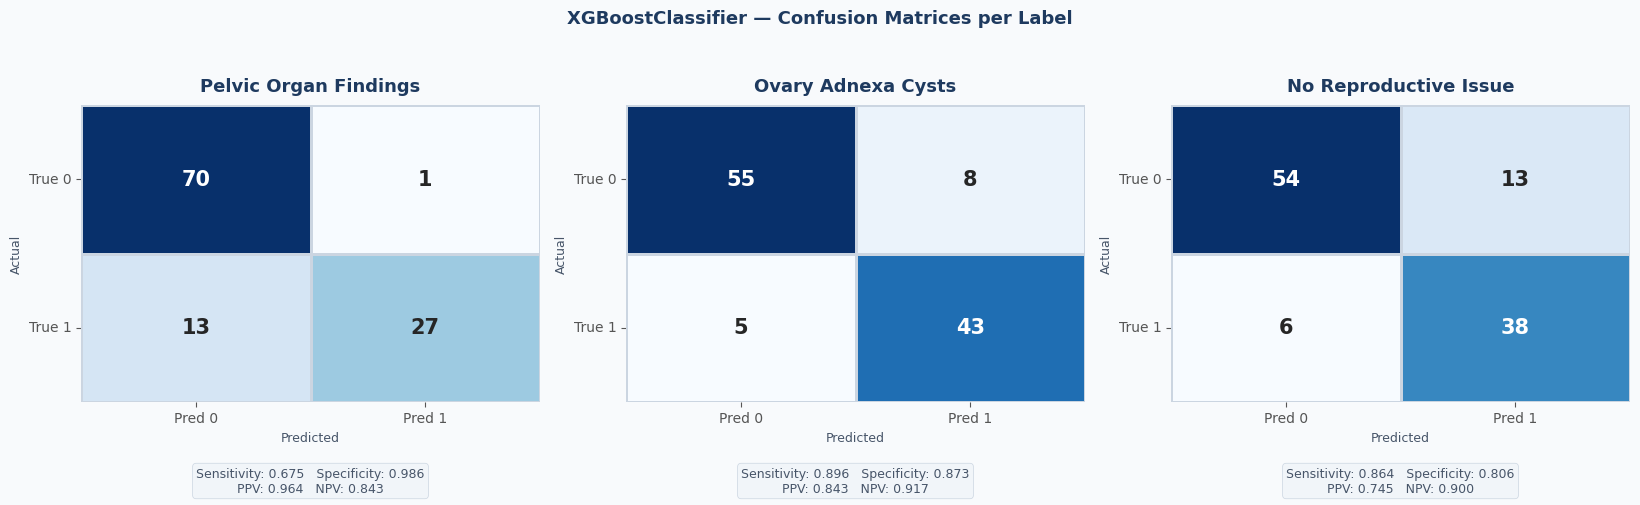

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


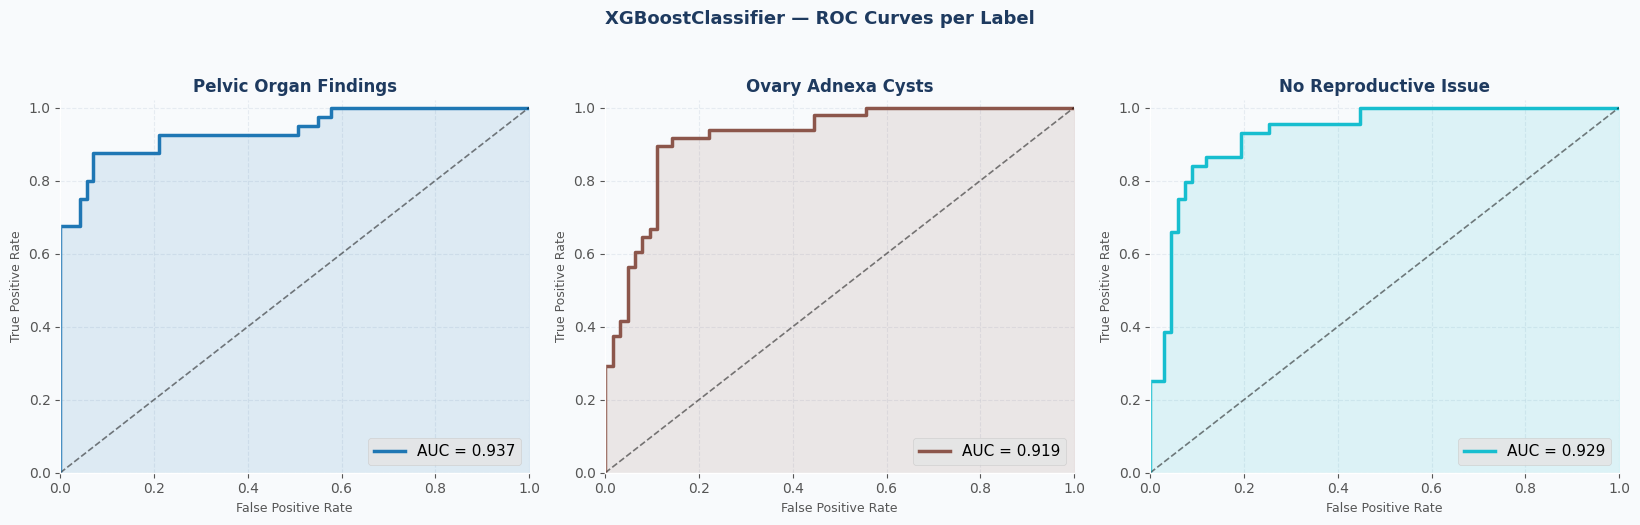


4b. Combined (Macro-Average) ROC Curve:


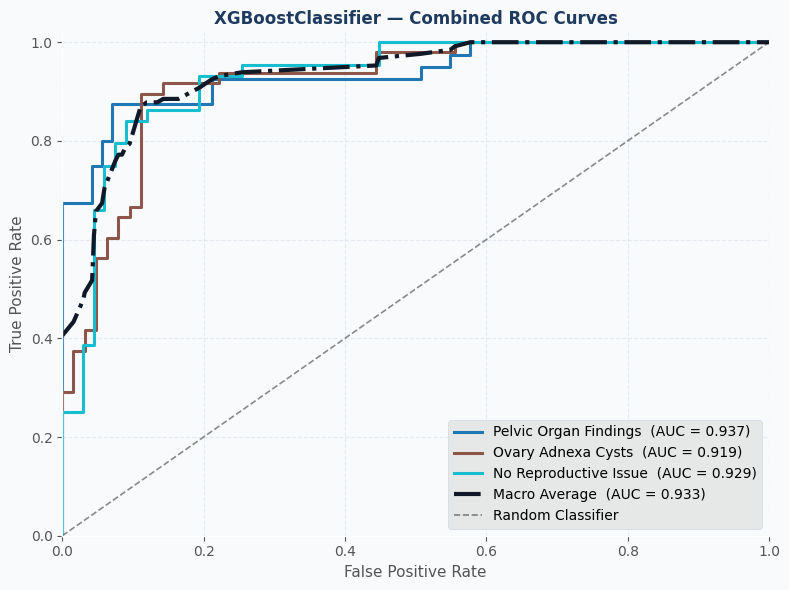

   Macro-Average AUC: 0.9329


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier # Corrected import for XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

# Correctly perform train-test split using the original X_resampled and y_resampled
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

xgb = MultiOutputClassifier(XGBClassifier())

xgb.fit(X_train, Y_train)

Y_pred = xgb.predict(X_test)

# Calculate probabilities for XGBoost
y_proba_list_xgb = xgb.predict_proba(X_test)
y_proba_xgb = np.column_stack([p[:, 1] for p in y_proba_list_xgb])

# Ensure y_test is a numpy array for consistent indexing in evaluation functions
y_true_np = Y_test.values

# Get target names from the original DataFrame
target_names = Y_test.columns.tolist()
short_names  = [t.replace('group_','').replace('_',' ').title() for t in target_names]
n_labels     = len(target_names)

# Call the comprehensive evaluation function for the XGBoost model
comprehensive_evaluation_report(y_true_np, Y_pred, y_proba_xgb, target_names, short_names, n_labels, model_name="XGBoostClassifier")


=== LightGBM MultiTask ===

Comprehensive Evaluation Report for LightGBMClassifier

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.82      0.70      0.76        40
   group_ovary_adnexa_cysts       0.81      0.88      0.84        48
group_no_reproductive_issue       0.74      0.91      0.82        44

                  micro avg       0.79      0.83      0.81       132
                  macro avg       0.79      0.83      0.80       132
               weighted avg       0.79      0.83      0.81       132
                samples avg       0.77      0.82      0.79       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7207
   Macro F1 Score: 0.8044
   Hamming Loss: 0.1562

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.8378
     group_ovary_adnexa_cysts : 0.8559
     group_no_reproductive_issue: 0.8378

3. Confusion Matrices per Label:


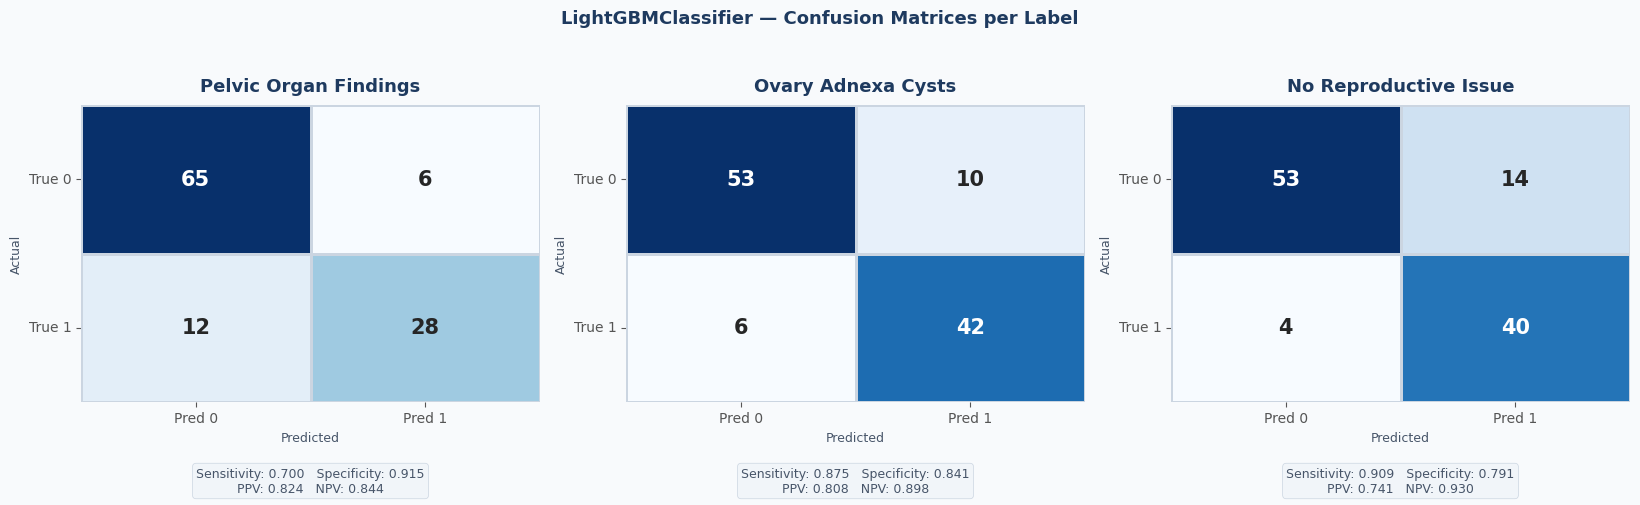

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


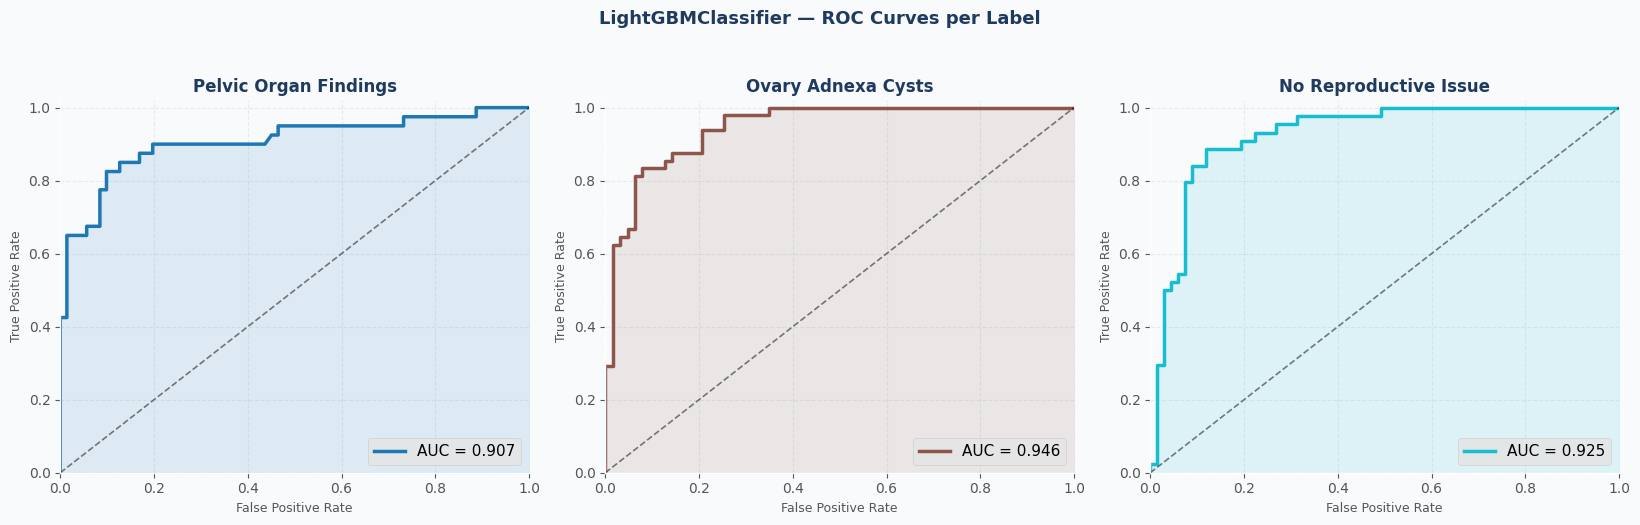


4b. Combined (Macro-Average) ROC Curve:


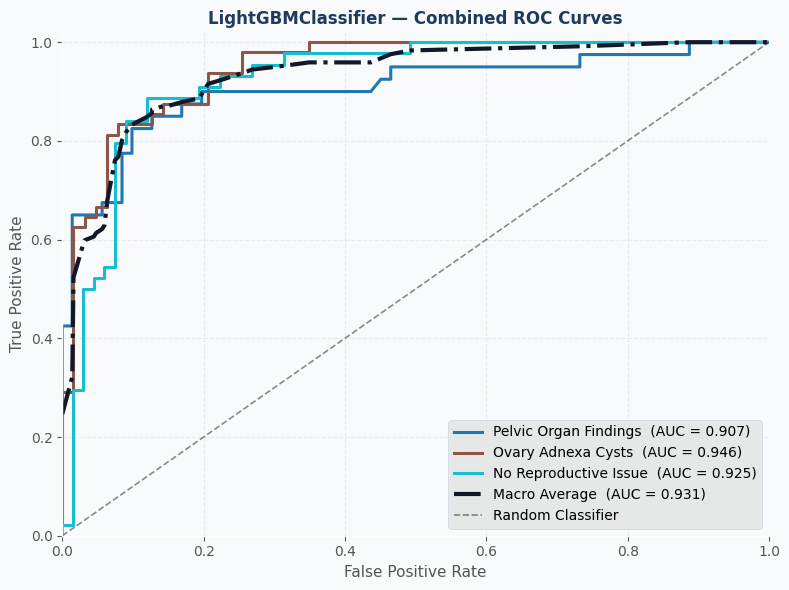

   Macro-Average AUC: 0.9308


In [ ]:
from lightgbm import LGBMClassifier
import numpy as np

print("\n=== LightGBM MultiTask ===")

# Instantiate MultiOutputClassifier with LGBMClassifier
lgbm_model = MultiOutputClassifier(LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')) # verbose=-1 to suppress training output

# Train the model
lgbm_model.fit(X_train, Y_train)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_test)

# Get probabilities
# MultiOutputClassifier's predict_proba returns a list of arrays (one for each label).
# Each array is (n_samples, 2), containing prob for class 0 and class 1.
# We need to stack the probabilities for class 1 for each label.
y_proba_list_lgbm = lgbm_model.predict_proba(X_test)
y_proba_lgbm = np.column_stack([p[:, 1] for p in y_proba_list_lgbm])

# Ensure y_test is a numpy array for consistent indexing in evaluation functions
y_true_np = Y_test.values

# Get target names from the original DataFrame (already defined from previous cells)
# target_names = Y_test.columns.tolist()
# short_names  = [t.replace('group_','').replace('_',' ').title() for t in target_names]
# n_labels     = len(target_names)

# Call the comprehensive evaluation function for the LightGBM model
comprehensive_evaluation_report(y_true_np, y_pred_lgbm, y_proba_lgbm, target_names, short_names, n_labels, model_name="LightGBMClassifier")


=== SVM MultiTask ===

Comprehensive Evaluation Report for SVMClassifier

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.69      0.78      0.73        40
   group_ovary_adnexa_cysts       0.70      0.79      0.75        48
group_no_reproductive_issue       0.70      0.73      0.71        44

                  micro avg       0.70      0.77      0.73       132
                  macro avg       0.70      0.76      0.73       132
               weighted avg       0.70      0.77      0.73       132
                samples avg       0.69      0.75      0.71       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.5946
   Macro F1 Score: 0.7285
   Hamming Loss: 0.2252

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.7928
     group_ovary_adnexa_cysts : 0.7658
     group_no_reproductive_issue: 0.7658

3. Confusion Matrices per Label:


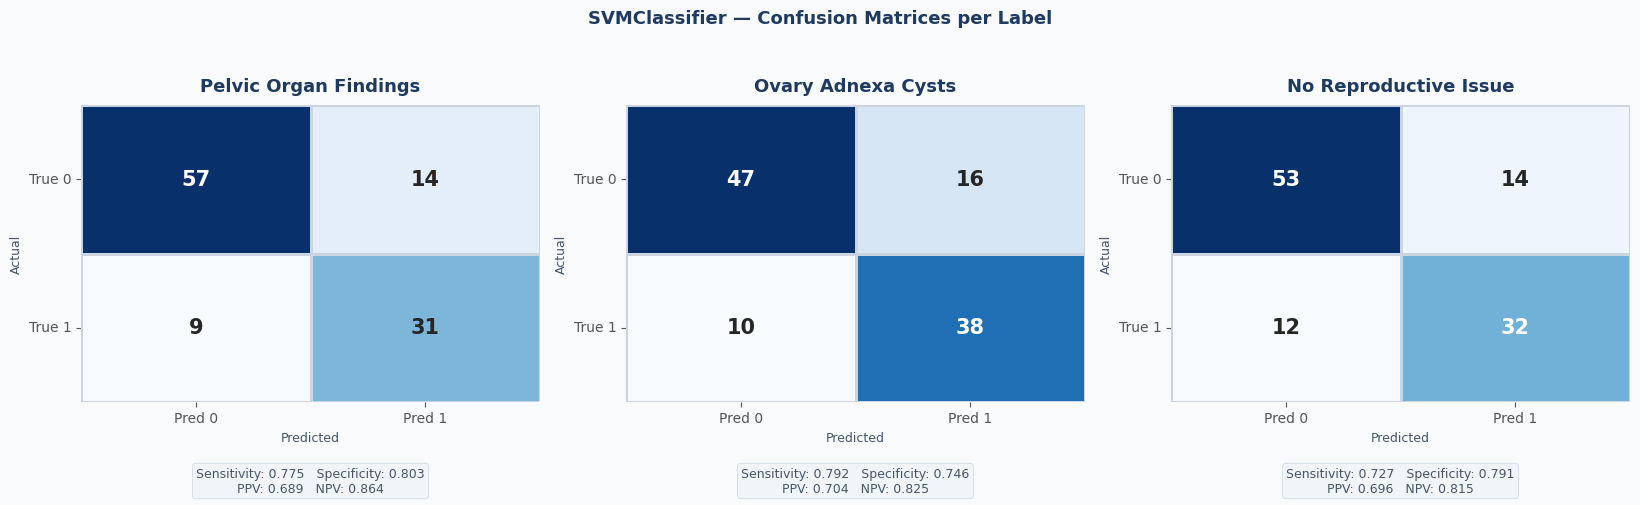

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


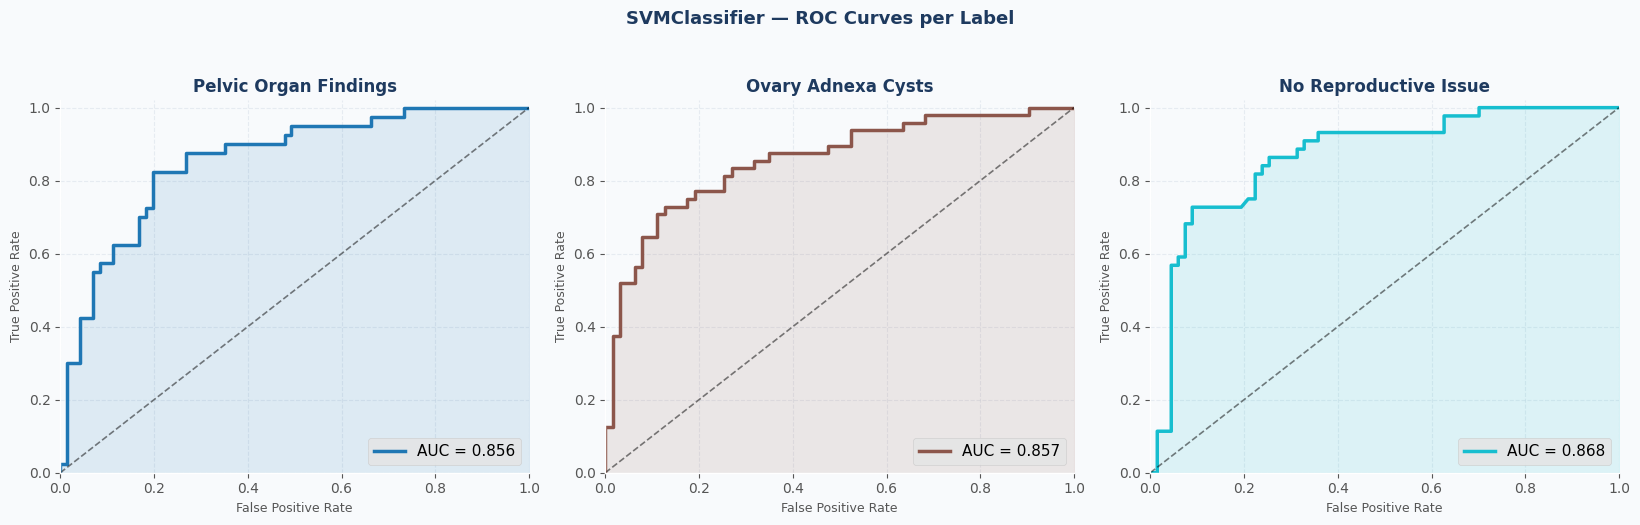


4b. Combined (Macro-Average) ROC Curve:


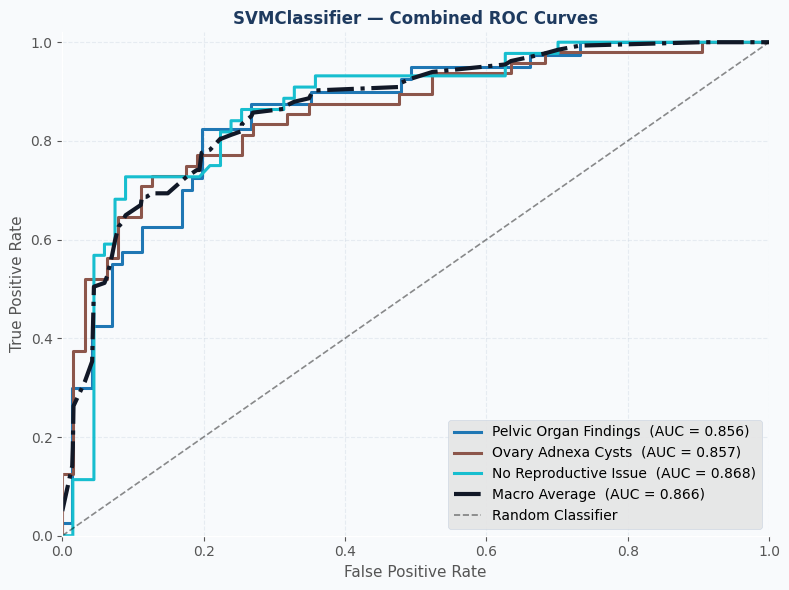

   Macro-Average AUC: 0.8659


In [ ]:
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
import numpy as np
from sklearn.preprocessing import StandardScaler # Import StandardScaler

print("\n=== SVM MultiTask ===")

# Instantiate MultiOutputClassifier with SVC
# Use class_weight='balanced' to handle class imbalance
# probability=True is needed for predict_proba which is used in comprehensive_evaluation_report
svm_model = MultiOutputClassifier(SVC(random_state=42, class_weight='balanced', probability=True))

# --- FIX START ---
# The X_train, X_test, Y_train, Y_test variables currently hold the resampled data split.
# X_train_scaled and X_test_scaled were created from the *original* (non-resampled) split,
# causing a mismatch in sample counts with the current Y_train.
# We need to re-scale the current X_train and X_test (from resampled data).
# Also, 'Menopause' was intended to be dropped for models, so we drop it here from the resampled data.

X_train_for_svm = X_train.drop('Menopause', axis=1)
X_test_for_svm = X_test.drop('Menopause', axis=1)

# Initialize and fit StandardScaler on the correctly prepared training data
scaler_svm = StandardScaler()
X_train_scaled_svm = scaler_svm.fit_transform(X_train_for_svm)
X_test_scaled_svm = scaler_svm.transform(X_test_for_svm)

# Train the model on the correctly scaled data
svm_model.fit(X_train_scaled_svm, Y_train)

# Make predictions using the correctly scaled test data
y_pred_svm = svm_model.predict(X_test_scaled_svm)

# Get probabilities using the correctly scaled test data
y_proba_list_svm = svm_model.predict_proba(X_test_scaled_svm)
y_proba_svm = np.column_stack([p[:, 1] for p in y_proba_list_svm])
# --- FIX END ---

# Ensure y_test is a numpy array for consistent indexing in evaluation functions
y_true_np = Y_test.values

# Get target names from the original DataFrame (already defined from previous cells)
# target_names = Y_test.columns.tolist()
# short_names  = [t.replace('group_','').replace('_',' ').title() for t in target_names]
# n_labels     = len(target_names)

# Call the comprehensive evaluation function for the SVM model
comprehensive_evaluation_report(y_true_np, y_pred_svm, y_proba_svm, target_names, short_names, n_labels, model_name="SVMClassifier")

In [ ]:
import numpy as np

class CustomMLKNN:
    def __init__(self, k=7, smooth=1.0):
        self.k = k
        self.smooth = smooth

    def fit(self, X, Y):
        self.X = X
        # FIX: Convert Y to a NumPy array so integer indexing works correctly
        self.Y = Y.values.astype(int)
        self.num_samples, self.num_labels = self.Y.shape

        # Precompute distances
        self.dist_matrix = self._compute_distances(X)

        # Prior probabilities P(label=1)
        self.prior_prob = (np.sum(self.Y, axis=0) + self.smooth) / (self.num_samples + 2 * self.smooth)
        self.prior_neg = 1 - self.prior_prob

        # Count neighbors per class
        self.knn_indices = np.argsort(self.dist_matrix, axis=1)[:, 1:self.k+1]

        # Conditional probabilities
        self.cond_pos = np.zeros((self.num_labels, self.k+1))
        self.cond_neg = np.zeros((self.num_labels, self.k+1))

        for label in range(self.num_labels):
            for i in range(self.num_samples):
                # This line now works correctly as self.Y is a NumPy array
                neighbor_labels = self.Y[self.knn_indices[i], label]
                c = np.sum(neighbor_labels)

                if self.Y[i, label] == 1:
                    self.cond_pos[label, c] += 1
                else:
                    self.cond_neg[label, c] += 1

            # Normalize
            self.cond_pos[label] = (self.cond_pos[label] + self.smooth) / \
                                   (np.sum(self.cond_pos[label]) + (self.k+1) * self.smooth)

            self.cond_neg[label] = (self.cond_neg[label] + self.smooth) / \
                                   (np.sum(self.cond_neg[label]) + (self.k+1) * self.smooth)

    def predict(self, X_test):
        dist_test = self._compute_distances(X_test, self.X)
        knn_idx = np.argsort(dist_test, axis=1)[:, :self.k]

        preds = np.zeros((X_test.shape[0], self.num_labels), dtype=int)

        for i in range(X_test.shape[0]):
            for label in range(self.num_labels):
                # This line now works correctly as self.Y is a NumPy array
                neighbor_labels = self.Y[knn_idx[i], label]
                c = np.sum(neighbor_labels)

                p_pos = self.prior_prob[label] * self.cond_pos[label, c]
                p_neg = self.prior_neg[label] * self.cond_neg[label, c]

                preds[i, label] = 1 if p_pos >= p_neg else 0

        return preds

    def predict_proba(self, X_test):
        dist_test = self._compute_distances(X_test, self.X)
        knn_idx = np.argsort(dist_test, axis=1)[:, :self.k]

        probas = np.zeros((X_test.shape[0], self.num_labels), dtype=float)

        for i in range(X_test.shape[0]):
            for label in range(self.num_labels):
                neighbor_labels = self.Y[knn_idx[i], label]
                c = np.sum(neighbor_labels)

                p_pos = self.prior_prob[label] * self.cond_pos[label, c]
                p_neg = self.prior_neg[label] * self.cond_neg[label, c]

                total_prob = p_pos + p_neg
                if total_prob > 0:
                    probas[i, label] = p_pos / total_prob
                else:
                    probas[i, label] = 0.5 # Default to 0.5 if no information

        return probas

    def _compute_distances(self, A, B=None):
        if B is None:
            B = A
        A_sq = np.sum(A**2, axis=1).reshape(-1, 1)
        B_sq = np.sum(B**2, axis=1)
        cross = np.dot(A, B.T)
        # FIX: Ensure non-negative argument to sqrt to avoid RuntimeWarning
        dists = np.sqrt(np.maximum(A_sq - 2*cross + B_sq, 0))
        return dists


Comprehensive Evaluation Report for Custom MLKNN

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.90      0.23      0.36        40
   group_ovary_adnexa_cysts       0.65      0.35      0.46        48
group_no_reproductive_issue       0.59      0.80      0.68        44

                  micro avg       0.64      0.46      0.54       132
                  macro avg       0.72      0.46      0.50       132
               weighted avg       0.71      0.46      0.50       132
                samples avg       0.51      0.50      0.50       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.4595
   Macro F1 Score: 0.4997
   Hamming Loss: 0.3153

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.7117
     group_ovary_adnexa_cysts : 0.6396
     group_no_reproductive_issue: 0.7027

3. Confusion Matrices per Label:


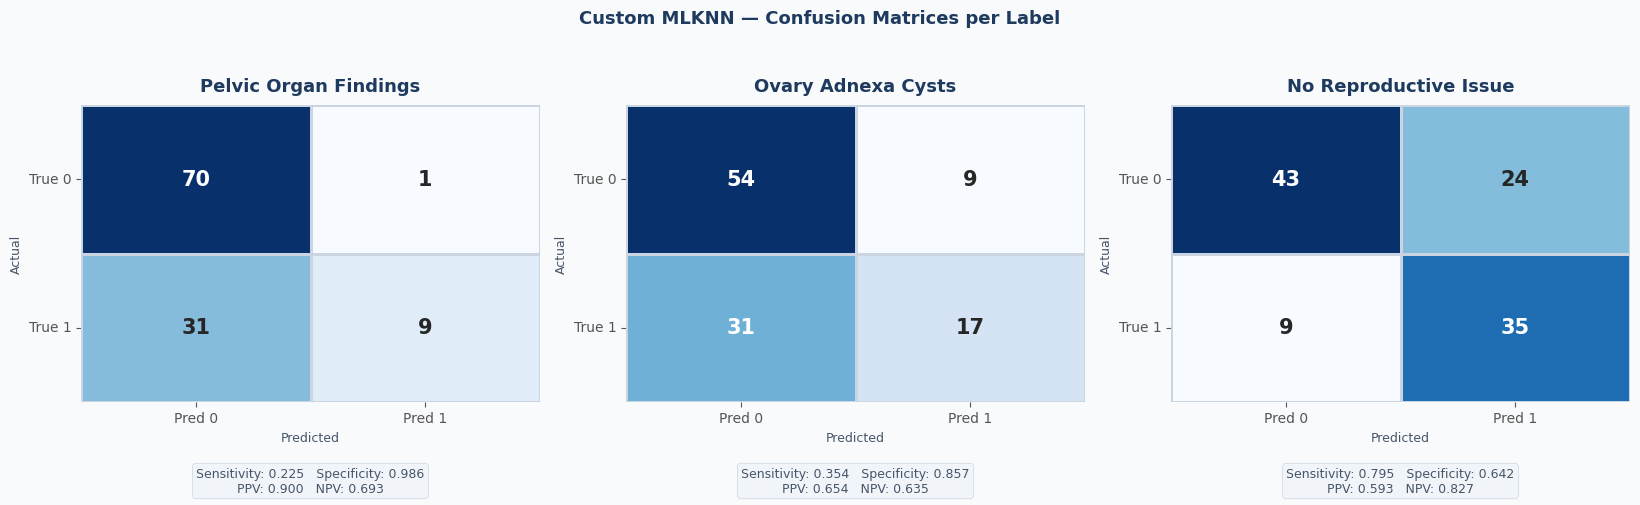

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


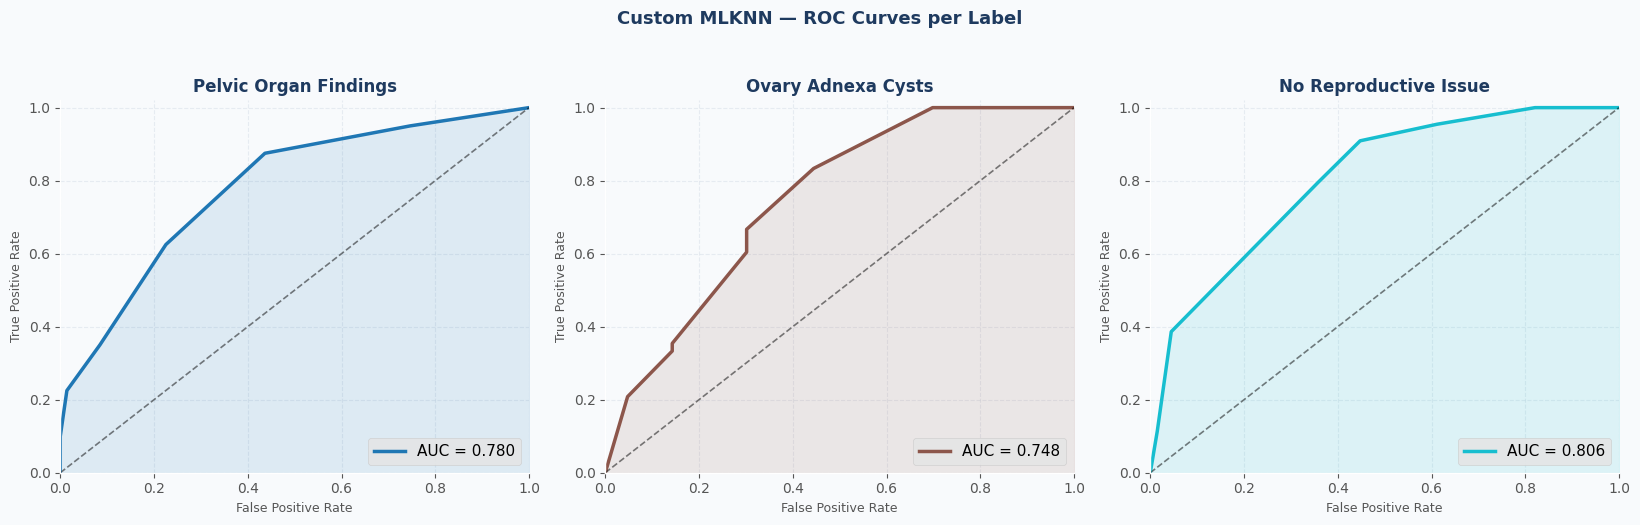


4b. Combined (Macro-Average) ROC Curve:


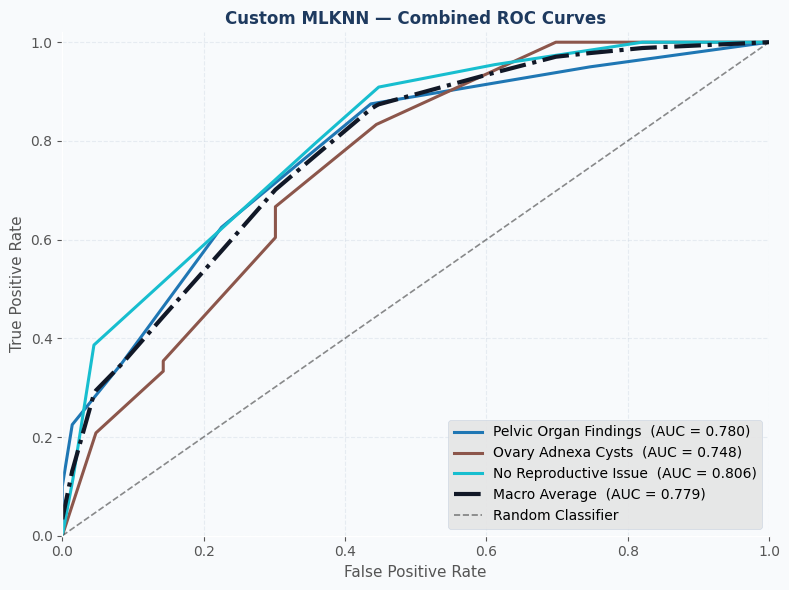

   Macro-Average AUC: 0.7790


In [ ]:
# Drop 'Menopause' and scale X_train and X_test from the resampled split
X_train_for_mlknn = X_train.drop('Menopause', axis=1)
X_test_for_mlknn = X_test.drop('Menopause', axis=1)

# Initialize and fit StandardScaler on the correctly prepared training data
scaler_mlknn = StandardScaler()
X_train_scaled_mlknn = scaler_mlknn.fit_transform(X_train_for_mlknn)
X_test_scaled_mlknn = scaler_mlknn.transform(X_test_for_mlknn)

mlknn = CustomMLKNN(k=7)
# Use the newly scaled X_train and the corresponding Y_train
mlknn.fit(X_train_scaled_mlknn, Y_train)

# Use the newly scaled X_test for predictions
y_pred_mlknn = mlknn.predict(X_test_scaled_mlknn)

# FIX: Use comprehensive_evaluation_report instead of evaluate_model
# Ensure y_true_np, target_names, short_names, n_labels are available from previous cells
comprehensive_evaluation_report(Y_test.values, y_pred_mlknn, mlknn.predict_proba(X_test_scaled_mlknn), target_names, short_names, n_labels, model_name="Custom MLKNN")

In [ ]:
!pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.2 MB/s eta 0:00:00


In [ ]:

!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 6.5 MB/s eta 0:00:00


In [ ]:

! pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00



=== Gaussian Naive Bayes (MultiOutput) ===

Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.49      0.65      0.56        40
   group_ovary_adnexa_cysts       0.49      0.69      0.57        48
group_no_reproductive_issue       0.64      0.36      0.46        44

                  micro avg       0.51      0.57      0.54       132
                  macro avg       0.54      0.57      0.53       132
               weighted avg       0.54      0.57      0.53       132
                samples avg       0.48      0.56      0.50       132



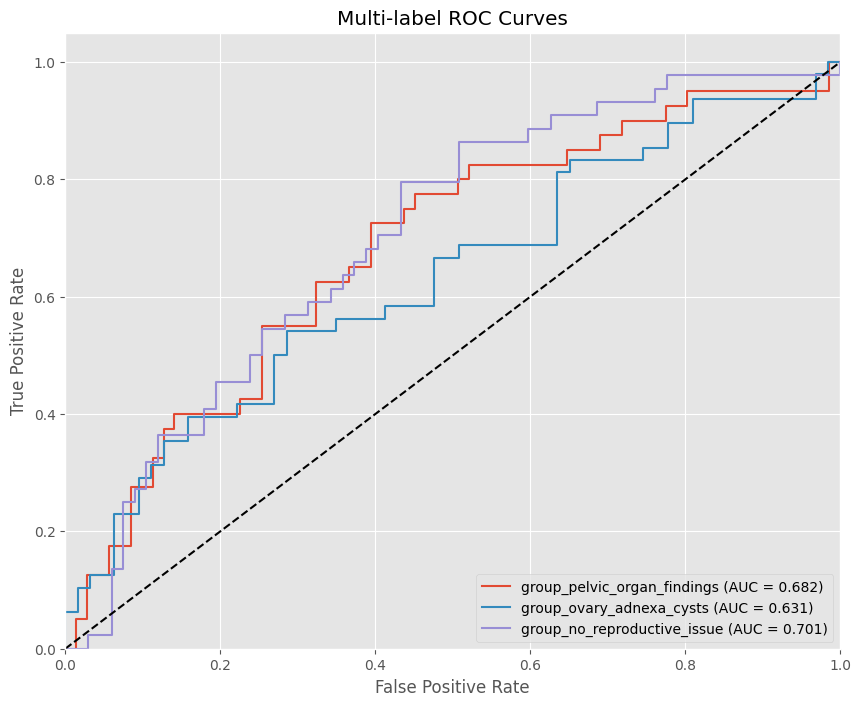

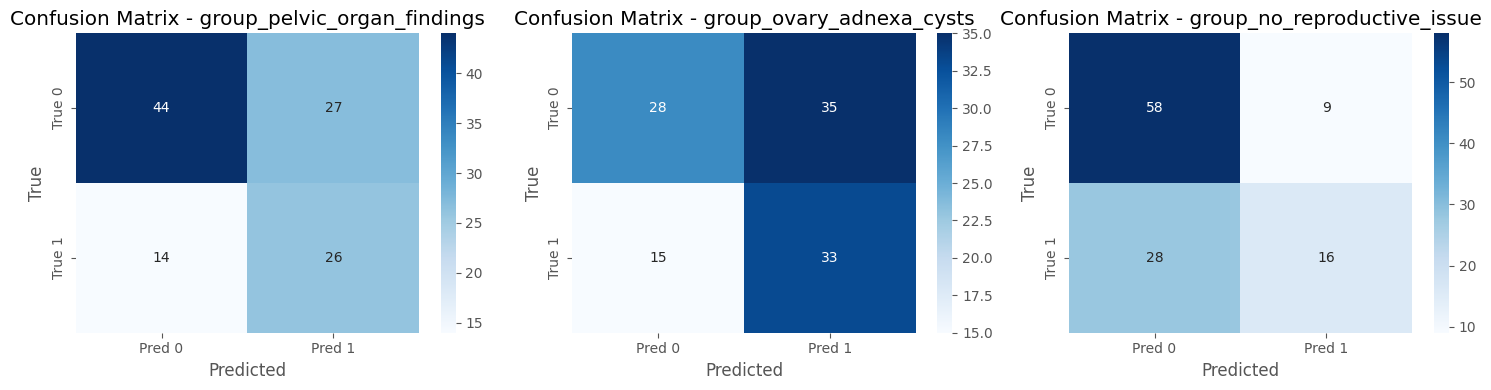


Comprehensive Evaluation Report for GaussianNB

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.49      0.65      0.56        40
   group_ovary_adnexa_cysts       0.49      0.69      0.57        48
group_no_reproductive_issue       0.64      0.36      0.46        44

                  micro avg       0.51      0.57      0.54       132
                  macro avg       0.54      0.57      0.53       132
               weighted avg       0.54      0.57      0.53       132
                samples avg       0.48      0.56      0.50       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.3153
   Macro F1 Score: 0.5306
   Hamming Loss: 0.3844

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.6306
     group_ovary_adnexa_cysts : 0.5495
     group_no_reproductive_issue: 0.6667

3. Confusion Matrices per Label:


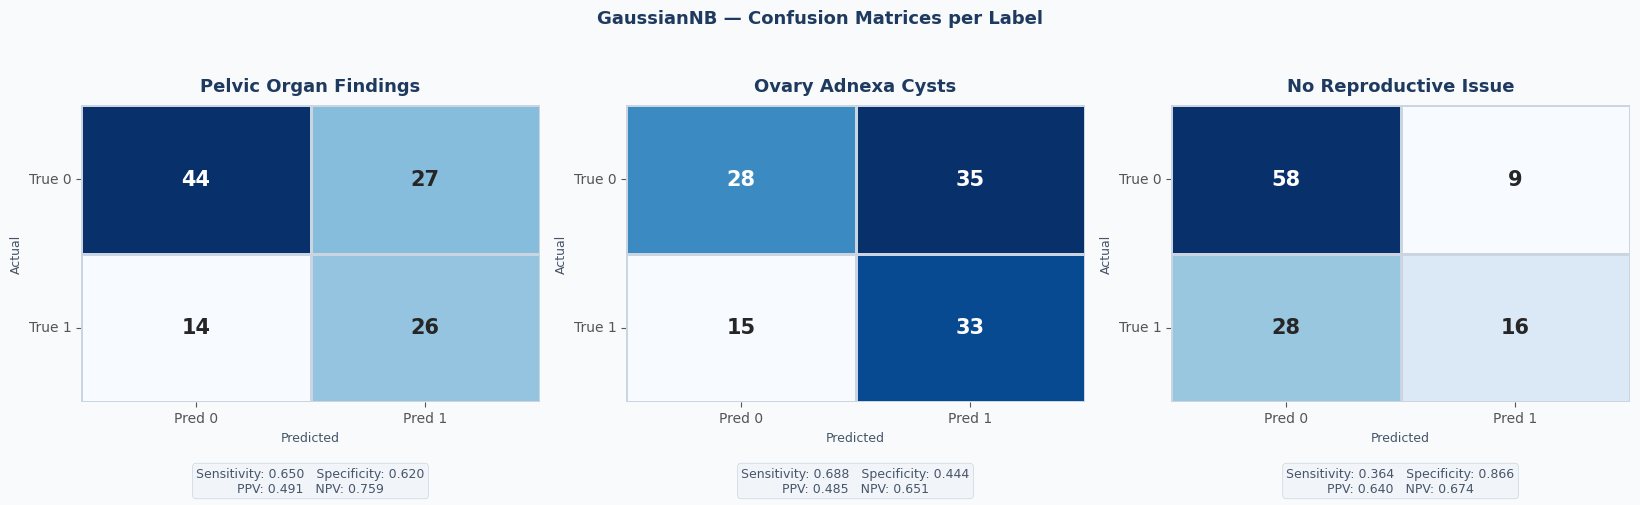

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


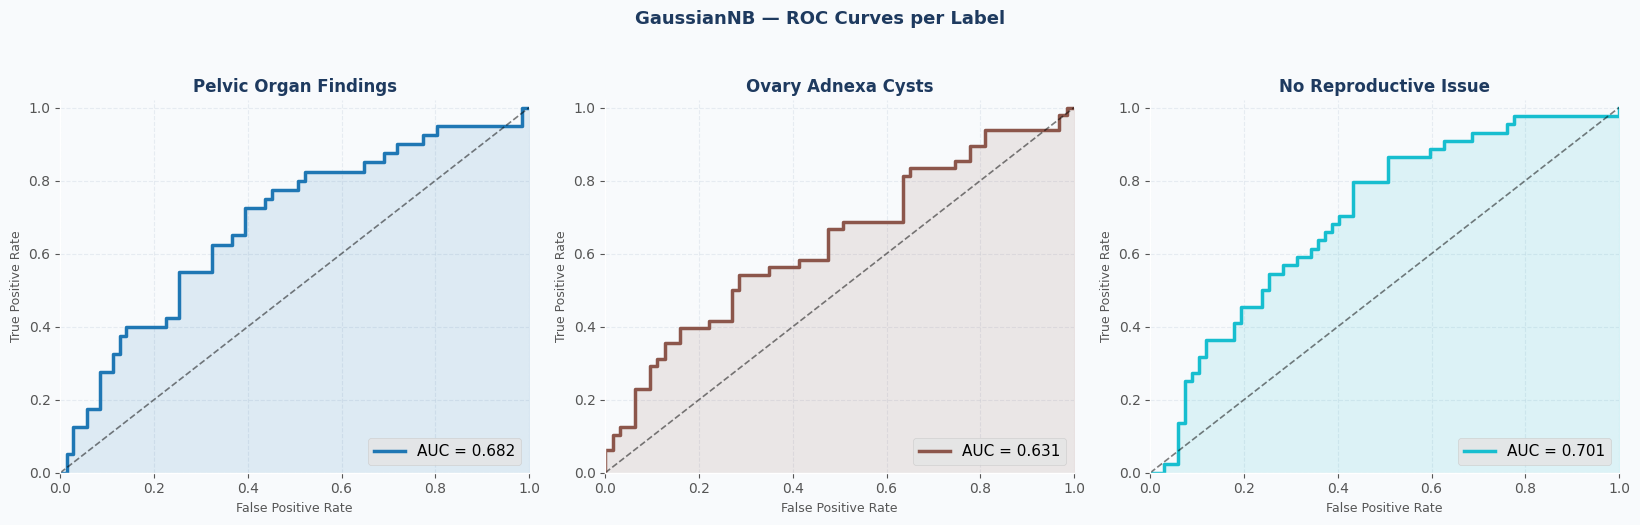


4b. Combined (Macro-Average) ROC Curve:


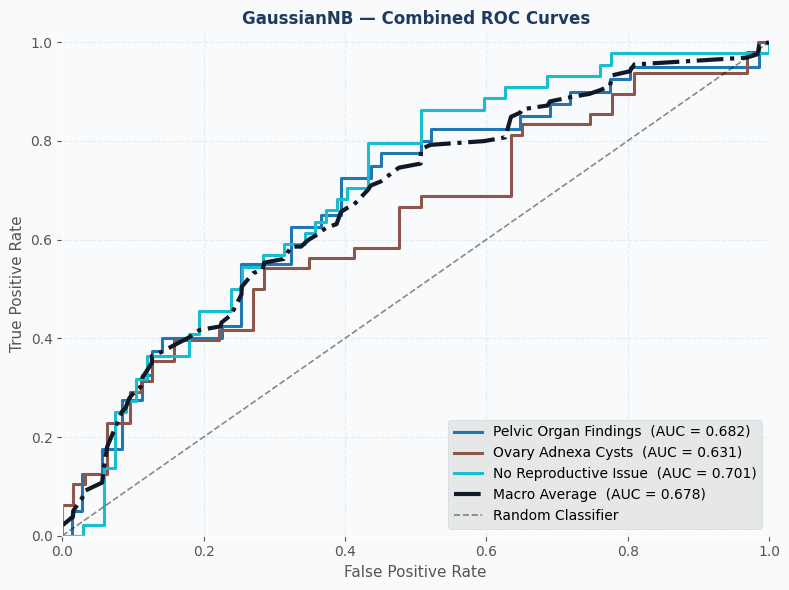

   Macro-Average AUC: 0.6782


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, multilabel_confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier
# For FT-Transformer → we use a simple custom version (most popular libraries like pytorch_tabular or rtdl require extra install;
# here we implement a minimal FT-Transformer style model for easy copy-paste)

# ──────────────────────────────────────────────────────────
#   Shared evaluation functions
# ──────────────────────────────────────────────────────────

def print_classification_report(y_true, y_pred, target_names):
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


def plot_roc_curves(y_true, y_proba, target_names):
    plt.figure(figsize=(10, 8))
    for i, name in enumerate(target_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-label ROC Curves')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


def plot_confusion_matrices(y_true, y_pred, target_names):
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, len(target_names), figsize=(5 * len(target_names), 4))
    if len(target_names) == 1:
        axes = [axes]
    for i, (cm, name) in enumerate(zip(mcm, target_names)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        axes[i].set_title(f'Confusion Matrix - {name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.show()


# ───────────────────────────────────────────
# 1. Naive Bayes (Class 3 - Classical)
# ───────────────────────────────────────────

print("\n=== Gaussian Naive Bayes (MultiOutput) ===")
nb = MultiOutputClassifier(GaussianNB())
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_proba_nb = np.column_stack([est.predict_proba(X_test)[:, 1] for est in nb.estimators_])

# Get target names dynamically from y_resampled.columns to ensure correctness
target_names = y_resampled.columns.tolist()

print_classification_report(y_test.values, y_pred_nb, target_names)
plot_roc_curves(y_test.values, y_proba_nb, target_names)
plot_confusion_matrices(y_test.values, y_pred_nb, target_names)
comprehensive_evaluation_report(y_test.values, y_pred_nb, y_proba_nb, target_names,short_names,n_labels, model_name="GaussianNB")



=== MLP (3-Layer) MultiTask ===
Epoch [10/100], Loss: 0.7006
Epoch [20/100], Loss: 0.5525
Epoch [30/100], Loss: 0.4307
Epoch [40/100], Loss: 0.2924
Epoch [50/100], Loss: 0.3787
Epoch [60/100], Loss: 0.4152
Epoch [70/100], Loss: 0.3998
Epoch [80/100], Loss: 0.2513
Epoch [90/100], Loss: 0.3259
Epoch [100/100], Loss: 0.1924

Comprehensive Evaluation Report for MLPClassifier

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.78      0.72      0.75        40
   group_ovary_adnexa_cysts       0.75      0.90      0.82        48
group_no_reproductive_issue       0.75      0.89      0.81        44

                  micro avg       0.76      0.84      0.80       132
                  macro avg       0.76      0.84      0.79       132
               weighted avg       0.76      0.84      0.80       132
                samples avg       0.76      0.82      0.78       132


2. Summary Metrics:
   Subset Acc

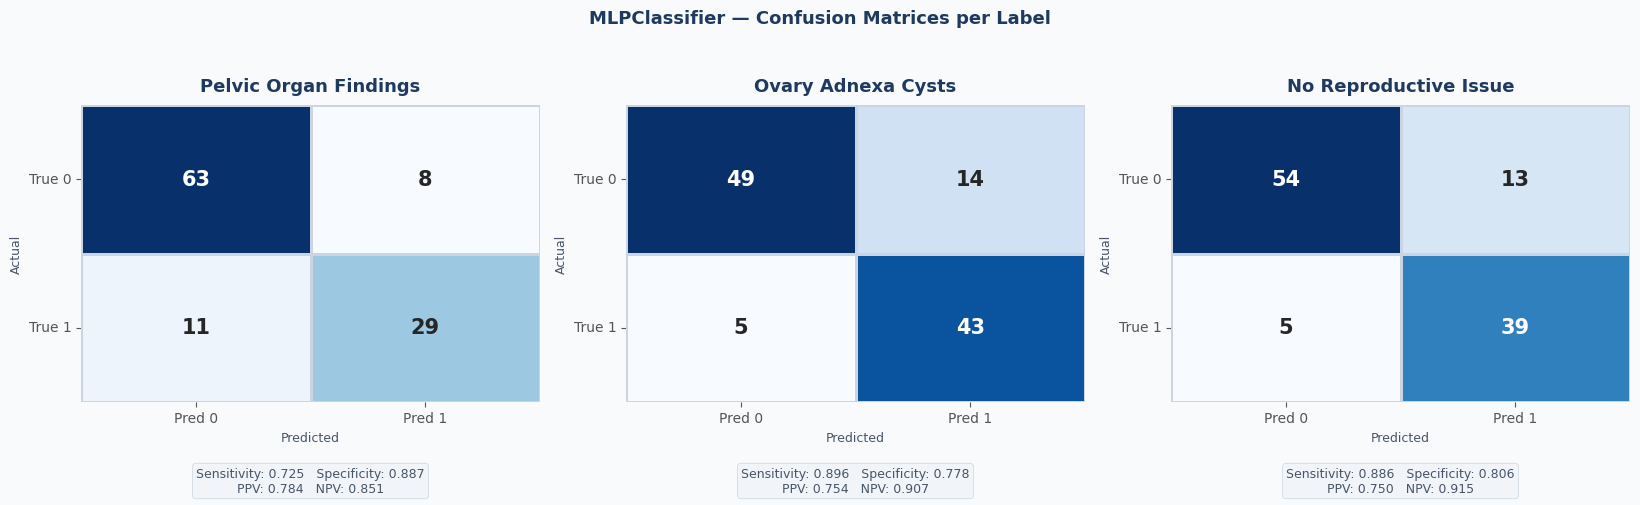

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


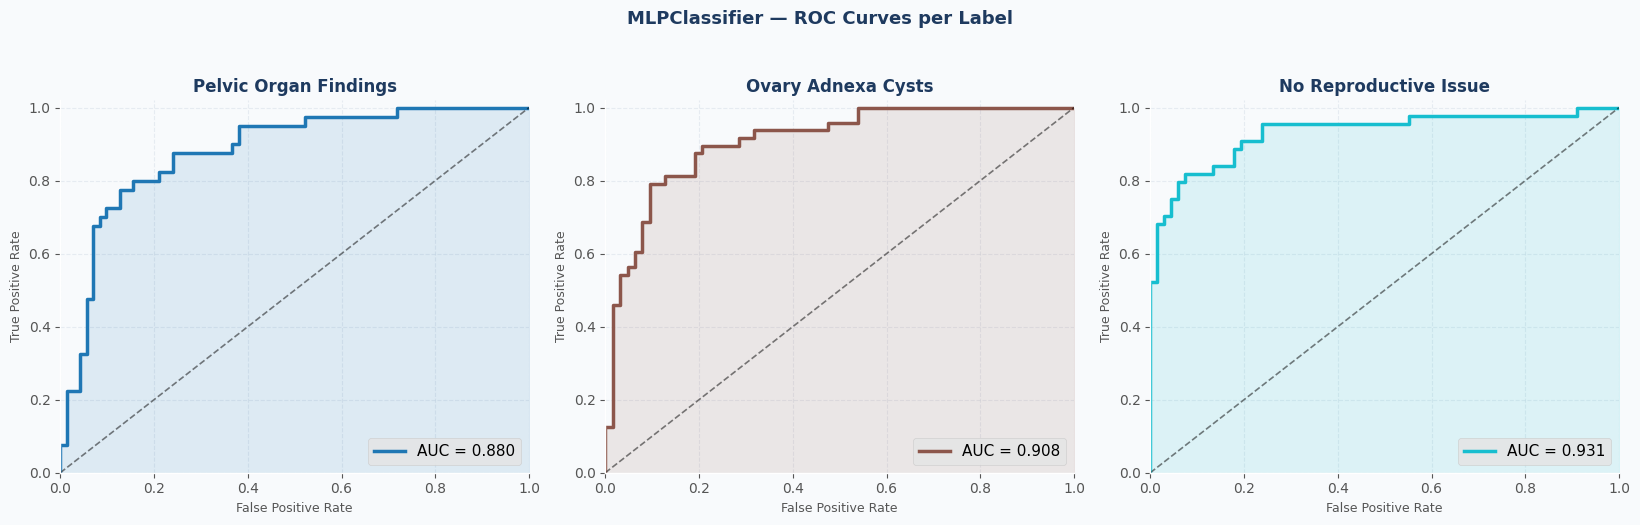


4b. Combined (Macro-Average) ROC Curve:


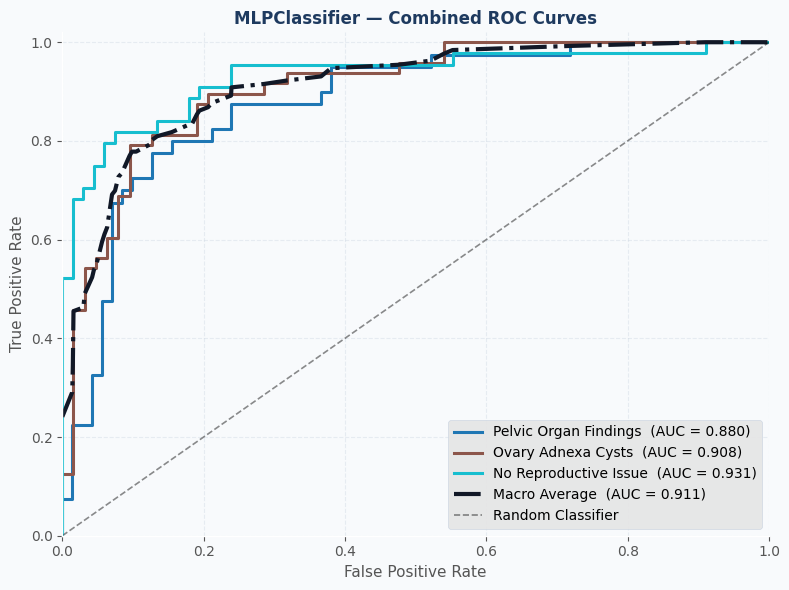

   Macro-Average AUC: 0.9113


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler # Import StandardScaler for correct scaling

print("\n=== MLP (3-Layer) MultiTask ===")

# 1. Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 128)
        self.bn_1 = nn.BatchNorm1d(128)
        self.relu_1 = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(128, 64)
        self.bn_2 = nn.BatchNorm1d(64)
        self.relu_2 = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.3)

        self.layer_3 = nn.Linear(64, output_dim)
        # No sigmoid here, it will be applied with BCEWithLogitsLoss

    def forward(self, x):
        x = self.dropout_1(self.relu_1(self.bn_1(self.layer_1(x))))
        x = self.dropout_2(self.relu_2(self.bn_2(self.layer_2(x))))
        x = self.layer_3(x)
        return x

# --- FIX START ---
# Ensure X_train and X_test are consistent with Y_train and Y_test (from resampled data split)
# And handle 'Menopause' column dropping and scaling correctly.

X_train_for_mlp = X_train.drop('Menopause', axis=1)
X_test_for_mlp = X_test.drop('Menopause', axis=1)

# Initialize and fit StandardScaler on the correctly prepared training data
scaler_mlp = StandardScaler()
X_train_scaled_mlp = scaler_mlp.fit_transform(X_train_for_mlp)
X_test_scaled_mlp = scaler_mlp.transform(X_test_for_mlp)

# Determine input and output dimensions using the *correctly prepared* data
input_dim = X_train_scaled_mlp.shape[1]
output_dim = Y_train.shape[1] # Number of target labels

mlp_model = MLP(input_dim, output_dim)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model.to(device)

# 2. Prepare data for PyTorch using the *newly scaled* data
X_train_tensor = torch.tensor(X_train_scaled_mlp, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled_mlp, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 3. Implement class weighting
# Calculate pos_weight for BCEWithLogitsLoss
# pos_weight = (total_negative_samples / total_positive_samples) for each label
positive_counts = Y_train_tensor.sum(axis=0)
negative_counts = Y_train_tensor.shape[0] - positive_counts
pos_weight = negative_counts / positive_counts
pos_weight = torch.where(pos_weight == float('inf'), torch.tensor(1.0), pos_weight) # Handle case where positive_counts is 0
pos_weight = pos_weight.to(device)

# Loss function with pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# 4. Training loop
epochs = 100
for epoch in range(epochs):
    mlp_model.train()
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 5. Make predictions and get probabilities
mlp_model.eval()
with torch.no_grad():
    outputs = mlp_model(X_test_tensor.to(device))
    y_proba_mlp = torch.sigmoid(outputs).cpu().numpy()
    y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

# --- FIX END ---

# 6. Call comprehensive_evaluation_report
# Ensure y_true_np, target_names, short_names, n_labels are available from previous cells
comprehensive_evaluation_report(Y_test.values, y_pred_mlp, y_proba_mlp, target_names, short_names, n_labels, model_name="MLPClassifier")


=== TabNet MultiTask ===


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.37976 | test_auc: 0.55617 |  0:00:00s
epoch 1  | loss: 1.14694 | test_auc: 0.56111 |  0:00:00s
epoch 2  | loss: 0.90526 | test_auc: 0.56519 |  0:00:00s
epoch 3  | loss: 1.06082 | test_auc: 0.56109 |  0:00:01s
epoch 4  | loss: 0.99464 | test_auc: 0.57029 |  0:00:01s
epoch 5  | loss: 0.94689 | test_auc: 0.5476  |  0:00:01s
epoch 6  | loss: 0.943   | test_auc: 0.54031 |  0:00:01s
epoch 7  | loss: 0.92106 | test_auc: 0.53485 |  0:00:01s
epoch 8  | loss: 0.81973 | test_auc: 0.57338 |  0:00:02s
epoch 9  | loss: 0.68607 | test_auc: 0.55999 |  0:00:02s
epoch 10 | loss: 0.65938 | test_auc: 0.55465 |  0:00:02s
epoch 11 | loss: 0.62863 | test_auc: 0.55827 |  0:00:02s
epoch 12 | loss: 0.71508 | test_auc: 0.57331 |  0:00:02s
epoch 13 | loss: 0.70957 | test_auc: 0.57137 |  0:00:02s
epoch 14 | loss: 0.63261 | test_auc: 0.60367 |  0:00:03s
epoch 15 | loss: 0.59417 | test_auc: 0.60518 |  0:00:03s
epoch 16 | loss: 0.63066 | test_auc: 0.58756 |  0:00:03s
epoch 17 | loss: 0.59141 | test

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


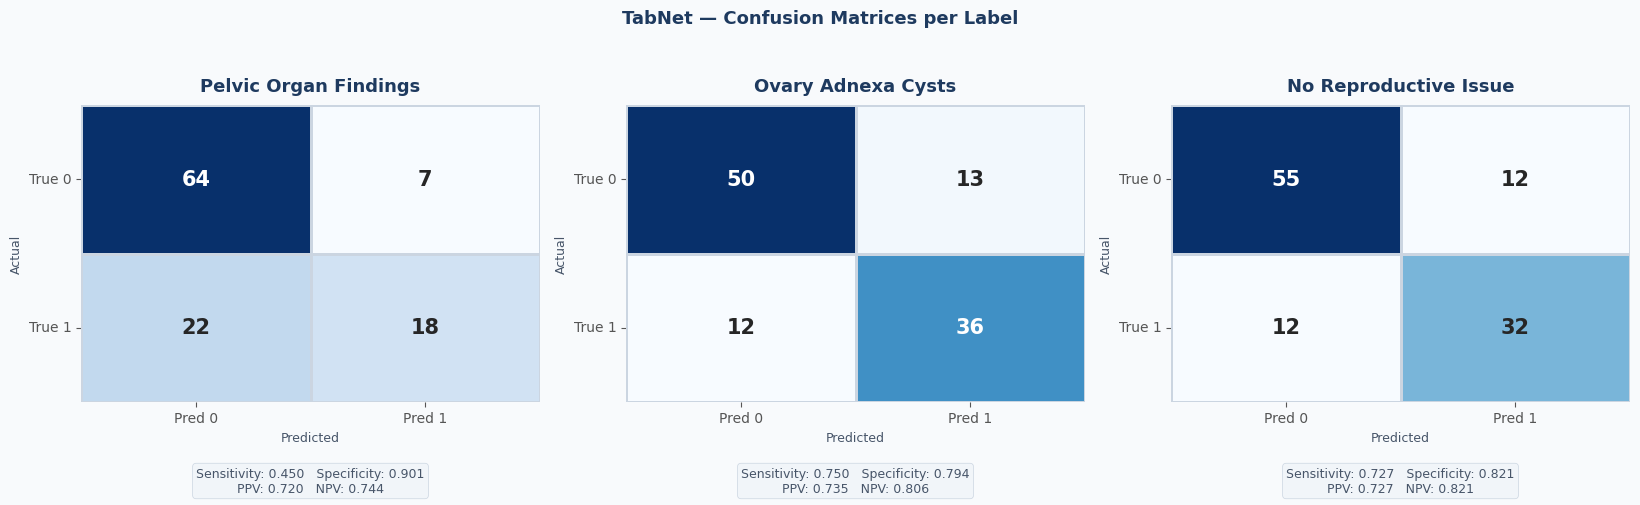

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


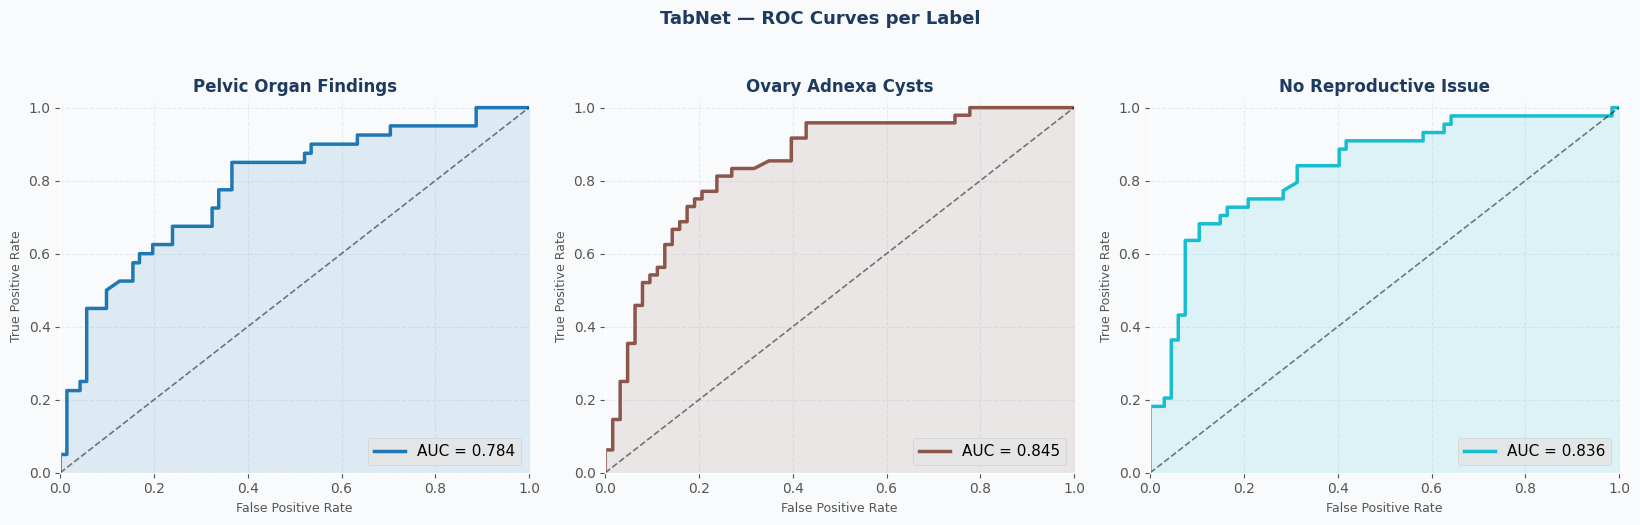


4b. Combined (Macro-Average) ROC Curve:


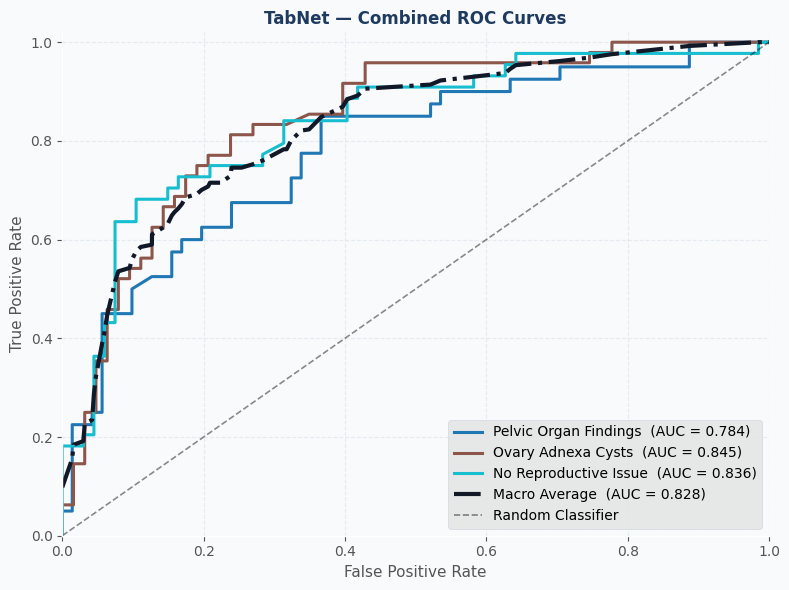

   Macro-Average AUC: 0.8278


In [ ]:
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler

print("\n=== TabNet MultiTask ===")

# --- FIX START ---
# Ensure X_train and X_test are consistent with Y_train and Y_test (from resampled data split)
# And handle 'Menopause' column dropping and scaling correctly.

X_train_for_tabnet = X_train.drop('Menopause', axis=1)
X_test_for_tabnet = X_test.drop('Menopause', axis=1)

# Initialize and fit StandardScaler on the correctly prepared training data
scaler_tabnet = StandardScaler()
X_train_processed = scaler_tabnet.fit_transform(X_train_for_tabnet)
X_test_processed = scaler_tabnet.transform(X_test_for_tabnet)
# --- FIX END ---

# If you have categorical features → fill these (recommended!)
# Otherwise keep empty
cat_idxs = []           # example: [0, 1, 3, 5]  ← column indices that are categorical
cat_dims = []           # example: [5, 4, 3, 2] ← number of unique values per cat column

tabnet_model = TabNetMultiTaskClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.3,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,                  # ignored if cat_idxs is empty
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=1
)

# ─── Fit ──────────────
tabnet_model.fit(
    X_train_processed,                        # Use processed training data
    Y_train.values,                           # Convert y_train to numpy array
    eval_set=[(X_test_processed, Y_test.values)],    # Convert y_test to numpy array for evaluation
    eval_name=['test'],
    eval_metric=['auc'],            # good for multi-label
    max_epochs=150,
    patience=30,                    # early stopping
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0
)

# ─── Predict ───────────────
probas_raw = tabnet_model.predict_proba(X_test_processed) # Use processed test data
preds_raw  = tabnet_model.predict(X_test_processed)      # Use processed test data

print("\nDebug: types and lengths")
print("predict_proba type:", type(probas_raw))
print("predict type     :", type(preds_raw))

# Handle predict_proba (usually list of (n_samples, 2) arrays → prob of class 1)
if isinstance(probas_raw, list):
    print(f"predict_proba: list with {len(probas_raw)} items")
    # Stack class 1 probabilities
    y_proba_tabnet = np.column_stack([p[:, 1] for p in probas_raw])
elif isinstance(probas_raw, np.ndarray):
    y_proba_tabnet = probas_raw[:, :, 1] if probas_raw.ndim == 3 else probas_raw[:, 1::2]
else:
    raise ValueError(f"Unexpected predict_proba type: {type(probas_raw)}")

# Handle predict (usually list of (n_samples,) binary arrays)
if isinstance(preds_raw, list):
    print(f"predict: list with {len(preds_raw)} items")
    y_pred_tabnet = np.column_stack(preds_raw)  # ← this converts list → (n_samples, n_labels) array
    # Convert string predictions to float first
    y_pred_tabnet = y_pred_tabnet.astype(float)
    # If items are (n_samples, 1), squeeze first
    if y_pred_tabnet.shape[1] == 1:
        y_pred_tabnet = y_pred_tabnet.squeeze(1)
elif isinstance(preds_raw, np.ndarray):
    y_pred_tabnet = preds_raw
else:
    raise ValueError(f"Unexpected predict type: {type(preds_raw)}")

# Final safety prints
print("\nShapes after conversion:")
print("y_test.shape       :", Y_test.shape)
print("y_pred_tabnet.shape :", y_pred_tabnet.shape)
print("y_proba_tabnet.shape:", y_proba_tabnet.shape)

# ─── After stacking y_pred_tabnet and y_proba_tabnet ──────

# Force y_pred_tabnet to be strict binary integers (0 or 1)
y_pred_tabnet = (y_pred_tabnet > 0.5).astype(int)          # if it was float
# or more robust:
y_pred_tabnet = np.round(y_pred_tabnet).astype(int)        # handles any minor floating-point noise

# Also ensure y_test is integer (in case it was float during loading)
y_test_int = Y_test.values.astype(int) # FIX: Convert to numpy array first, then astype(int)

# Quick debug prints (very helpful)
print("\nFinal shapes and dtypes:")
print("y_test     shape:", y_test_int.shape, "dtype:", y_test_int.dtype)
print("y_pred_tabnet shape:", y_pred_tabnet.shape, "dtype:", y_pred_tabnet.dtype)
print("Sample of y_pred_tabnet (first 5 rows):\n", y_pred_tabnet[:5])
print("Unique values in y_pred_tabnet:", np.unique(y_pred_tabnet))

# Safety check: both should be (n_samples, n_labels) with only 0 and 1
assert y_pred_tabnet.shape == y_test_int.shape
assert set(np.unique(y_pred_tabnet)) <= {0, 1}, "y_pred_tabnet still has non-binary values!"


comprehensive_evaluation_report(y_test_int, y_pred_tabnet, y_proba_tabnet,target_names, short_names, n_labels, model_name="TabNet")


=== Simple FT-Transformer Style Model ===
Epoch 10/60 - Loss: 0.5657
Epoch 20/60 - Loss: 0.5121
Epoch 30/60 - Loss: 0.4352
Epoch 40/60 - Loss: 0.3517
Epoch 50/60 - Loss: 0.3306
Epoch 60/60 - Loss: 0.2316

Comprehensive Evaluation Report for FT Transformer

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.68      0.38      0.48        40
   group_ovary_adnexa_cysts       0.76      0.73      0.74        48
group_no_reproductive_issue       0.66      0.91      0.76        44

                  micro avg       0.70      0.68      0.69       132
                  macro avg       0.70      0.67      0.66       132
               weighted avg       0.70      0.68      0.67       132
                samples avg       0.70      0.71      0.69       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.5586
   Macro F1 Score: 0.6635
   Hamming Loss: 0.2432

   Per-Cl

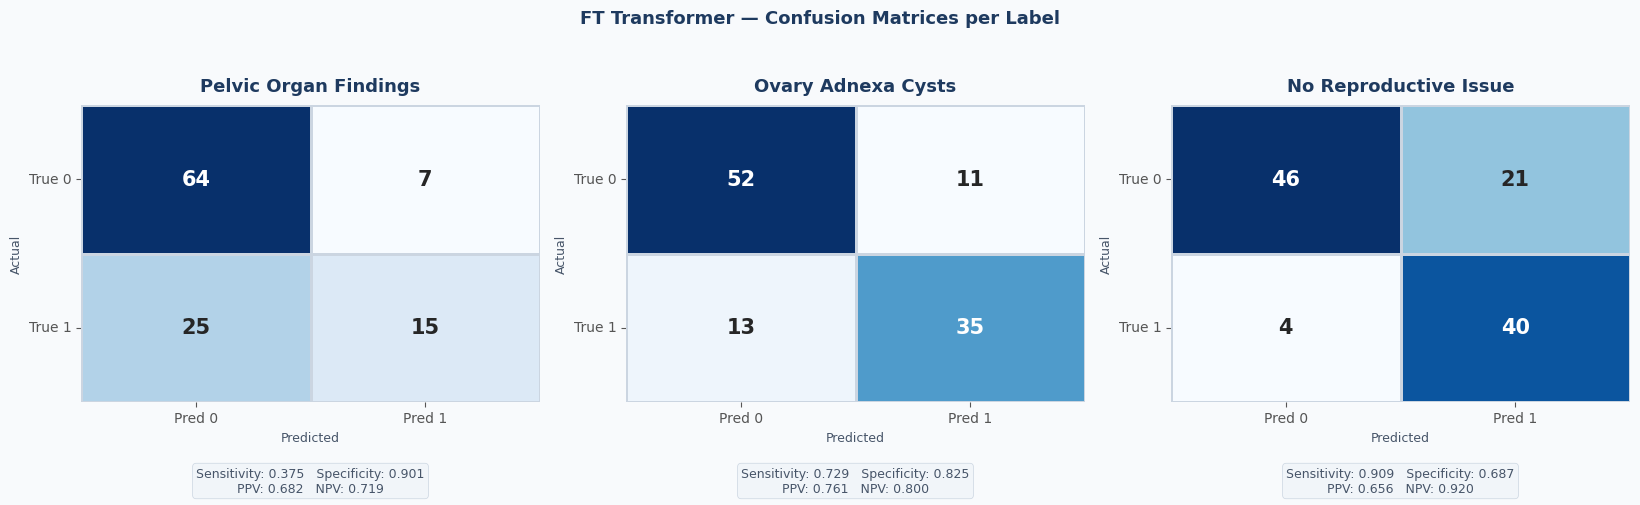

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


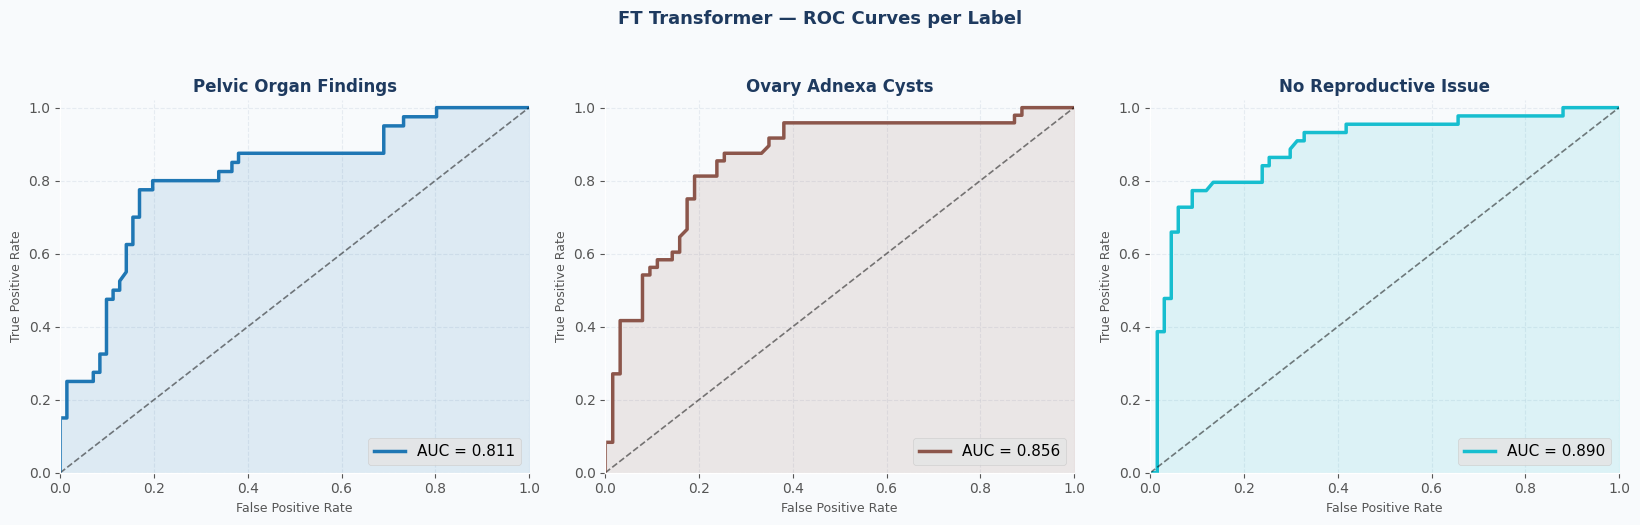


4b. Combined (Macro-Average) ROC Curve:


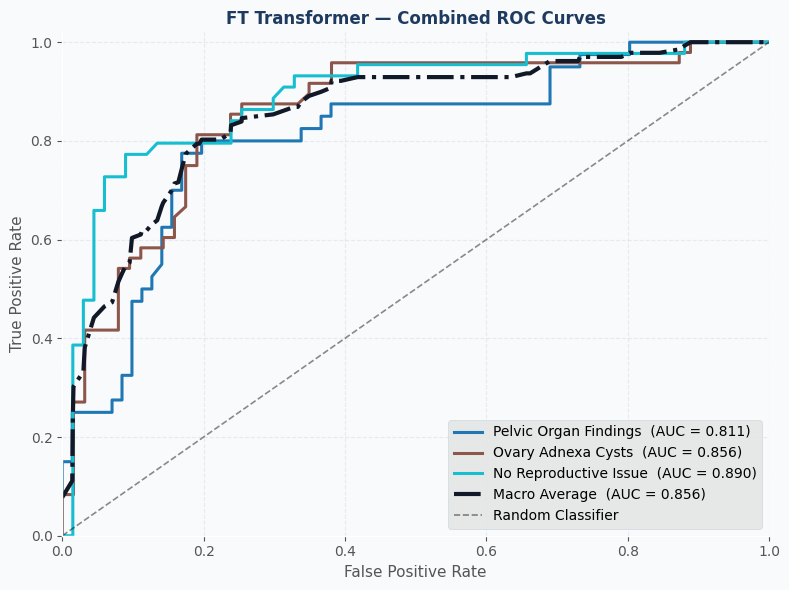

   Macro-Average AUC: 0.8562


In [ ]:
# ───────────────────────────────────────
# 3. FT-Transformer (minimal custom PyTorch version)
#   Feature Tokenizer + simple Transformer encoder
# ───────────────────────────────────────────

print("\n=== Simple FT-Transformer Style Model ===")

class FTTransformer(nn.Module):
    def __init__(self, num_features, num_cat, cat_dims, num_num, embed_dim=64, num_heads=4, num_layers=3, dropout=0.1, out_dim=None):
        super().__init__()
        self.out_dim = out_dim if out_dim is not None else 1  # will be multiplied later

        # Feature Tokenizer: numerical → linear proj, categorical → embedding
        self.num_proj = nn.Linear(1, embed_dim) if num_num > 0 else None
        self.cat_embs = nn.ModuleList([nn.Embedding(d, embed_dim) for d in cat_dims]) if num_cat > 0 else None

        # [CLS] token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, self.out_dim * num_labels)  # flattened output
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_cat, x_num):
        # x_cat: (bs, num_cat), x_num: (bs, num_num)

        embeds = []

        # Categorical embeddings
        if self.cat_embs is not None:
            for i in range(len(self.cat_embs)):
                embeds.append(self.cat_embs[i](x_cat[:, i]).unsqueeze(1)) # <-- FIX: unsqueeze to add dimension

        # Numerical projections
        if self.num_proj is not None and x_num.shape[1] > 0:
            num_emb = self.num_proj(x_num.unsqueeze(-1))  # (bs, num_num, embed_dim)
            embeds.append(num_emb)

        if not embeds:
            raise ValueError("No features provided")

        x = torch.cat(embeds, dim=1)  # (bs, num_features, embed_dim)

        # Add CLS token
        bs = x.size(0)
        cls_tokens = self.cls_token.expand(bs, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Transformer
        x = self.transformer(x)

        # Take CLS representation
        cls_out = x[:, 0, :]

        # Head → multi-label
        out = self.head(cls_out)
        out = out.view(bs, -1, self.out_dim)  # (bs, num_labels, 1)
        out = out.squeeze(-1)
        return self.sigmoid(out)


# ─── Prepare data splits for FT ───────────────
# Assume you have already encoded categoricals as integers (0..dim-1)

# Fix: Define global categorical feature names and dimensions
current_X_cols = [col for col in X_resampled.columns if not col.startswith('group_')]
categorical_feature_names_global = [col for col in label_encoders.keys() if col in current_X_cols]
cat_dims_global = [len(label_encoders[col].classes_) for col in categorical_feature_names_global]

# X_train and X_test are numpy arrays at this point.
# Convert them to DataFrames to easily handle column names and types.
# Use X_cols derived from X_resampled to ensure column consistency.
X_train_ft_df = pd.DataFrame(X_train, columns=current_X_cols)
X_test_ft_df = pd.DataFrame(X_test, columns=current_X_cols)

# Identify categorical columns: assuming those that were LabelEncoded are categorical
categorical_feature_names = [col for col in categorical_feature_names_global if col in X_train_ft_df.columns]

# Get indices of categorical and numerical features
cat_cols_idx = [X_train_ft_df.columns.get_loc(col) for col in categorical_feature_names]
num_cols_idx = [i for i, col in enumerate(X_train_ft_df.columns) if col not in categorical_feature_names]

# Map the global cat_dims to the specific categorical features used here
cat_dims_map = {name: dim for name, dim in zip(categorical_feature_names_global, cat_dims_global)}
cat_dims = [cat_dims_map[col_name] for col_name in categorical_feature_names]

# Preprocess categorical features for FT-Transformer: round and clip
# Create copies first to avoid modifying original X_train/X_test
X_train_processed_ft = X_train_ft_df.values.copy()
X_test_processed_ft = X_test_ft_df.values.copy()

for i, col_idx in enumerate(cat_cols_idx):
    max_val = cat_dims_global[i] - 1 # Use global cat_dims_global for consistent max_val
    # Round to nearest integer, then clip to ensure it's within [0, max_val]
    # And convert to integer type
    X_train_processed_ft[:, col_idx] = np.clip(np.round(X_train_processed_ft[:, col_idx]), 0, max_val).astype(int)
    X_test_processed_ft[:, col_idx] = np.clip(np.round(X_test_processed_ft[:, col_idx]), 0, max_val).astype(int)

# Create PyTorch tensors from the processed arrays
X_train_cat = torch.tensor(X_train_processed_ft[:, cat_cols_idx], dtype=torch.long)
X_train_num = torch.tensor(X_train_processed_ft[:, num_cols_idx], dtype=torch.float32)
X_test_cat  = torch.tensor(X_test_processed_ft[:, cat_cols_idx], dtype=torch.long)
X_test_num  = torch.tensor(X_test_processed_ft[:, num_cols_idx], dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32) # Ensure y_train is numpy array
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32)  # Ensure y_test is numpy array

train_ds = TensorDataset(X_train_cat, X_train_num, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

# Model
num_labels = y_train.shape[1]

model_ft = FTTransformer(
    num_features=len(current_X_cols),
    num_cat=len(cat_cols_idx),
    cat_dims=cat_dims,
	num_num=len(num_cols_idx),
    embed_dim=96,
    num_heads=6,
    num_layers=4,
    dropout=0.2,
    out_dim=1
).to('cuda' if torch.cuda.is_available() else 'cpu')

optimizer = optim.AdamW(model_ft.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCELoss()

# Simple training loop (you can add scheduler/early stopping)
epochs = 60
for epoch in range(epochs):
    model_ft.train()
    total_loss = 0
    for cat, num, yb in train_loader:
        cat, num, yb = cat.to(model_ft.cls_token.device), num.to(model_ft.cls_token.device), yb.to(model_ft.cls_token.device)
        optimizer.zero_grad()
        out = model_ft(cat, num)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

# Evaluate
model_ft.eval()
with torch.no_grad():
    preds_proba_ft = model_ft(X_test_cat.to(model_ft.cls_token.device), X_test_num.to(model_ft.cls_token.device)).cpu().numpy()

y_pred_ft = (preds_proba_ft > 0.5).astype(int)

#print_classification_report(y_test.values, y_pred_ft, target_names)
#plot_roc_curves(y_test.values, preds_proba_ft, target_names)
#plot_confusion_matrices(y_test.values, y_pred_ft, target_names)
comprehensive_evaluation_report(y_test.values, y_pred_ft, preds_proba_ft, target_names, short_names, n_labels, model_name="FT Transformer")


=== Ensemble 1: Soft Voting (RF + XGBoost + LightGBM) ===

Comprehensive Evaluation Report for Soft Voting Ensemble (RF + XGB + LGBM)

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.96      0.68      0.79        40
   group_ovary_adnexa_cysts       0.84      0.90      0.87        48
group_no_reproductive_issue       0.75      0.89      0.81        44

                  micro avg       0.83      0.83      0.83       132
                  macro avg       0.85      0.82      0.83       132
               weighted avg       0.85      0.83      0.83       132
                samples avg       0.78      0.81      0.79       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7568
   Macro F1 Score: 0.8251
   Hamming Loss: 0.1351

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.8739
     group_ovary_adnexa_cysts : 0.8829
     group_no_reproductive_i

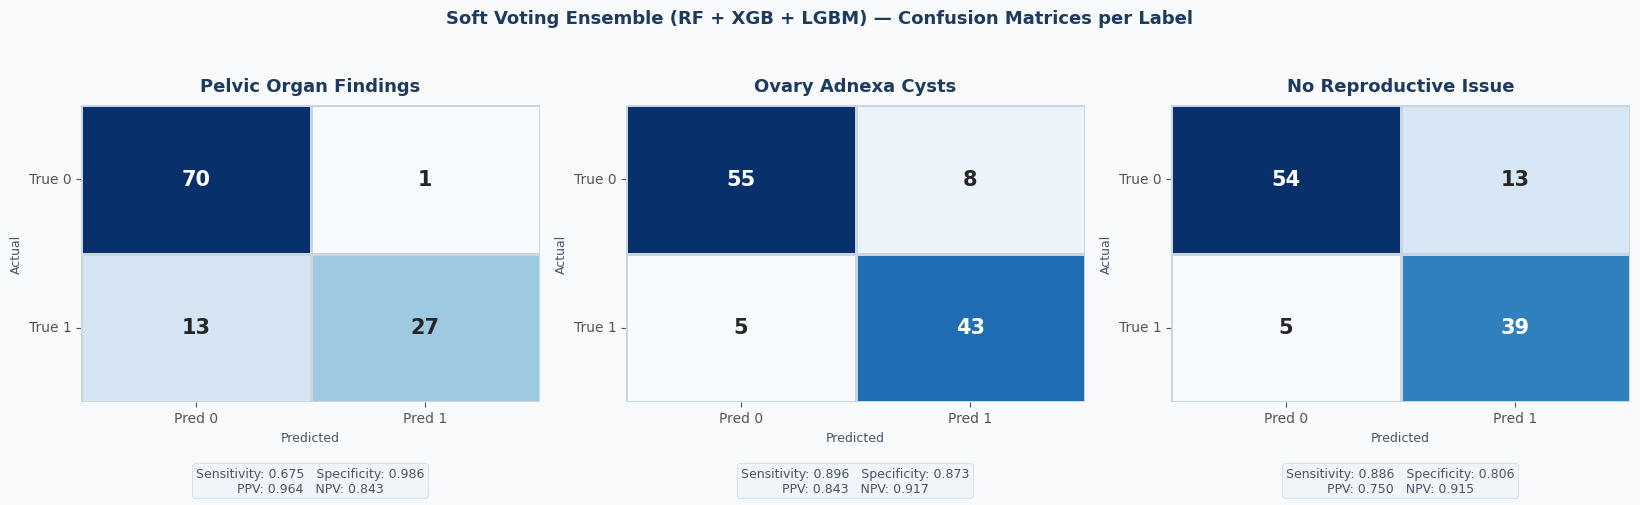

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


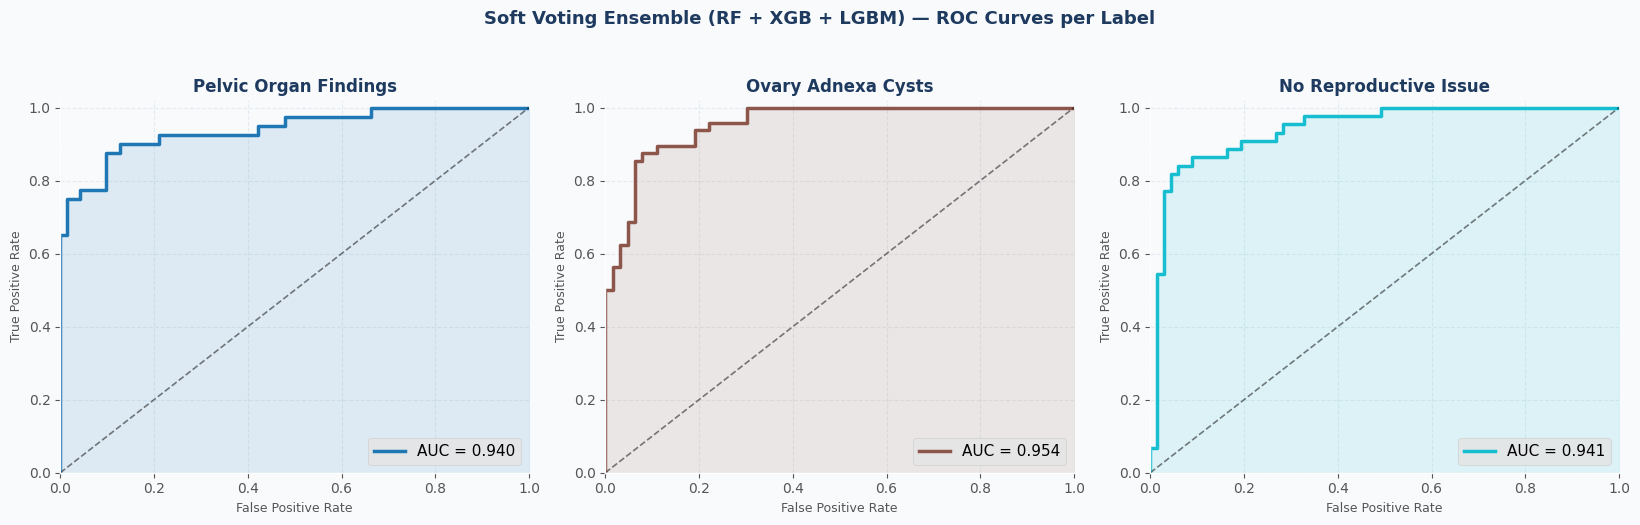


4b. Combined (Macro-Average) ROC Curve:


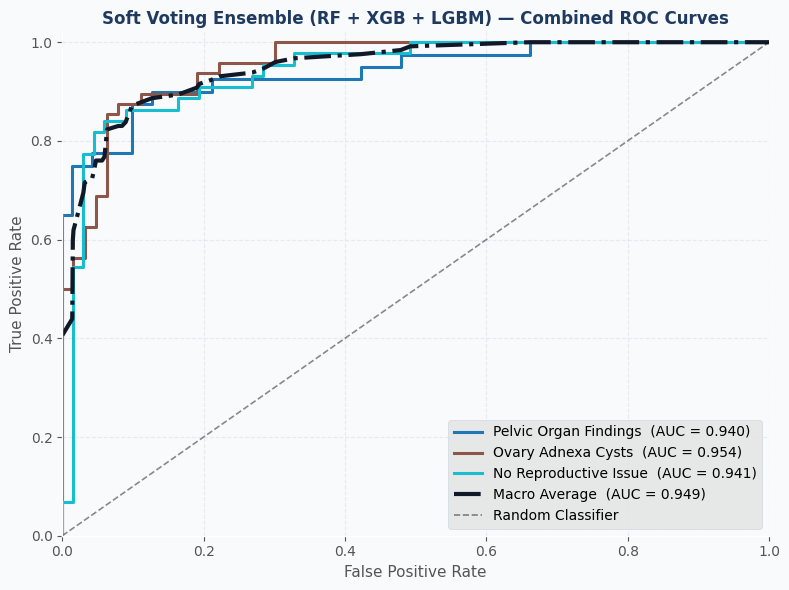

   Macro-Average AUC: 0.9490


In [ ]:
# Ensemble 1 — Soft Voting (RF + XGBoost + LightGBM)
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('\n=== Ensemble 1: Soft Voting (RF + XGBoost + LightGBM) ===')

X_tr1, X_te1, Y_tr1, Y_te1 = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

voting_clf = VotingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss')),
        ('lgbm', LGBMClassifier(n_estimators=200, random_state=42, class_weight='balanced', verbose=-1)),
    ],
    voting='soft'
)

ensemble1 = MultiOutputClassifier(voting_clf, n_jobs=-1)
ensemble1.fit(X_tr1, Y_tr1)

y_pred_ens1  = ensemble1.predict(X_te1)
y_proba_ens1 = np.column_stack([p[:, 1] for p in ensemble1.predict_proba(X_te1)])

target_names = Y_te1.columns.tolist()
short_names  = [t.replace('group_', '').replace('_', ' ').title() for t in target_names]
n_labels     = len(target_names)

comprehensive_evaluation_report(
    Y_te1.values, y_pred_ens1, y_proba_ens1,
    target_names, short_names, n_labels,
    model_name='Soft Voting Ensemble (RF + XGB + LGBM)'
)


# Proposed Model


=== Ensemble 2: Stacking (RF + SVM -> LightGBM meta-learner) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Comprehensive Evaluation Report for Stacking Ensemble (RF + SVM -> LightGBM)

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.92      0.90      0.91        40
   group_ovary_adnexa_cysts       0.88      0.88      0.88        48
group_no_reproductive_issue       0.82      0.84      0.83        44

                  micro avg       0.87      0.87      0.87       132
                  macro avg       0.87      0.87      0.87       132
               weighted avg       0.87      0.87      0.87       132
                samples avg       0.83      0.86      0.84       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7928
   Macro F1 Score: 0.8726
   Hamming Loss: 0.1021

   Per-Class Accuracy:
     group_pelvic_organ_findings: 0.9369
     group_ovary_adnexa_cysts : 0.8919
     group_no_reproductive_issue: 0.8649

3. Confusion Matrices per Label:


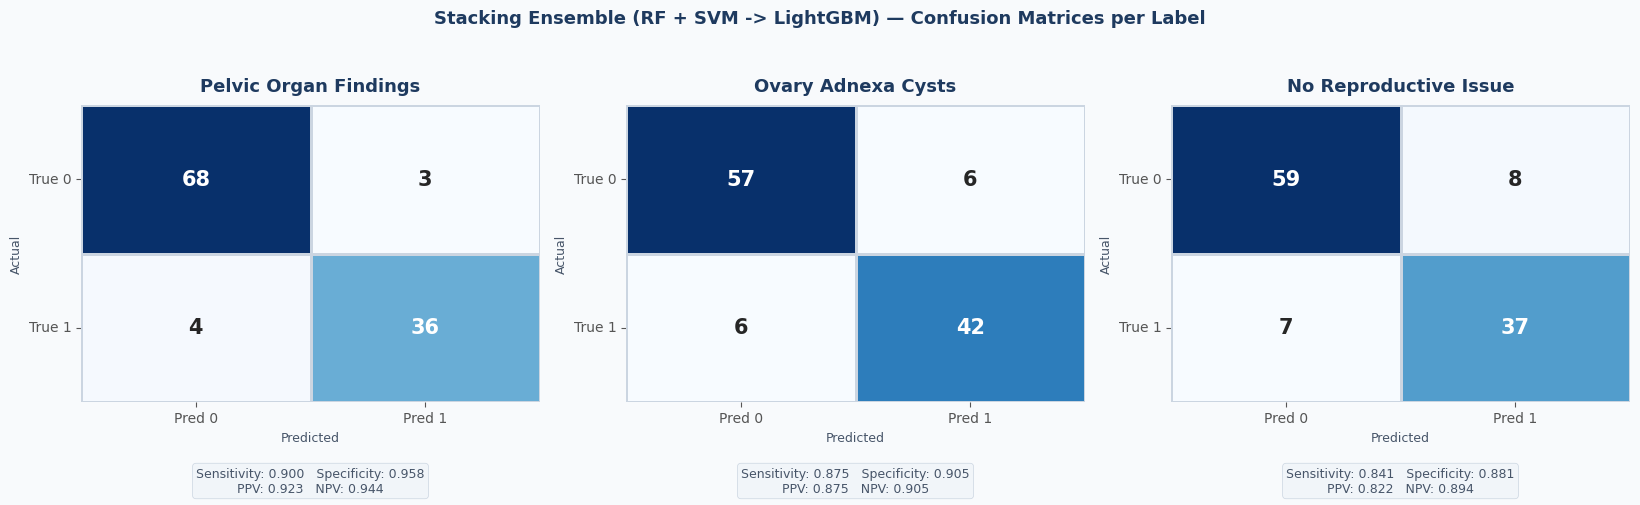

/tmp/ipykernel_10723/1967466667.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  label_colors = plt.cm.get_cmap('tab10', n_labels)



4a. Individual ROC Curves per Label:


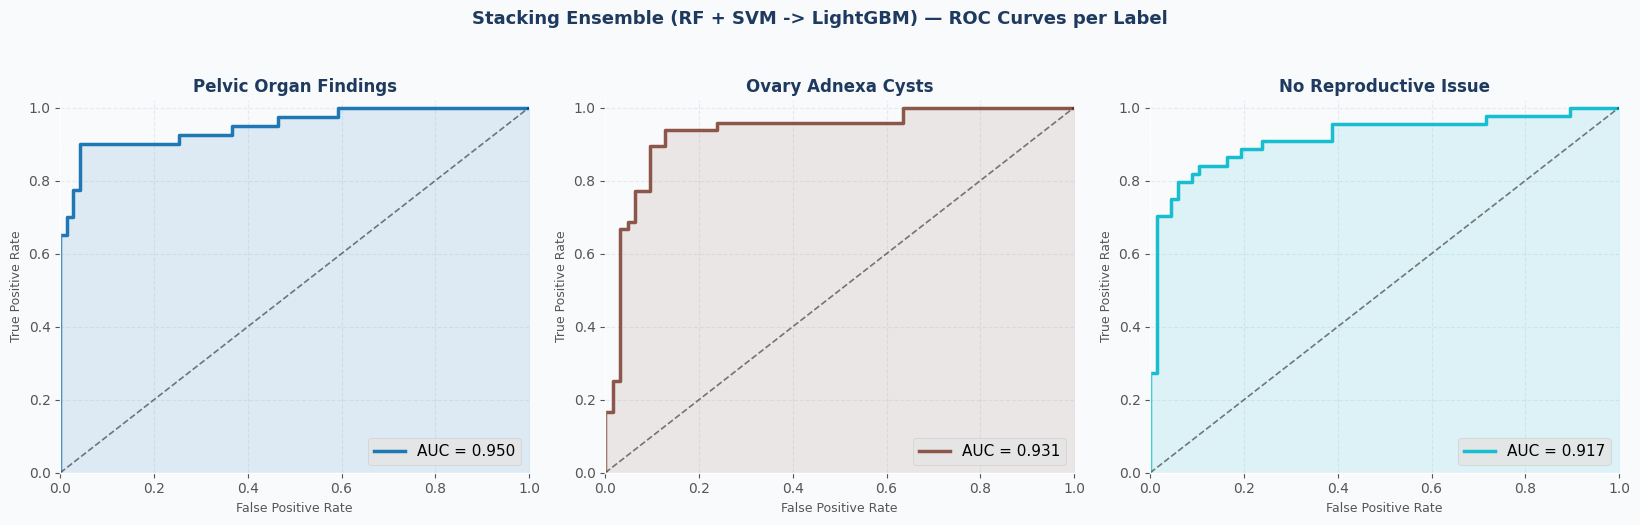


4b. Combined (Macro-Average) ROC Curve:


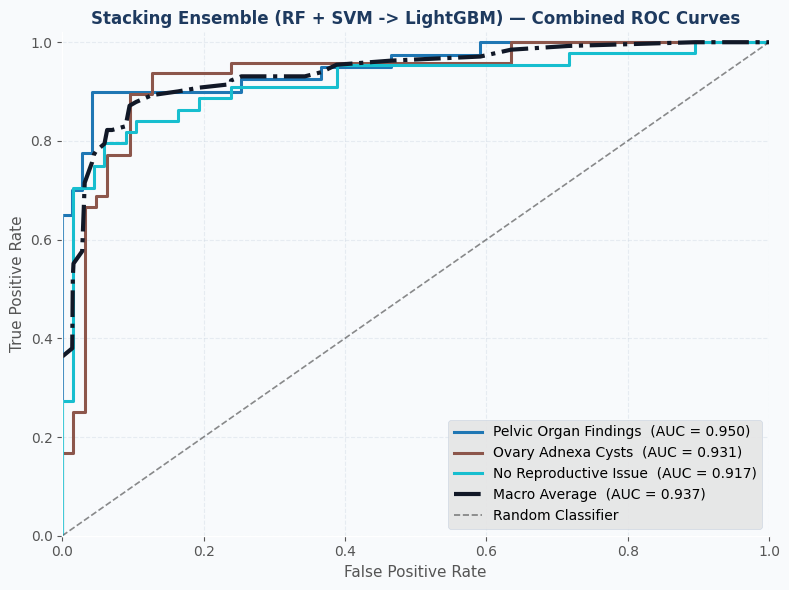

   Macro-Average AUC: 0.9366


In [ ]:
# Ensemble 2 — Stacking (RF + SVM -> LightGBM meta-learner)
import numpy as np
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

print('\n=== Ensemble 2: Stacking (RF + SVM -> LightGBM meta-learner) ===')

X_tr2, X_te2, Y_tr2, Y_te2 = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

level0 = [
    ('rf',  RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)),
    ('svm', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
]
meta = LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', verbose=-1)

stacking_clf = StackingClassifier(
    estimators=level0,
    final_estimator=meta,
    cv=5,
    stack_method='predict_proba',
    passthrough=True,   # original features also reach the meta-learner
    n_jobs=-1
)

ensemble2 = MultiOutputClassifier(stacking_clf, n_jobs=1)  # inner CV already parallel
ensemble2.fit(X_tr2, Y_tr2)

y_pred_ens2  = ensemble2.predict(X_te2)
y_proba_ens2 = np.column_stack([p[:, 1] for p in ensemble2.predict_proba(X_te2)])

target_names = Y_te2.columns.tolist()
short_names  = [t.replace('group_', '').replace('_', ' ').title() for t in target_names]
n_labels     = len(target_names)

comprehensive_evaluation_report(
    Y_te2.values, y_pred_ens2, y_proba_ens2,
    target_names, short_names, n_labels,
    model_name='Stacking Ensemble (RF + SVM -> LightGBM)'
)


Cross class ensemble

In [ ]:
# ── Shared cross-class ensemble setup ────────────────────────────────────
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

# ── Common split ──────────────────────────────────────────────────────────
CE_X_train, CE_X_test, CE_Y_train, CE_Y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# ── Scaling (needed by Class 2 & 3) ──────────────────────────────────────
ce_scaler = StandardScaler()
CE_X_train_sc = ce_scaler.fit_transform(CE_X_train)
CE_X_test_sc  = ce_scaler.transform(CE_X_test)

CE_target_names = CE_Y_test.columns.tolist()
CE_short_names  = [t.replace('group_','').replace('_',' ').title() for t in CE_target_names]
CE_n_labels     = len(CE_target_names)

# ════════════════════════════════
# CLASS 1 — tree/boosting
# ════════════════════════════════
print('Training Class-1 models (RF, XGB, LGBM)...')
ce_rf   = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1))
ce_rf.fit(CE_X_train, CE_Y_train)

ce_xgb  = MultiOutputClassifier(XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss'))
ce_xgb.fit(CE_X_train, CE_Y_train)

ce_lgbm = MultiOutputClassifier(LGBMClassifier(n_estimators=200, random_state=42, class_weight='balanced', verbose=-1))
ce_lgbm.fit(CE_X_train, CE_Y_train)

def proba_c1(model, X):
    return np.column_stack([p[:, 1] for p in model.predict_proba(X)])

# ════════════════════════════════
# CLASS 2 — probabilistic/distance (on scaled data)
# ════════════════════════════════
print('Training Class-2 models (MLKNN, SVM, NB)...')
ce_mlknn = CustomMLKNN(k=7)   # class defined in Cell 51
ce_mlknn.fit(CE_X_train_sc, CE_Y_train)

ce_svm = MultiOutputClassifier(SVC(probability=True, random_state=42, class_weight='balanced'))
ce_svm.fit(CE_X_train_sc, CE_Y_train)

ce_nb = MultiOutputClassifier(GaussianNB())
ce_nb.fit(CE_X_train_sc, CE_Y_train)

def proba_c2_mlknn(X): return ce_mlknn.predict_proba(X)
def proba_c2_svm(X):   return np.column_stack([p[:, 1] for p in ce_svm.predict_proba(X)])
def proba_c2_nb(X):    return np.column_stack([p[:, 1] for p in ce_nb.predict_proba(X)])

# ════════════════════════════════
# CLASS 3 — deep learning (on scaled data)
# ════════════════════════════════
print('Training Class-3 models (MLP, TabNet, FT-Transformer)...')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- MLP (reuse class from Cell 54) ---
ce_mlp = MLP(CE_X_train_sc.shape[1], CE_Y_train.shape[1]).to(device)
X_tr_t  = torch.tensor(CE_X_train_sc, dtype=torch.float32)
Y_tr_t  = torch.tensor(CE_Y_train.values, dtype=torch.float32)
X_te_t  = torch.tensor(CE_X_test_sc,  dtype=torch.float32)
pos_w = (Y_tr_t.shape[0] - Y_tr_t.sum(0)) / Y_tr_t.sum(0)
pos_w = torch.where(pos_w == float('inf'), torch.tensor(1.0), pos_w).to(device)
crit_mlp = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt_mlp  = optim.Adam(ce_mlp.parameters(), lr=1e-3)
ds_mlp   = TensorDataset(X_tr_t, Y_tr_t)
dl_mlp   = DataLoader(ds_mlp, batch_size=32, shuffle=True)
for ep in range(100):
    ce_mlp.train()
    for xb, yb in dl_mlp:
        xb, yb = xb.to(device), yb.to(device)
        opt_mlp.zero_grad()
        crit_mlp(ce_mlp(xb), yb).backward()
        opt_mlp.step()
ce_mlp.eval()
with torch.no_grad():
    ce_proba_mlp = torch.sigmoid(ce_mlp(X_te_t.to(device))).cpu().numpy()

# --- TabNet ---
ce_tabnet = TabNetMultiTaskClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.3,
    cat_idxs=[], cat_dims=[], cat_emb_dim=1,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=0
)
ce_tabnet.fit(
    CE_X_train_sc, CE_Y_train.values,
    eval_set=[(CE_X_test_sc, CE_Y_test.values)],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=150, patience=30,
    batch_size=256, virtual_batch_size=128, num_workers=0
)
tn_raw = ce_tabnet.predict_proba(CE_X_test_sc)
if isinstance(tn_raw, list):
    ce_proba_tabnet = np.column_stack([p[:, 1] for p in tn_raw])
else:
    ce_proba_tabnet = tn_raw[:, :, 1] if tn_raw.ndim == 3 else tn_raw[:, 1::2]

# --- FT-Transformer (reuse FTTransformer class and cat/num index info from Cell 59) ---
ce_ft = FTTransformer(
    num_features=len(current_X_cols),
    num_cat=len(cat_cols_idx),
    cat_dims=cat_dims,
    num_num=len(num_cols_idx),
    embed_dim=96, num_heads=6, num_layers=4, dropout=0.2, out_dim=1
).to(device)
# Rebuild FT-Transformer tensors from CE split
CE_X_tr_ft = pd.DataFrame(CE_X_train.values, columns=current_X_cols)
CE_X_te_ft = pd.DataFrame(CE_X_test.values,  columns=current_X_cols)
CE_arr_tr  = CE_X_tr_ft.values.copy()
CE_arr_te  = CE_X_te_ft.values.copy()
for i_c, c_idx in enumerate(cat_cols_idx):
    mx = cat_dims[i_c] - 1
    CE_arr_tr[:, c_idx] = np.clip(np.round(CE_arr_tr[:, c_idx]), 0, mx).astype(int)
    CE_arr_te[:, c_idx] = np.clip(np.round(CE_arr_te[:, c_idx]), 0, mx).astype(int)
CE_cat_tr = torch.tensor(CE_arr_tr[:, cat_cols_idx], dtype=torch.long)
CE_num_tr = torch.tensor(CE_arr_tr[:, num_cols_idx], dtype=torch.float32)
CE_cat_te = torch.tensor(CE_arr_te[:, cat_cols_idx], dtype=torch.long)
CE_num_te = torch.tensor(CE_arr_te[:, num_cols_idx], dtype=torch.float32)
CE_y_tr_t = torch.tensor(CE_Y_train.values, dtype=torch.float32)
ds_ft  = TensorDataset(CE_cat_tr, CE_num_tr, CE_y_tr_t)
dl_ft  = DataLoader(ds_ft, batch_size=256, shuffle=True)
opt_ft = optim.AdamW(ce_ft.parameters(), lr=1e-3, weight_decay=1e-5)
crit_ft = nn.BCELoss()
for ep in range(60):
    ce_ft.train()
    for cat_b, num_b, yb in dl_ft:
        cat_b = cat_b.to(device); num_b = num_b.to(device); yb = yb.to(device)
        opt_ft.zero_grad()
        crit_ft(ce_ft(cat_b, num_b), yb).backward()
        opt_ft.step()
ce_ft.eval()
with torch.no_grad():
    ce_proba_ft = ce_ft(CE_cat_te.to(device), CE_num_te.to(device)).cpu().numpy()

print('All six base models trained. Ready for ensemble construction.')


Training Class-1 models (RF, XGB, LGBM)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:01:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:01:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:01:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Class-2 models (MLKNN, SVM, NB)...
Training Class-3 models (MLP, TabNet, FT-Transformer)...

Early stopping occurred at epoch 68 with best_epoch = 38 and best_test_auc = 0.80315


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


All six base models trained. Ready for ensemble construction.



=== Ensemble C: Stacking (LGBM + NB + FT-Transformer) ===
  OOF fold 1/5...
  OOF fold 2/5...
  OOF fold 3/5...
  OOF fold 4/5...
  OOF fold 5/5...

Comprehensive Evaluation Report for  Stacking (LGBM + NB + FT-Transformer)

1. Detailed Classification Report:
                             precision    recall  f1-score   support

group_pelvic_organ_findings       0.87      0.65      0.74        40
   group_ovary_adnexa_cysts       0.82      0.83      0.82        48
group_no_reproductive_issue       0.73      0.86      0.79        44

                  micro avg       0.79      0.79      0.79       132
                  macro avg       0.80      0.78      0.79       132
               weighted avg       0.80      0.79      0.79       132
                samples avg       0.77      0.78      0.77       132


2. Summary Metrics:
   Subset Accuracy (all labels correctly predicted per sample): 0.7117
   Macro F1 Score: 0.7864
   Hamming Loss: 0.1652

   Per-Class Accuracy:
     group_pelvic_

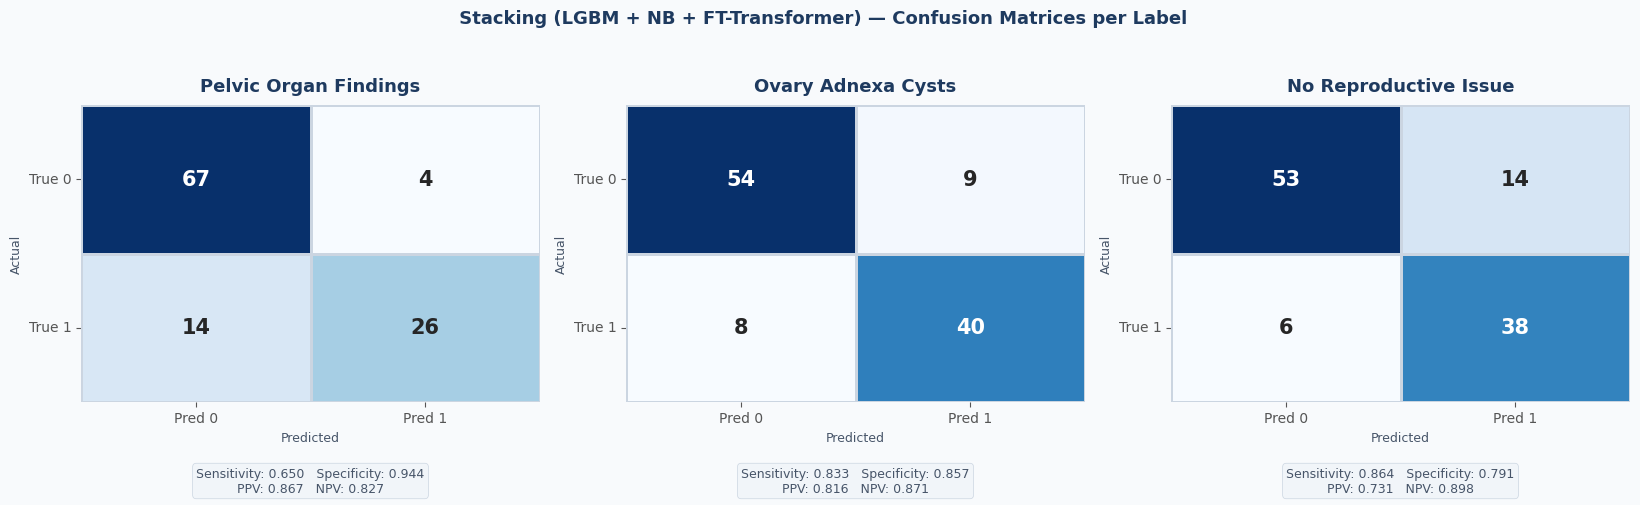


4a. Individual ROC Curves per Label:


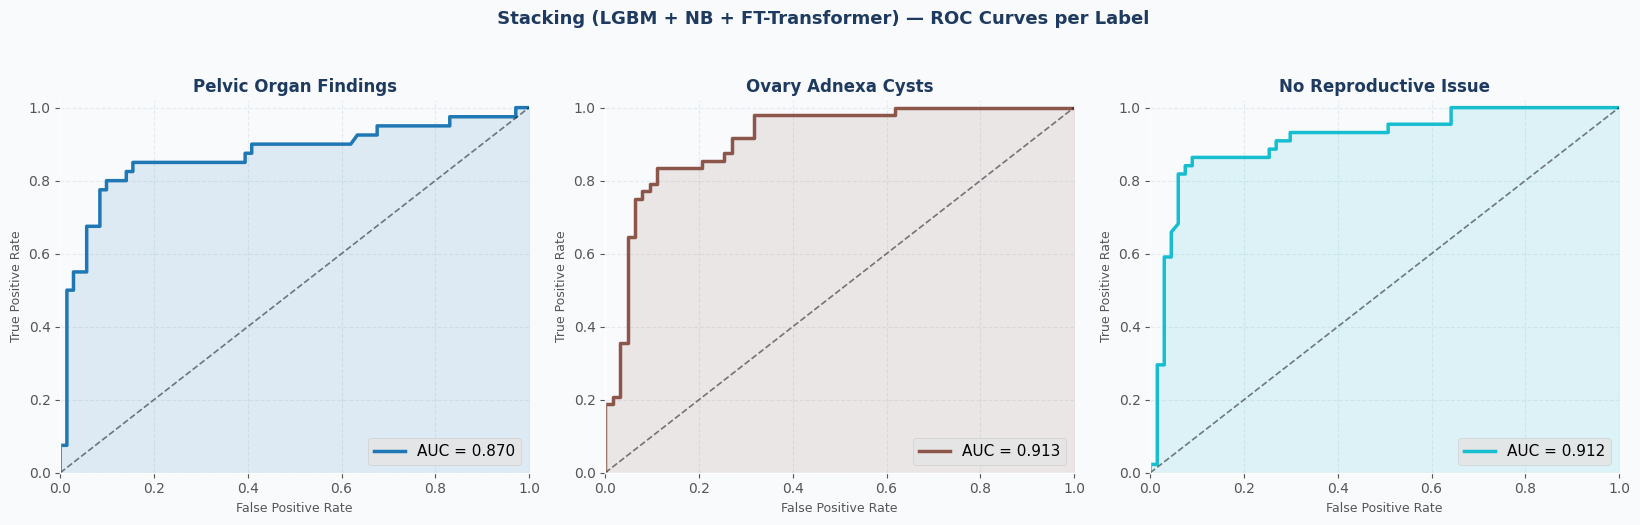


4b. Combined (Macro-Average) ROC Curve:


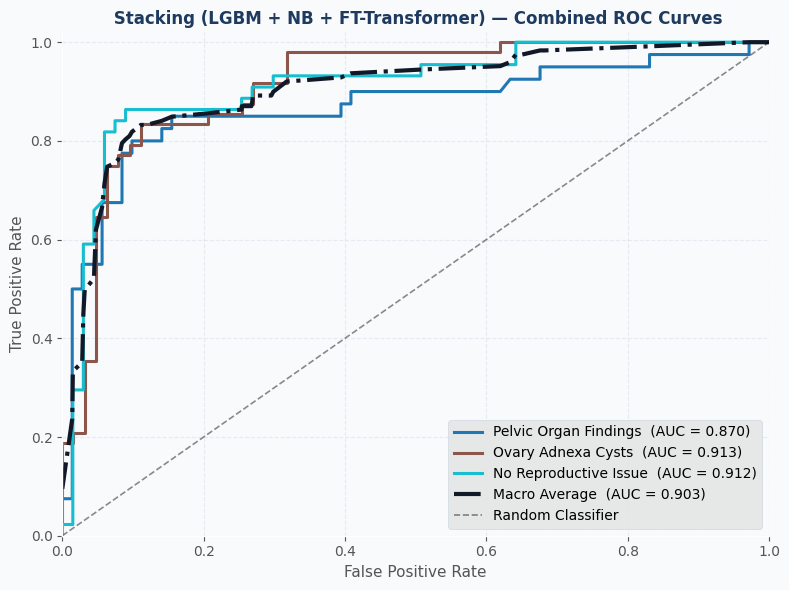

   Macro-Average AUC: 0.9034


In [ ]:
# ── Ensemble C: Stacking — LGBM (C1) + NB (C2) + FT-Transformer (C3) ──────
print('\n=== Ensemble C: Stacking (LGBM + NB + FT-Transformer) ===')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, hamming_loss

# ── Level-0 probabilities on TEST set (used for final prediction) ──────────
proba_lgbm_c = proba_c1(ce_lgbm, CE_X_test)    # Class 1
proba_nb_c   = proba_c2_nb(CE_X_test_sc)         # Class 2
proba_ft_c   = ce_proba_ft                        # Class 3

# ── Level-0 probabilities on TRAIN set via cross-val (OOF) ─────────────────
from sklearn.model_selection import StratifiedKFold
import warnings; warnings.filterwarnings('ignore')

n_train   = CE_X_train.shape[0]
n_labels  = CE_n_labels
oof_lgbm  = np.zeros((n_train, n_labels))
oof_nb    = np.zeros((n_train, n_labels))
oof_ft    = np.zeros((n_train, n_labels))

# Use label 0 for stratification (most informative)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_tr_np = CE_Y_train.values

for fold, (tr_idx, val_idx) in enumerate(skf.split(CE_X_train, y_tr_np[:, 0])):
    print(f'  OOF fold {fold+1}/5...')
    # Fold data
    Xf_tr, Xf_val   = CE_X_train.iloc[tr_idx], CE_X_train.iloc[val_idx]
    Xf_tr_sc        = ce_scaler.transform(Xf_tr)
    Xf_val_sc       = ce_scaler.transform(Xf_val)
    Yf_tr, Yf_val   = CE_Y_train.iloc[tr_idx], CE_Y_train.iloc[val_idx]

    # LGBM (Class 1)
    m_lgbm_f = MultiOutputClassifier(LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', verbose=-1))
    m_lgbm_f.fit(Xf_tr, Yf_tr)
    oof_lgbm[val_idx] = np.column_stack([p[:, 1] for p in m_lgbm_f.predict_proba(Xf_val)])

    # NB (Class 2 — scaled)
    m_nb_f = MultiOutputClassifier(GaussianNB())
    m_nb_f.fit(Xf_tr_sc, Yf_tr)
    oof_nb[val_idx] = np.column_stack([p[:, 1] for p in m_nb_f.predict_proba(Xf_val_sc)])

    # FT-Transformer (Class 3)
    Xf_arr_tr = pd.DataFrame(Xf_tr.values, columns=current_X_cols).values.copy()
    Xf_arr_val= pd.DataFrame(Xf_val.values, columns=current_X_cols).values.copy()
    for i_c, c_idx in enumerate(cat_cols_idx):
        mx = cat_dims[i_c] - 1
        Xf_arr_tr[:, c_idx]  = np.clip(np.round(Xf_arr_tr[:, c_idx]),  0, mx).astype(int)
        Xf_arr_val[:, c_idx] = np.clip(np.round(Xf_arr_val[:, c_idx]), 0, mx).astype(int)
    ft_cat_tr_f = torch.tensor(Xf_arr_tr[:, cat_cols_idx],  dtype=torch.long)
    ft_num_tr_f = torch.tensor(Xf_arr_tr[:, num_cols_idx],  dtype=torch.float32)
    ft_cat_val  = torch.tensor(Xf_arr_val[:, cat_cols_idx], dtype=torch.long)
    ft_num_val  = torch.tensor(Xf_arr_val[:, num_cols_idx], dtype=torch.float32)
    ft_y_tr_f   = torch.tensor(Yf_tr.values, dtype=torch.float32)
    ft_fold = FTTransformer(
        num_features=len(current_X_cols), num_cat=len(cat_cols_idx),
        cat_dims=cat_dims, num_num=len(num_cols_idx),
        embed_dim=64, num_heads=4, num_layers=2, dropout=0.2, out_dim=1
    ).to(device)
    opt_fold = optim.AdamW(ft_fold.parameters(), lr=1e-3, weight_decay=1e-5)
    ds_fold  = TensorDataset(ft_cat_tr_f, ft_num_tr_f, ft_y_tr_f)
    dl_fold  = DataLoader(ds_fold, batch_size=128, shuffle=True)
    for ep in range(30):
        ft_fold.train()
        for cat_b, num_b, yb in dl_fold:
            cat_b=cat_b.to(device); num_b=num_b.to(device); yb=yb.to(device)
            opt_fold.zero_grad()
            nn.BCELoss()(ft_fold(cat_b, num_b), yb).backward()
            opt_fold.step()
    ft_fold.eval()
    with torch.no_grad():
        oof_ft[val_idx] = ft_fold(ft_cat_val.to(device), ft_num_val.to(device)).cpu().numpy()

# ── Build meta-feature matrices ────────────────────────────────────────────
# Train meta: stack OOF proba from 3 models → (n_train, n_labels*3)
meta_X_train = np.hstack([oof_lgbm, oof_nb, oof_ft])        # shape (n_train, n_labels*3)
# Test meta: stack full-model probas from 3 models
meta_X_test  = np.hstack([proba_lgbm_c, proba_nb_c, proba_ft_c])  # shape (n_test, n_labels*3)

# ── Per-label LightGBM meta-learner ────────────────────────────────────────
y_pred_ensC  = np.zeros((CE_X_test.shape[0], n_labels), dtype=int)
y_proba_ensC = np.zeros((CE_X_test.shape[0], n_labels))

for li in range(n_labels):
    meta_clf = LGBMClassifier(n_estimators=100, random_state=42,
                               class_weight='balanced', verbose=-1)
    meta_clf.fit(meta_X_train, y_tr_np[:, li])
    y_proba_ensC[:, li] = meta_clf.predict_proba(meta_X_test)[:, 1]
    y_pred_ensC[:, li]  = meta_clf.predict(meta_X_test)

comprehensive_evaluation_report(
    CE_Y_test.values, y_pred_ensC, y_proba_ensC,
    CE_target_names, CE_short_names, CE_n_labels,
    model_name=' Stacking (LGBM + NB + FT-Transformer)'
)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 1 — Collect metrics from all models already trained above
#          (re-evaluate each on the SAME test split)
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score, f1_score, hamming_loss

# ── Helper ──────────────────────────────────────────────────────────────
def get_per_label_error(y_true, y_pred):
    """Return per-label error rates (1 - accuracy per label)."""
    n_labels = y_true.shape[1]
    return [1.0 - accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(n_labels)]

# ── Model registry  ────────────────────────────────────────────────────
# Each entry: (name, class_id, y_pred, y_true)
# We reuse predictions already computed earlier in the notebook.

# --- Class 1 — Tree/Boosting (use X_test / Y_test) ---
y_true_c1 = Y_test.values

# RF
y_pred_rf_cmp   = rf.predict(X_test)
# XGB
y_pred_xgb_cmp  = xgb.predict(X_test)
# LGBM
y_pred_lgbm_cmp = lgbm_model.predict(X_test)

# --- Class 2 — Probabilistic/Distance (use X_test_scaled / Y_test) ---
y_true_c2 = Y_test.values

# SVM
y_pred_svm_cmp   = svm_model.predict(X_test_scaled_svm)
# MLKNN
y_pred_mlknn_cmp = mlknn.predict(X_test_scaled_mlknn)
# NB  — trained in cell 53 using X_train / y_train (unscaled)
y_pred_nb_cmp    = nb.predict(X_test)

# --- Class 3 — Deep Learning (use X_test_scaled / Y_test) ---
y_true_c3 = Y_test.values

# MLP
mlp_model.eval()
import torch
with torch.no_grad():
    _logits = mlp_model(torch.tensor(X_test_scaled_mlp, dtype=torch.float32).to(device))
    y_pred_mlp_cmp = (torch.sigmoid(_logits).cpu().numpy() > 0.5).astype(int)

# TabNet
y_pred_tabnet_cmp = y_pred_tabnet   # from cell 58

# FT-Transformer
y_pred_ft_cmp = y_pred_ft           # from cell 59

# --- Class 4 — Ensembles (each used their own split but same random_state=42) ---
# Soft Voting (RF+XGB+LGBM)
y_true_ens1   = Y_te1.values
# Stacking RF+SVM->LGBM
y_true_ens2   = Y_te2.values
# Stacking-C (LGBM+NB+FT)
y_true_ensC   = CE_Y_test.values

# ── Build comparison table ──────────────────────────────────────────────
records = [
    # Class 1
    ('RF',            1, y_true_c1, y_pred_rf_cmp),
    ('XGBoost',       1, y_true_c1, y_pred_xgb_cmp),
    ('LightGBM',      1, y_true_c1, y_pred_lgbm_cmp),
    # Class 2
    ('SVM',           2, y_true_c2, y_pred_svm_cmp),
    ('MLKNN',         2, y_true_c2, y_pred_mlknn_cmp),
    ('Naive Bayes',   2, y_true_c2, y_pred_nb_cmp),
    # Class 3
    ('MLP',           3, y_true_c3, y_pred_mlp_cmp),
    ('TabNet',        3, y_true_c3, y_pred_tabnet_cmp),
    ('FT-Transformer',3, y_true_c3, y_pred_ft_cmp),
    # Class 4

    ('Soft Voting\n(RF+XGB+LGBM)',           4, y_true_ens1,  y_pred_ens1),
    ('Stacking\n(LGBM+NB+FT)',              4, y_true_ensC,  y_pred_ensC),
    ('UHStack-ML',               4, y_true_ens2,  y_pred_ens2)
]

model_names, classes, subset_accs, macro_f1s, error_rates = [], [], [], [], []

for name, cls, yt, yp in records:
    model_names.append(name)
    classes.append(cls)
    subset_accs.append(accuracy_score(yt, yp))
    macro_f1s.append(f1_score(yt, yp, average='macro', zero_division=0))
    error_rates.append(get_per_label_error(yt, yp))

cmp_df = pd.DataFrame({
    'Model':        model_names,
    'Class':        classes,
    'Subset Acc':   subset_accs,
    'Macro F1':     macro_f1s,
})

print(cmp_df.to_string(index=False))


                     Model  Class  Subset Acc  Macro F1
                        RF      1    0.765766  0.829975
                   XGBoost      1    0.738739  0.820935
                  LightGBM      1    0.720721  0.804361
                       SVM      2    0.594595  0.728540
                     MLKNN      2    0.459459  0.499690
               Naive Bayes      2    0.315315  0.530624
                       MLP      3    0.675676  0.794931
                    TabNet      3    0.531532  0.674462
            FT-Transformer      3    0.558559  0.663486
Soft Voting\n(RF+XGB+LGBM)      4    0.756757  0.825102
    Stacking\n(LGBM+NB+FT)      4    0.711712  0.786422
                UHStack-ML      4    0.792793  0.872618


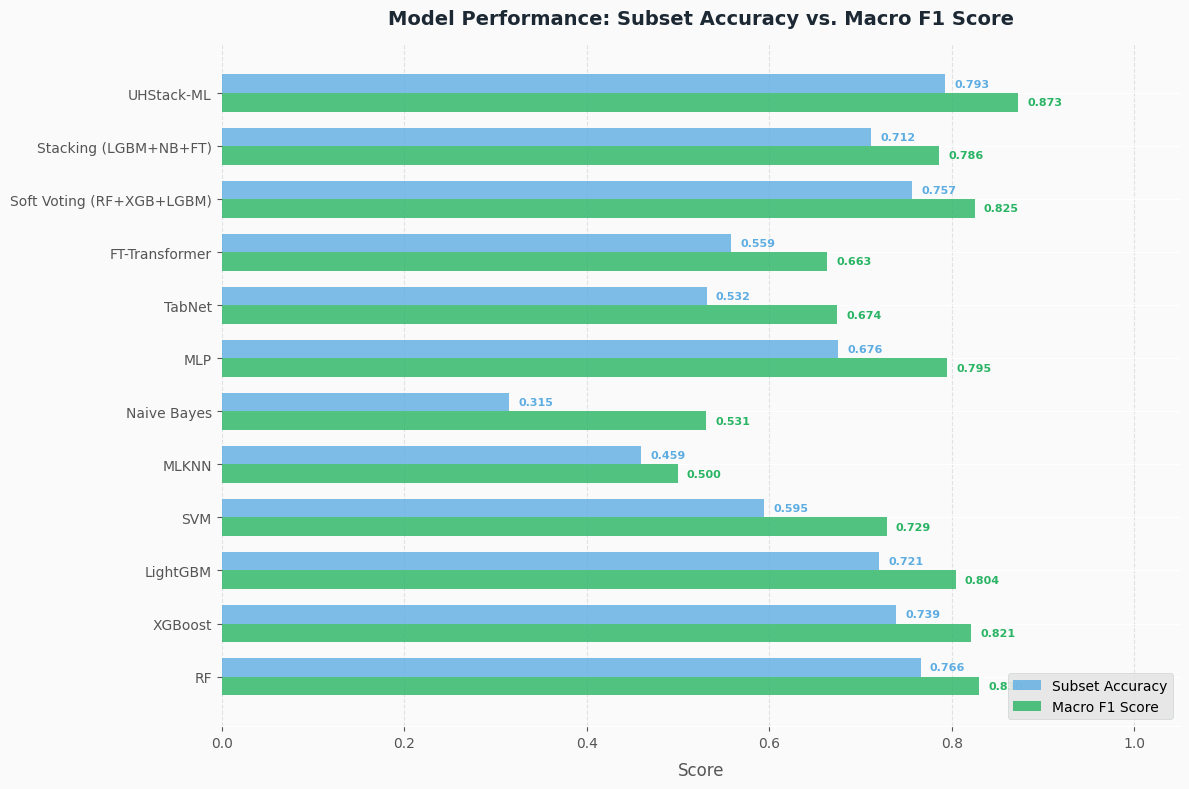

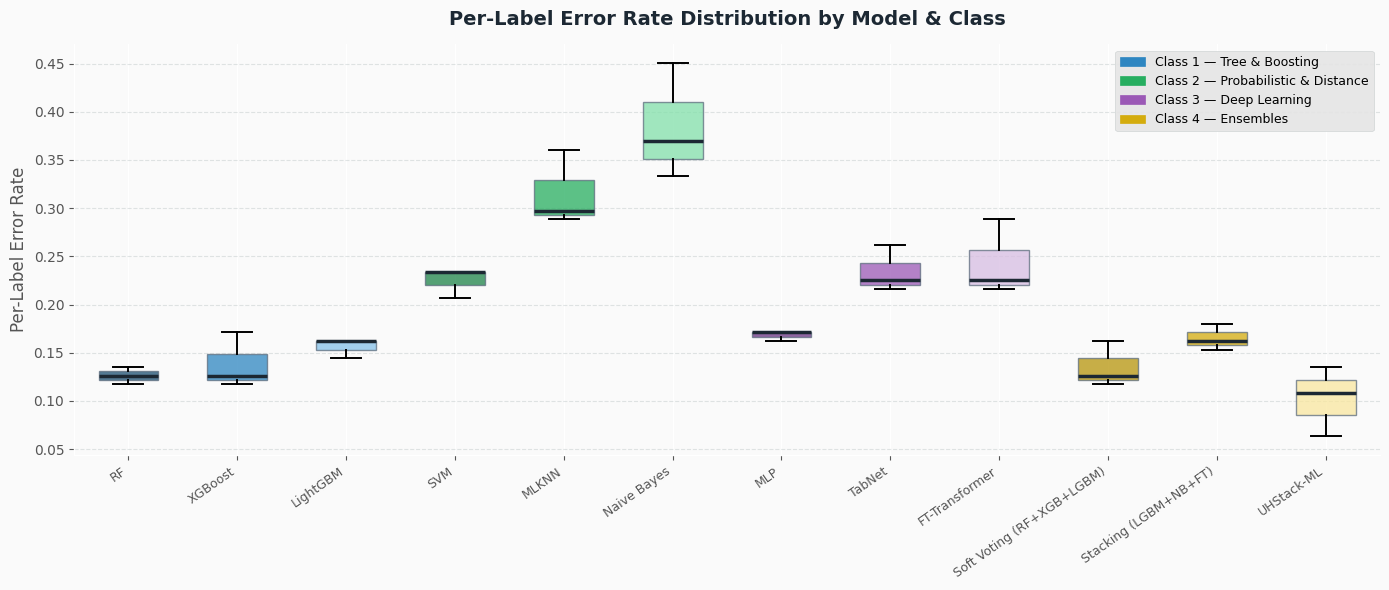

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 2 — Combined Plot (Subset Accuracy & Macro F1) + Box Plot
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colour palettes per class ───────────────────────────
PALETTES = {
    1: ['#1B4F72', '#2E86C1', '#85C1E9'],          # Blues  — Class 1
    2: ['#1E8449', '#27AE60', '#82E0AA'],          # Greens — Class 2
    3: ['#6C3483', '#9B59B6', '#D7BDE2'],          # Purples — Class 3
    4: ['#B7950B', '#D4AC0D', '#F9E79F'],          # Golds  — Class 4
}

# Build per-model colour list
class_model_counter = {1:0, 2:0, 3:0, 4:0}
bar_colors_main = []
for cls in cmp_df['Class']:
    idx = class_model_counter[cls]
    bar_colors_main.append(PALETTES[cls][idx % len(PALETTES[cls])])
    class_model_counter[cls] += 1

N = len(cmp_df)
y_pos = np.arange(N)
labels = [n.replace('\n', ' ') for n in cmp_df['Model']]

legend_patches = [
    mpatches.Patch(color=PALETTES[1][1], label='Class 1 — Tree & Boosting'),
    mpatches.Patch(color=PALETTES[2][1], label='Class 2 — Probabilistic & Distance'),
    mpatches.Patch(color=PALETTES[3][1], label='Class 3 — Deep Learning'),
    mpatches.Patch(color=PALETTES[4][1], label='Class 4 — Ensembles'),
]

# ──────────────────────────────────────
# FIG 1: Combined Grouped Bar Chart — Subset Accuracy & Macro F1
# ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 8), facecolor='#FAFAFA')
ax1.set_facecolor('#FAFAFA')

bar_width = 0.35
index = np.arange(N)

# Plotting Subset Accuracy
rects1 = ax1.barh(index + bar_width/2, cmp_df['Subset Acc'], bar_width, label='Subset Accuracy', color='#5DADE2', alpha=0.8)
# Plotting Macro F1
rects2 = ax1.barh(index - bar_width/2, cmp_df['Macro F1'], bar_width, label='Macro F1 Score', color='#28B463', alpha=0.8)

ax1.set_yticks(index)
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('Score', fontsize=12, labelpad=8)
ax1.set_title('Model Performance: Subset Accuracy vs. Macro F1 Score', fontsize=14, fontweight='bold', color='#1C2833', pad=14)
ax1.set_xlim(0, 1.05)
ax1.grid(axis='x', linestyle='--', alpha=0.35, color='#AAB7B8')
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9, edgecolor='#CCD1D1')

for i, rect in enumerate(rects1):
    ax1.text(rect.get_width() + 0.01, rect.get_y() + rect.get_height()/2, f'{cmp_df["Subset Acc"].iloc[i]:.3f}', ha='left', va='center', fontsize=8, color='#5DADE2', fontweight='bold')
for i, rect in enumerate(rects2):
    ax1.text(rect.get_width() + 0.01, rect.get_y() + rect.get_height()/2, f'{cmp_df["Macro F1"].iloc[i]:.3f}', ha='left', va='center', fontsize=8, color='#28B463', fontweight='bold')

for sp in ['top','right','left']:
    ax1.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('combined_subset_acc_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()


# ──────────────────────────────────────
# FIG 2: Box Plot — Per-Label Error Rate
# ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6), facecolor='#FAFAFA')
ax2.set_facecolor('#FAFAFA')

bp = ax2.boxplot(
    error_rates,
    vert=True,
    patch_artist=True,
    notch=False,
    widths=0.55,
    medianprops=dict(color='#1C2833', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=5, alpha=0.6)
)

for patch, c in zip(bp['boxes'], bar_colors_main):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
    patch.set_edgecolor('#5D6D7E')

# Colour fliers to match box
flier_idx = 0
for flier, c in zip(bp['fliers'], bar_colors_main):
    flier.set_markerfacecolor(c)
    flier.set_markeredgecolor(c)

ax2.set_xticks(range(1, N+1))
ax2.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Per-Label Error Rate', fontsize=12)
ax2.set_title('Per-Label Error Rate Distribution by Model & Class',
              fontsize=14, fontweight='bold', color='#1C2833', pad=14)
ax2.grid(axis='y', linestyle='--', alpha=0.35, color='#AAB7B8')
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
ax2.legend(handles=legend_patches, loc='upper right', fontsize=9,
           framealpha=0.9, edgecolor='#CCD1D1')
plt.tight_layout()
plt.savefig('boxplot_error_rate.png', dpi=150, bbox_inches='tight')
plt.show()

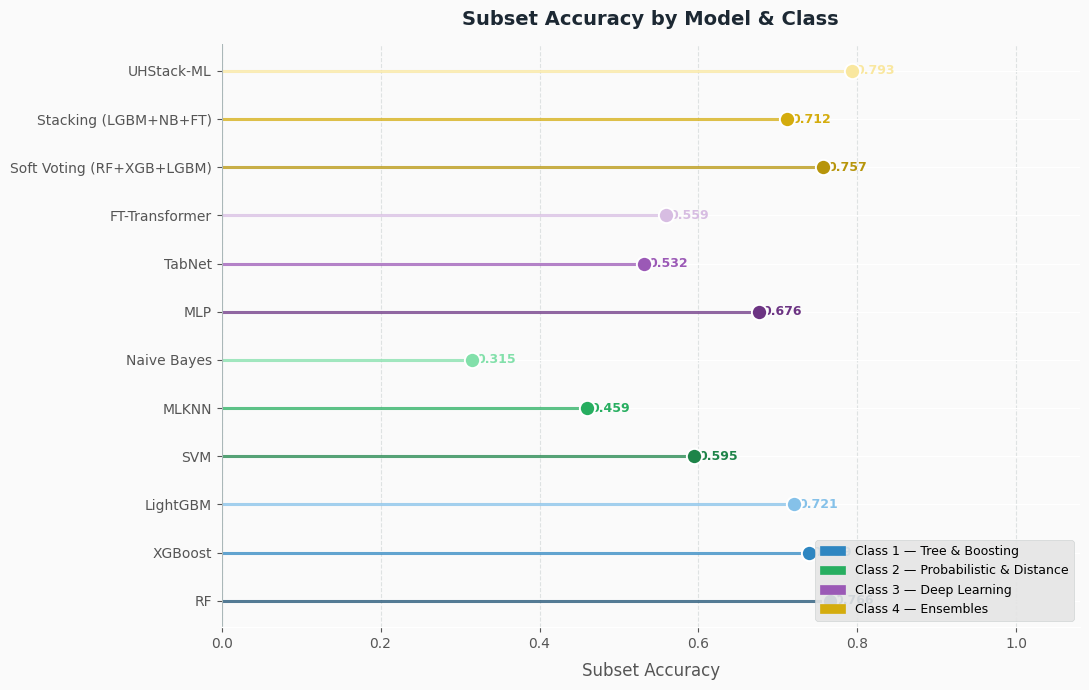

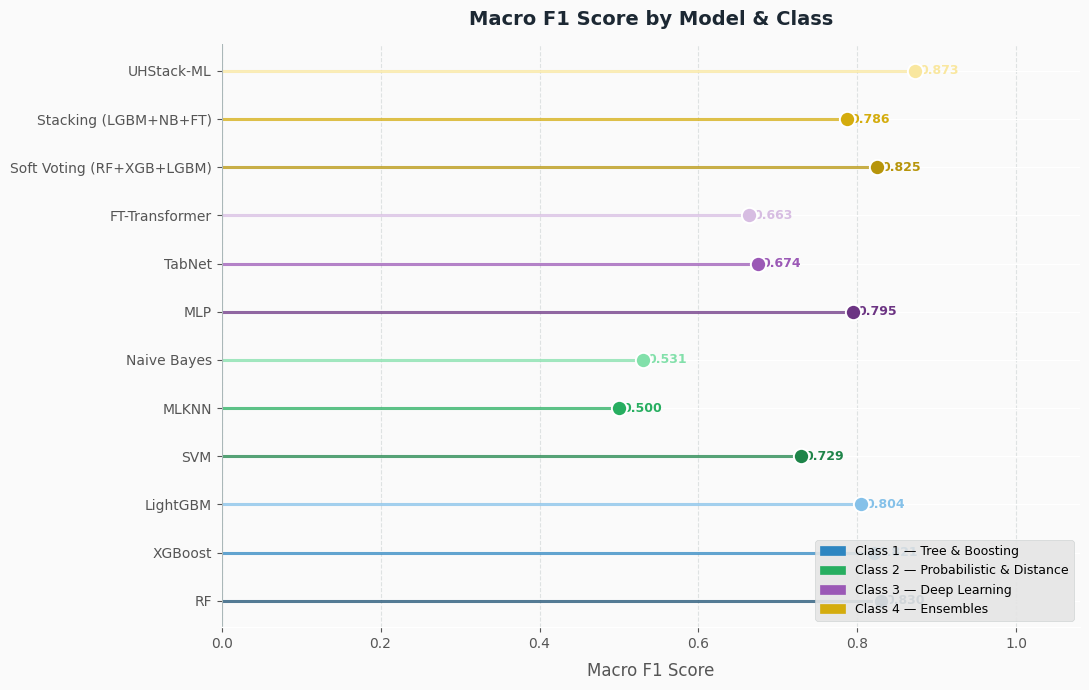

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 2 — Lollipop Charts (Subset Accuracy & Macro F1) + Box Plot
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colour palettes per class ───────────────────────────────────────────
PALETTES = {
    1: ['#1B4F72', '#2E86C1', '#85C1E9'],          # Blues  — Class 1
    2: ['#1E8449', '#27AE60', '#82E0AA'],          # Greens — Class 2
    3: ['#6C3483', '#9B59B6', '#D7BDE2'],          # Purples — Class 3
    4: ['#B7950B', '#D4AC0D', '#F9E79F'],          # Golds  — Class 4
}

# Build per-model colour list
class_model_counter = {1:0, 2:0, 3:0, 4:0}
bar_colors = []
for cls in cmp_df['Class']:
    idx = class_model_counter[cls]
    bar_colors.append(PALETTES[cls][idx % len(PALETTES[cls])])
    class_model_counter[cls] += 1

N = len(cmp_df)
y_pos = np.arange(N)
labels = [n.replace('\n', ' ') for n in cmp_df['Model']]

legend_patches = [
    mpatches.Patch(color=PALETTES[1][1], label='Class 1 — Tree & Boosting'),
    mpatches.Patch(color=PALETTES[2][1], label='Class 2 — Probabilistic & Distance'),
    mpatches.Patch(color=PALETTES[3][1], label='Class 3 — Deep Learning'),
    mpatches.Patch(color=PALETTES[4][1], label='Class 4 — Ensembles'),
]

# ─────────────────────────────────────────────
# FIG 1: Lollipop — Subset Accuracy
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 7), facecolor='#FAFAFA')
ax1.set_facecolor('#FAFAFA')

vals = cmp_df['Subset Acc'].values
for i, (v, c) in enumerate(zip(vals, bar_colors)):
    ax1.hlines(y=i, xmin=0, xmax=v, color=c, linewidth=2.2, alpha=0.75)
    ax1.plot(v, i, 'o', color=c, markersize=11, zorder=5,
             markeredgecolor='white', markeredgewidth=1.4)
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center', ha='left',
             fontsize=9, color=c, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('Subset Accuracy', fontsize=12, labelpad=8)
ax1.set_title('Subset Accuracy by Model & Class', fontsize=14,
              fontweight='bold', color='#1C2833', pad=14)
ax1.set_xlim(0, 1.08)
ax1.axvline(x=0, color='#AAB7B8', linewidth=0.8)
ax1.grid(axis='x', linestyle='--', alpha=0.35, color='#AAB7B8')
for sp in ['top','right','left']:
    ax1.spines[sp].set_visible(False)
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9,
           framealpha=0.9, edgecolor='#CCD1D1')
plt.tight_layout()
plt.savefig('lollipop_subset_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# FIG 2: Lollipop — Macro F1
# ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor='#FAFAFA')
ax2.set_facecolor('#FAFAFA')

vals2 = cmp_df['Macro F1'].values
for i, (v, c) in enumerate(zip(vals2, bar_colors)):
    ax2.hlines(y=i, xmin=0, xmax=v, color=c, linewidth=2.2, alpha=0.75)
    ax2.plot(v, i, 'o', color=c, markersize=11, zorder=5,
             markeredgecolor='white', markeredgewidth=1.4)
    ax2.text(v + 0.005, i, f'{v:.3f}', va='center', ha='left',
             fontsize=9, color=c, fontweight='bold')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=10)
ax2.set_xlabel('Macro F1 Score', fontsize=12, labelpad=8)
ax2.set_title('Macro F1 Score by Model & Class', fontsize=14,
              fontweight='bold', color='#1C2833', pad=14)
ax2.set_xlim(0, 1.08)
ax2.axvline(x=0, color='#AAB7B8', linewidth=0.8)
ax2.grid(axis='x', linestyle='--', alpha=0.35, color='#AAB7B8')
for sp in ['top','right','left']:
    ax2.spines[sp].set_visible(False)
ax2.legend(handles=legend_patches, loc='lower right', fontsize=9,
           framealpha=0.9, edgecolor='#CCD1D1')
plt.tight_layout()
plt.savefig('lollipop_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Install XAI libraries if not already present ────────────────────────
import subprocess, sys
for pkg in ['shap', 'lime']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SHAP — Global & Local Explanations for Stacking (RF+SVM→LGBM)
# Strategy: explain the per-label LightGBM meta-learner using TreeExplainer
# The meta-learner inputs are [OOF_RF_proba | OOF_SVM_proba | original_features]
# We explain on the TEST meta-features (same matrix used for final predictions)
# ═══════════════════════════════════════════════════════════════════════
import shap
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# ── Rebuild meta-feature names ──────────────────────────────────────────
# The stacking meta-learner receives:
#   [rf_proba_label_0..k, svm_proba_label_0..k, original_features]
# We used passthrough=True in StackingClassifier, so original features come after

# Recover feature names from the training data
orig_feat_names = list(X_resampled.columns)

# The MultiOutputClassifier wraps one StackingClassifier per label.
# Each stacking estimator's final_estimator_ is the trained LightGBM meta-learner.
# Access it via: ensemble2.estimators_[label_idx].final_estimator_

# Build meta-test features: RF-proba | SVM-proba | original X_te2
# (Same construction used inside StackingClassifier.predict_proba)

# Get RF & SVM proba on X_te2
_rf_lvl0  = ensemble2.estimators_[0].transform(X_te2)   # (n_test, 2*n_levels)
# For a single label, transform() gives the stacked meta-features + passthrough
# We can use predict on the meta-learner directly if we reconstruct the meta-feats.
# Simpler: use TreeExplainer on the LightGBM meta-learner from label 0 for demo.

# For clarity we explain label-by-label
xai_target_names = CE_target_names  # use CE split names

# ── Per-label SHAP (Global) ─────────────────────────────────────────────
print('Computing SHAP values for each label meta-learner...')

shap_values_all   = []   # list of shap value arrays, one per label
meta_test_all     = []   # list of meta-feature matrices, one per label
meta_feat_names_all = []

for li, label_name in enumerate(CE_target_names):
    # Each estimator in MultiOutputClassifier is a StackingClassifier
    stk  = ensemble2.estimators_[li]
    # transform() returns the meta-feature matrix for the test set
    meta_te = stk.transform(X_te2)   # shape (n_test, n_meta_features)
    meta_test_all.append(meta_te)

    # Meta-feature names: RF_p0, RF_p1, SVM_p0, SVM_p1, then original features
    n_stack_feats = meta_te.shape[1] - len(orig_feat_names)  if stk.passthrough else meta_te.shape[1]
    stack_names   = [f'RF_p{j}' for j in range(n_stack_feats//2)] + \
                    [f'SVM_p{j}' for j in range(n_stack_feats//2)]
    if stk.passthrough:
        feat_names_li = stack_names + orig_feat_names[:meta_te.shape[1]-len(stack_names)]
    else:
        feat_names_li = stack_names
    # Trim/pad to actual width
    feat_names_li = (feat_names_li + [f'feat_{k}' for k in range(meta_te.shape[1])])[:meta_te.shape[1]]
    meta_feat_names_all.append(feat_names_li)

    # TreeExplainer on LightGBM meta-learner
    explainer_li = shap.TreeExplainer(stk.final_estimator_)
    sv_li        = explainer_li.shap_values(meta_te)   # (n_test, n_feats) or list
    if isinstance(sv_li, list):
        sv_li = sv_li[1]   # class-1 SHAP values
    shap_values_all.append(sv_li)
    print(f'  Label {li} ({label_name}): SHAP computed. Shape={sv_li.shape}')

print('SHAP computation complete.')


Computing SHAP values for each label meta-learner...
  Label 0 (group_pelvic_organ_findings): SHAP computed. Shape=(111, 27)
  Label 1 (group_ovary_adnexa_cysts): SHAP computed. Shape=(111, 27)
  Label 2 (group_no_reproductive_issue): SHAP computed. Shape=(111, 27)
SHAP computation complete.



--- SHAP Global Summary: Pelvic Organ Findings ---


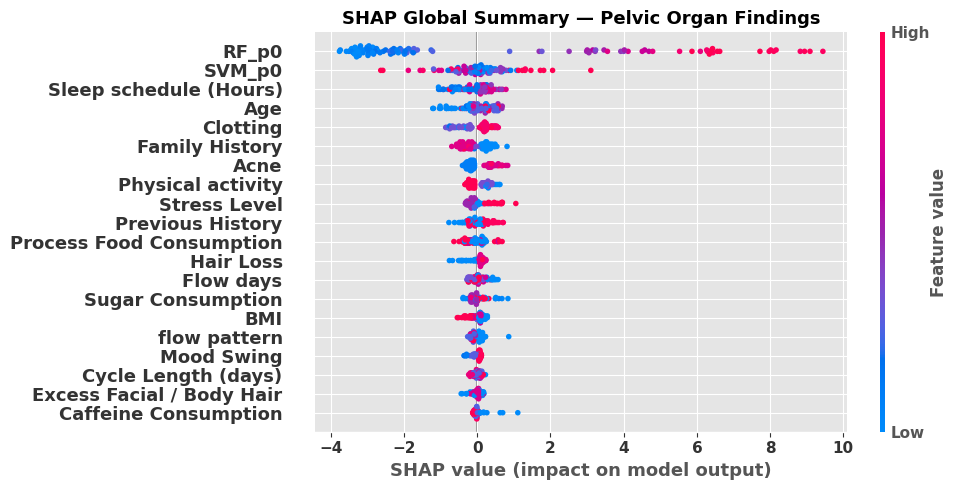


--- SHAP Global Summary: Ovary Adnexa Cysts ---


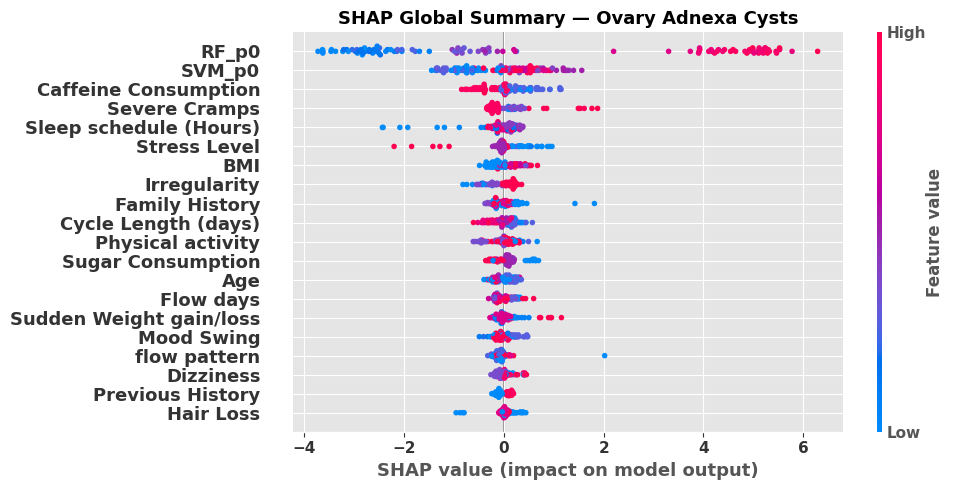


--- SHAP Global Summary: No Reproductive Issue ---


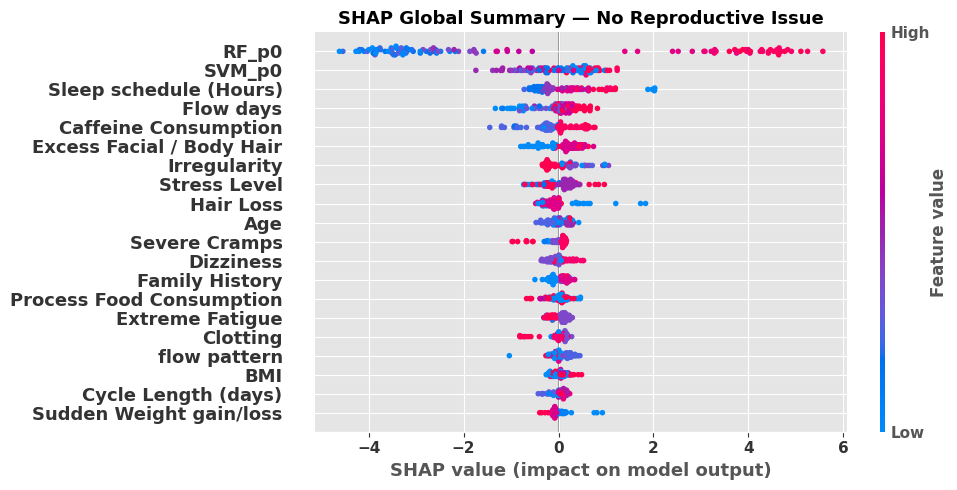

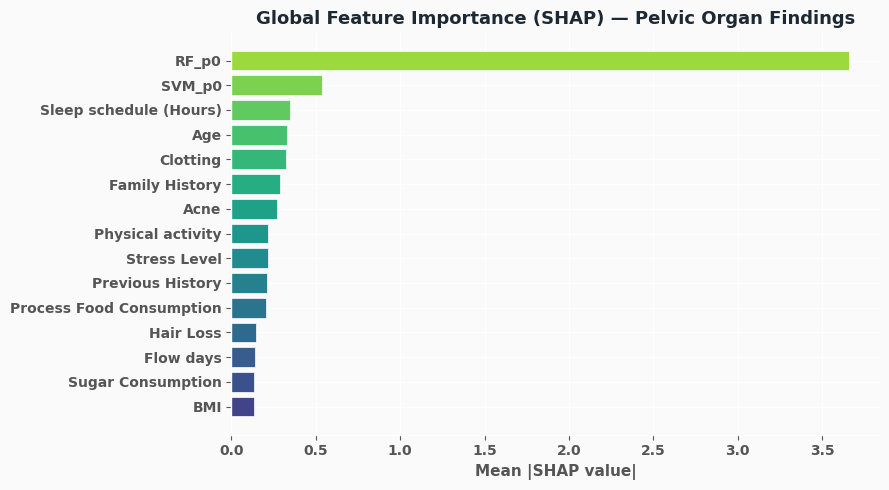

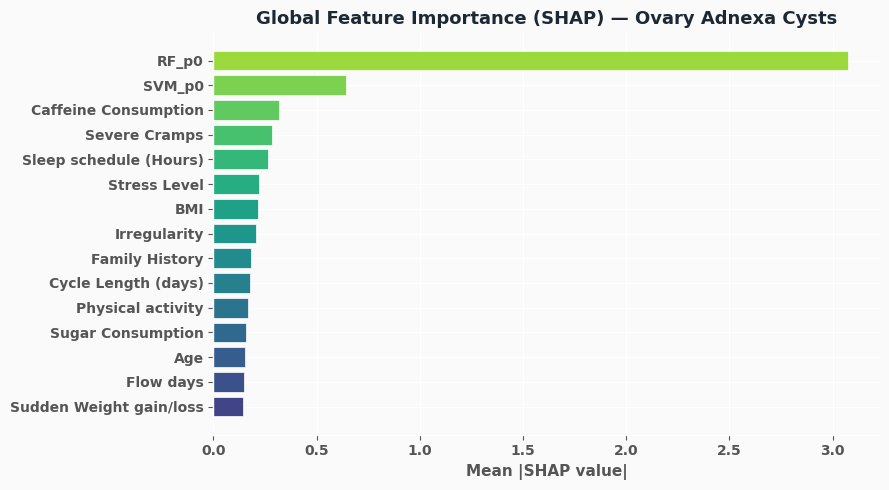

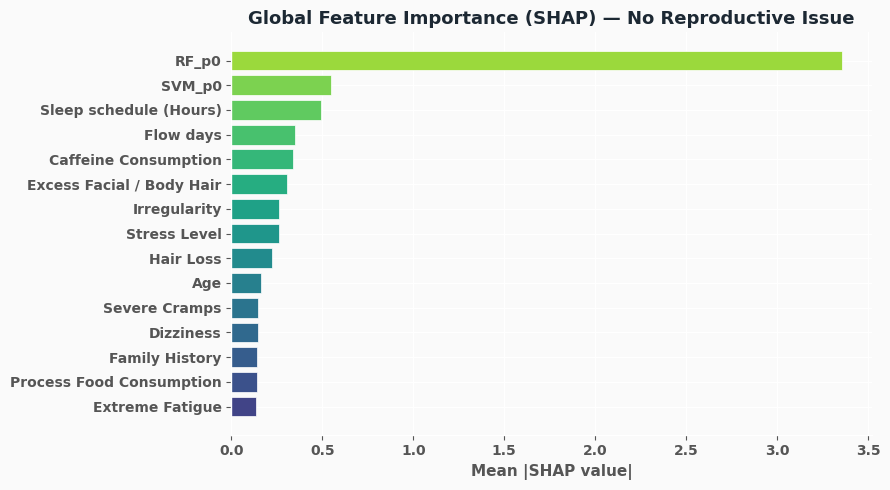

In [ ]:
# ── SHAP Global: Summary (Beeswarm) per label ───────────────────
import shap, matplotlib.pyplot as plt

for li, label_name in enumerate(CE_target_names):
    short = label_name.replace('group_','').replace('_',' ').title()
    print(f'\n--- SHAP Global Summary: {short} ---')
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.summary_plot(
        shap_values_all[li],
        meta_test_all[li],
        feature_names=meta_feat_names_all[li],
        show=False,
        plot_size=None
    )
    plt.title(f'SHAP Global Summary — {short}', fontsize=13, fontweight='bold')
    # Make all text bold in beeswarm plot
    for text in fig.findobj(plt.Text):
        text.set_fontweight('bold')
    plt.tight_layout()
    plt.savefig(f'shap_global_label{li}.png', dpi=130, bbox_inches='tight')
    plt.show()

# ── SHAP Global: Bar chart (mean |SHAP|) per label ────────────
for li, label_name in enumerate(CE_target_names):
    short = label_name.replace('group_','').replace('_',' ').title()
    mean_abs = np.abs(shap_values_all[li]).mean(axis=0)
    feat_names = meta_feat_names_all[li]
    order = np.argsort(mean_abs)[::-1][:15]   # top-15

    fig, ax = plt.subplots(figsize=(9, 5), facecolor='#FAFAFA')
    ax.set_facecolor('#FAFAFA')
    colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(order)))
    ax.barh([feat_names[i] for i in order[::-1]],
            mean_abs[order[::-1]], color=colors, edgecolor='white')
    ax.set_xlabel('Mean |SHAP value|', fontsize=11, fontweight='bold')
    ax.set_title(f'Global Feature Importance (SHAP) — {short}',
                 fontsize=13, fontweight='bold', color='#1C2833')
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)

    # Make y-tick labels bold (feature names)
    ax.set_yticklabels([feat_names[i] for i in order[::-1]], fontweight='bold', fontsize=10)
    # Make x-tick labels bold
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f'shap_bar_label{li}.png', dpi=130, bbox_inches='tight')
    plt.show()



--- SHAP Local Waterfall: Pelvic Organ Findings — Instance 0 ---


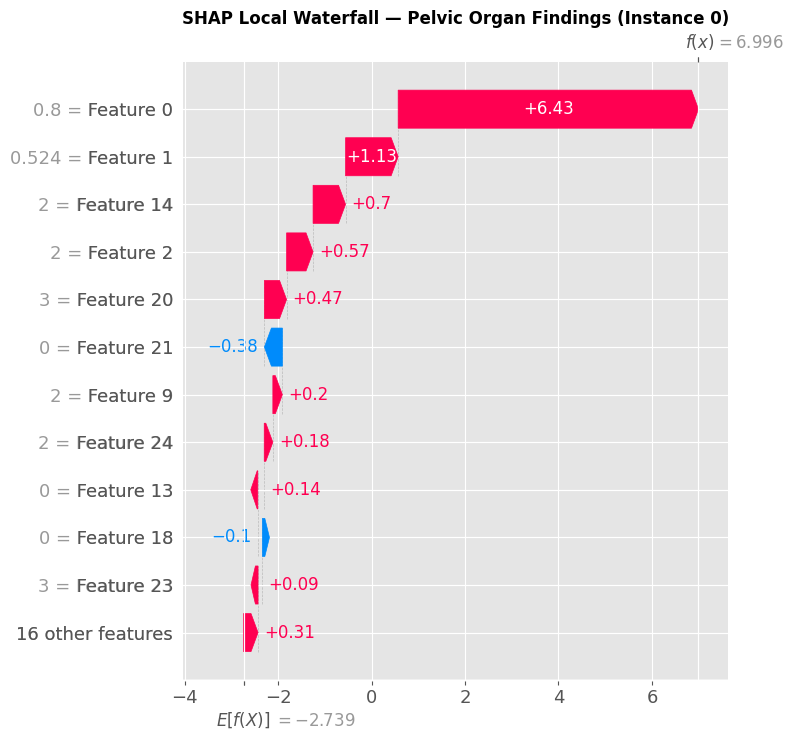


--- SHAP Local Waterfall: Ovary Adnexa Cysts — Instance 0 ---


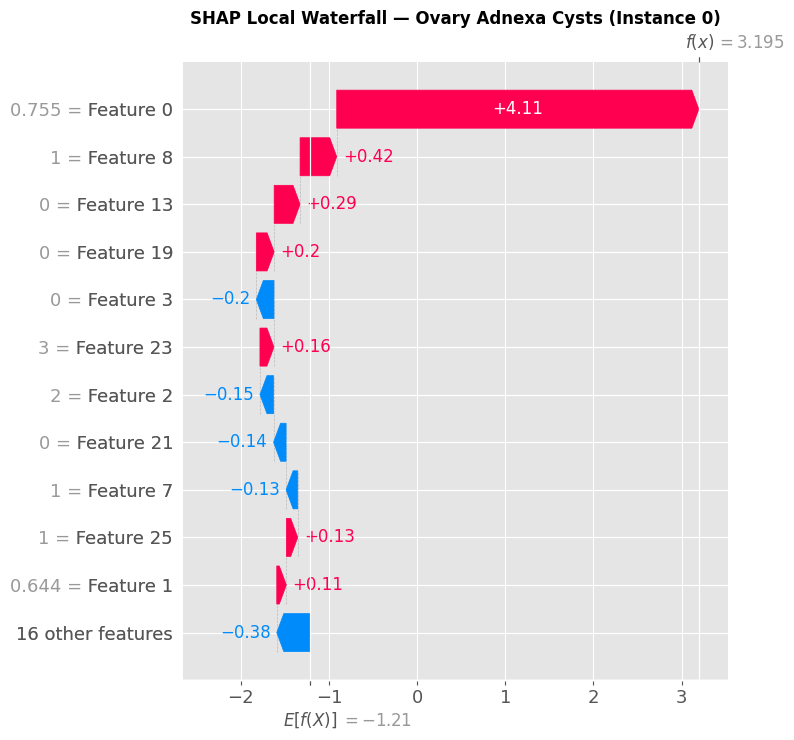


--- SHAP Local Waterfall: No Reproductive Issue — Instance 0 ---


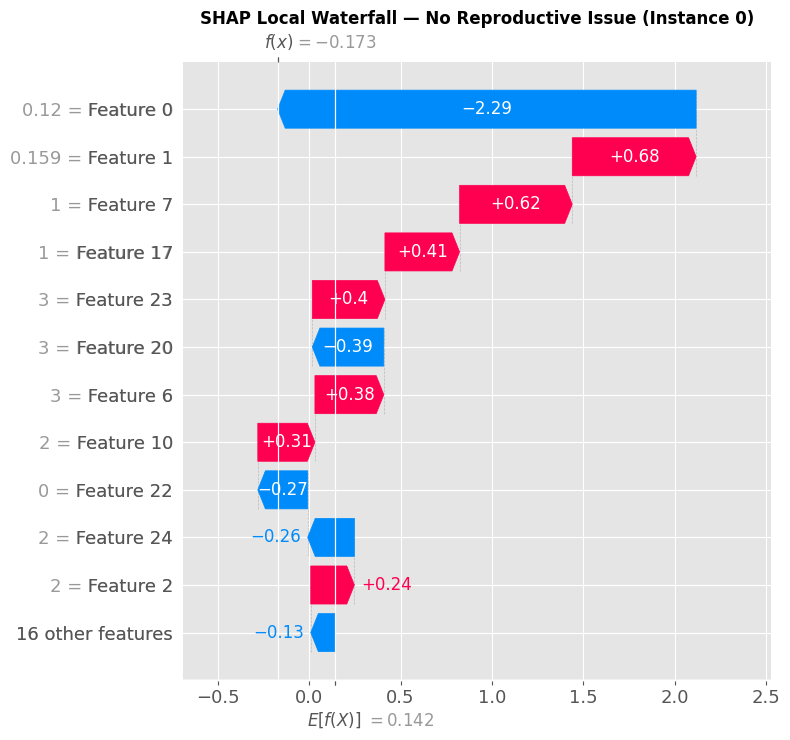

In [ ]:
# ── SHAP Local: Waterfall plot for a single instance ────────────────────
import shap, matplotlib.pyplot as plt

# Pick the first test sample as the local example
INSTANCE_IDX = 0

for li, label_name in enumerate(CE_target_names):
    short = label_name.replace('group_','').replace('_',' ').title()
    stk   = ensemble2.estimators_[li]
    meta_te = meta_test_all[li]

    explainer_li = shap.TreeExplainer(stk.final_estimator_)
    exp_obj = explainer_li(meta_te)   # Explanation object

    print(f'\n--- SHAP Local Waterfall: {short} — Instance {INSTANCE_IDX} ---')
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.plots.waterfall(exp_obj[INSTANCE_IDX], max_display=12, show=False)
    plt.title(f'SHAP Local Waterfall — {short} (Instance {INSTANCE_IDX})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_local_waterfall_label{li}.png', dpi=130, bbox_inches='tight')
    plt.show()



--- LIME Local Explanation: Pelvic Organ Findings — Instance 0 ---


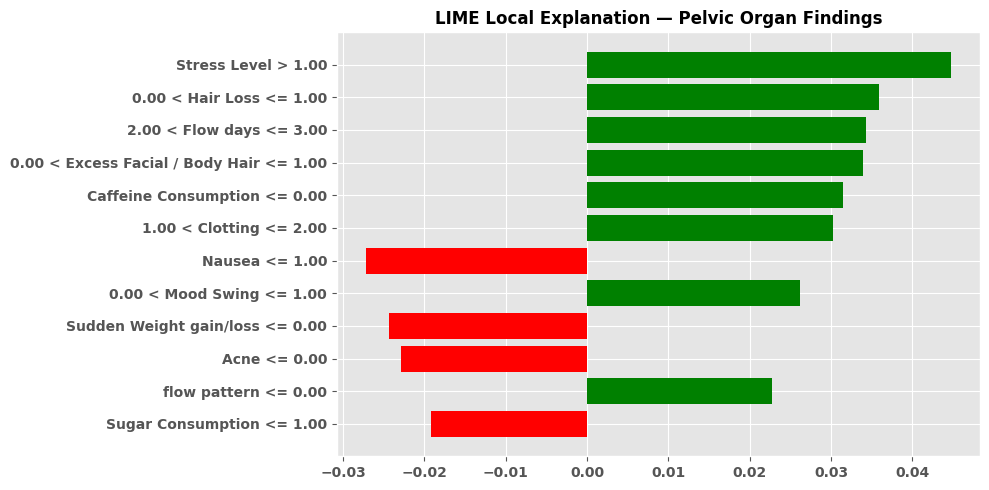


--- LIME Local Explanation: Ovary Adnexa Cysts — Instance 0 ---


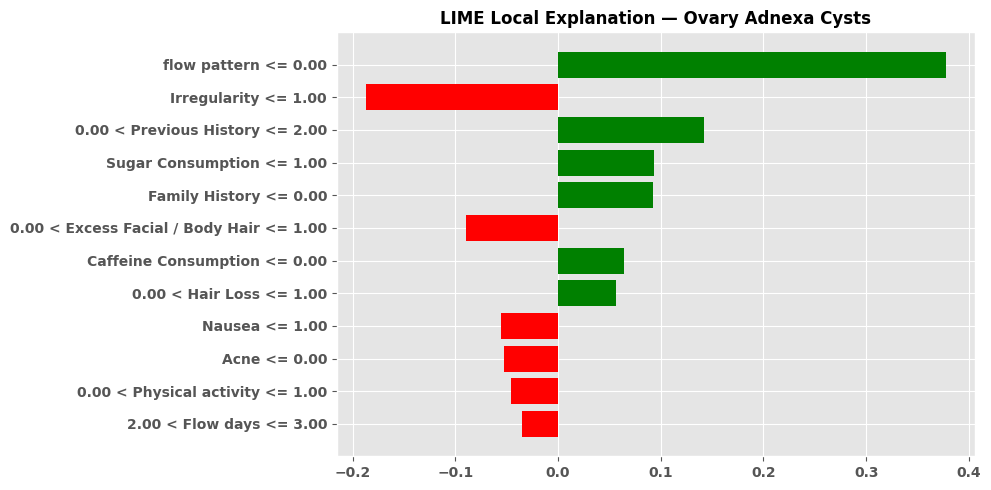


--- LIME Local Explanation: No Reproductive Issue — Instance 0 ---


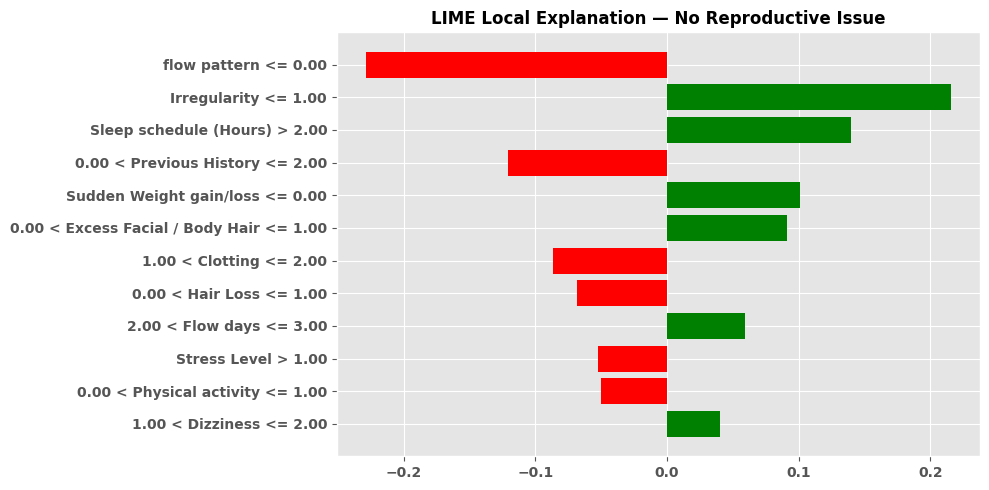

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# LIME — Per-label local explanation for one test instance
# We wrap each per-label StackingClassifier.predict_proba as a callable
# ═══════════════════════════════════════════════════════════════════════
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

LIME_INSTANCE_IDX = 0
X_te2_np = X_te2.values if hasattr(X_te2, 'values') else X_te2
X_tr2_np = X_tr2.values if hasattr(X_tr2, 'values') else X_tr2

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_tr2_np.astype(float),
    feature_names  = orig_feat_names,
    class_names    = ['Neg', 'Pos'],
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = 42
)

for li, label_name in enumerate(CE_target_names):
    short = label_name.replace('group_','').replace('_',' ').title()

    # Predict function: accepts raw X (n, features) → (n, 2) probabilities
    stk = ensemble2.estimators_[li]
    def predict_fn(X, _stk=stk):
        return _stk.predict_proba(X)

    instance = X_te2_np[LIME_INSTANCE_IDX].astype(float)
    exp = lime_explainer.explain_instance(
        data_row      = instance,
        predict_fn    = predict_fn,
        num_features  = 12,
        num_samples   = 500,
        labels        = (1,)
    )

    print(f'\n--- LIME Local Explanation: {short} — Instance {LIME_INSTANCE_IDX} ---')
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(10, 5)
    plt.title(f'LIME Local Explanation — {short}', fontsize=12, fontweight='bold')

    # Make all text bold
    for text in fig.findobj(plt.Text):
        text.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f'lime_label{li}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


Baseline Macro-F1: 0.8726
  Feature 5/25 done...
  Feature 10/25 done...
  Feature 15/25 done...
  Feature 20/25 done...
  Feature 25/25 done...


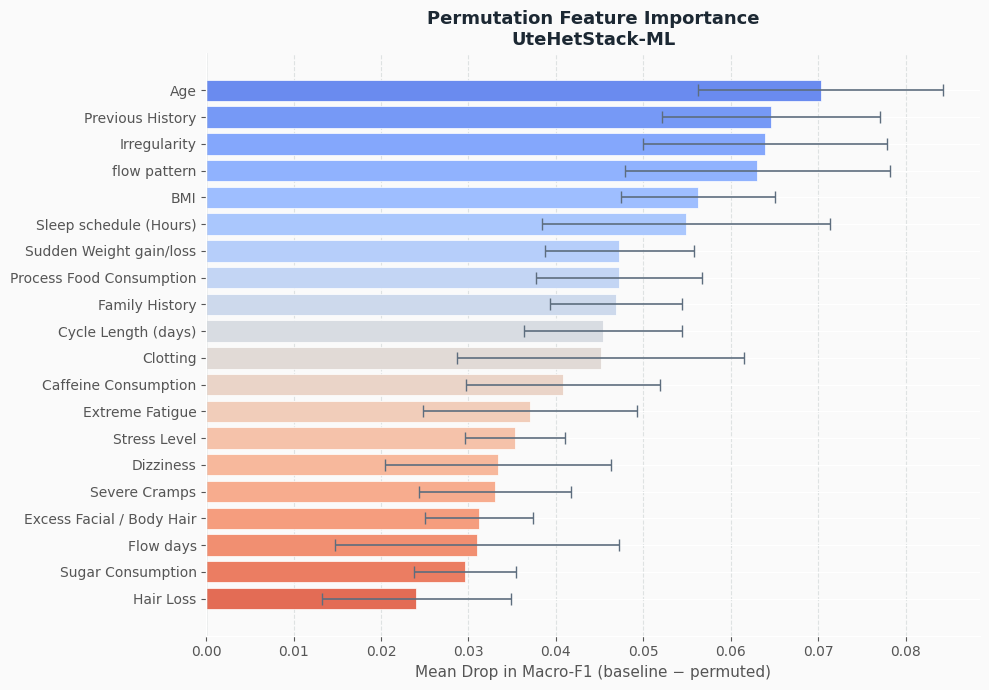

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Permutation Importance — Stacking Ensemble on X_te2 / Y_te2
# Metric: drop in Macro-F1 when each feature is randomly permuted
# We use the full MultiOutputClassifier (ensemble2) directly
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import warnings; warnings.filterwarnings('ignore')

X_te2_np = X_te2.values if hasattr(X_te2, 'values') else X_te2
Y_te2_np = Y_te2.values if hasattr(Y_te2, 'values') else Y_te2

# Baseline score
baseline_f1 = f1_score(Y_te2_np, y_pred_ens2, average='macro', zero_division=0)
print(f'Baseline Macro-F1: {baseline_f1:.4f}')

N_REPEATS    = 5
n_features   = X_te2_np.shape[1]
feat_names_pi = orig_feat_names
perm_scores  = np.zeros((n_features, N_REPEATS))

rng = np.random.default_rng(42)
for fi in range(n_features):
    for r in range(N_REPEATS):
        X_perm = X_te2_np.copy()
        X_perm[:, fi] = rng.permutation(X_perm[:, fi])
        y_perm_pred = ensemble2.predict(
            pd.DataFrame(X_perm, columns=orig_feat_names)
        )
        perm_scores[fi, r] = baseline_f1 - f1_score(
            Y_te2_np, y_perm_pred, average='macro', zero_division=0
        )
    if (fi + 1) % 5 == 0:
        print(f'  Feature {fi+1}/{n_features} done...')

perm_mean = perm_scores.mean(axis=1)
perm_std  = perm_scores.std(axis=1)

# ── Plot top-20 permutation importances ─────────────────────────────────
order = np.argsort(perm_mean)[::-1][:20]

fig_pi, ax_pi = plt.subplots(figsize=(10, 7), facecolor='#FAFAFA')
ax_pi.set_facecolor('#FAFAFA')
colors_pi = plt.cm.coolwarm(np.linspace(0.15, 0.85, len(order)))

ax_pi.barh(
    [feat_names_pi[i] for i in order[::-1]],
    perm_mean[order[::-1]],
    xerr=perm_std[order[::-1]],
    color=colors_pi[::-1],
    edgecolor='white',
    error_kw=dict(elinewidth=1.2, ecolor='#5D6D7E', capsize=4)
)
ax_pi.axvline(0, color='#AAB7B8', linewidth=1)
ax_pi.set_xlabel('Mean Drop in Macro-F1 (baseline − permuted)', fontsize=11)
ax_pi.set_title('Permutation Feature Importance\nUteHetStack-ML',
                fontsize=13, fontweight='bold', color='#1C2833')
for sp in ['top', 'right']:
    ax_pi.spines[sp].set_visible(False)
ax_pi.grid(axis='x', linestyle='--', alpha=0.35, color='#AAB7B8')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=140, bbox_inches='tight')
plt.show()


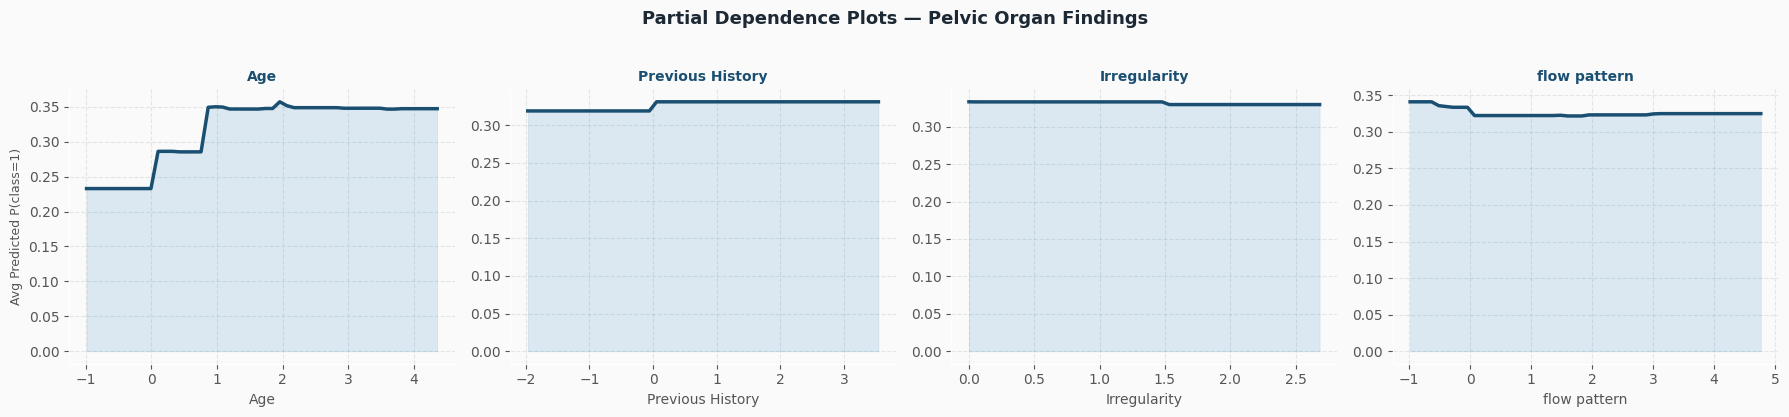

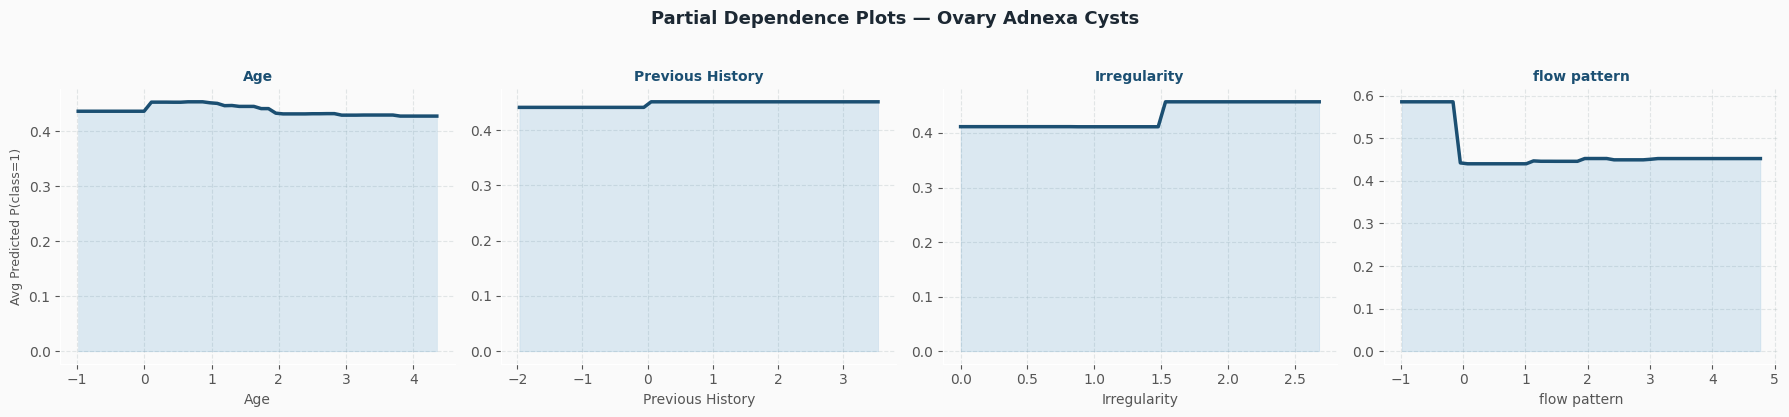

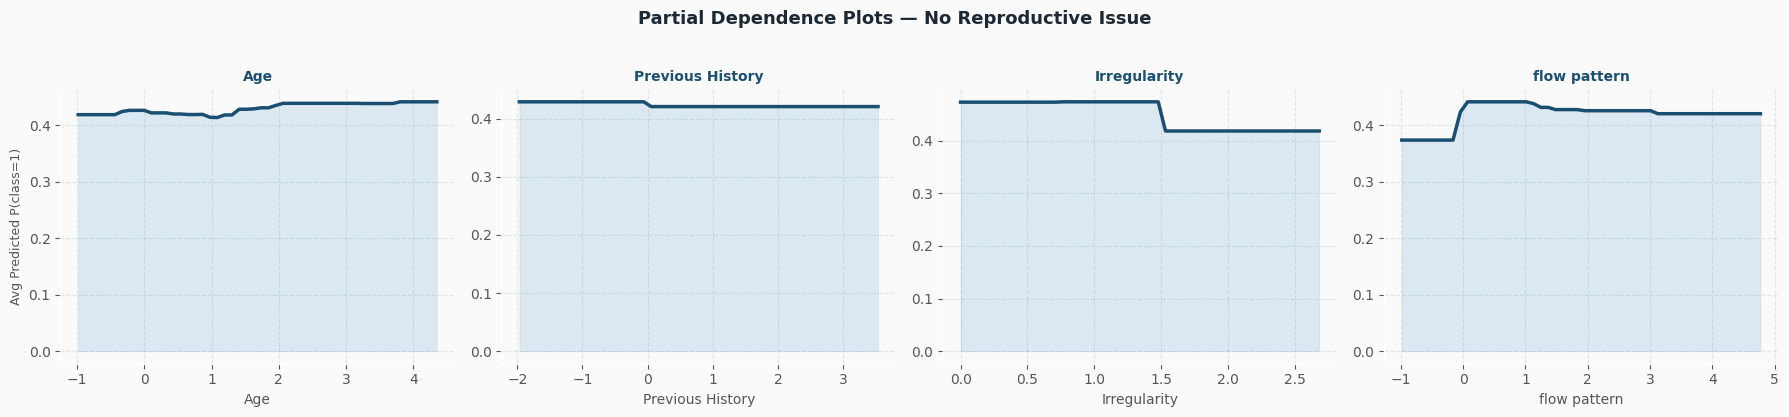

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PDP — Partial Dependence Plots for top-4 permutation-important features
# We use each per-label LightGBM meta-learner + the meta-feature matrix
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# ── PDP helper: manual computation for a meta-learner ───────────────────
def compute_pdp(meta_model, meta_X, feat_idx, n_grid=50):
    """
    Compute 1-D PDP for a single feature (feat_idx) on a LGBM meta-learner.
    Returns grid values and averaged probabilities.
    """
    grid   = np.linspace(meta_X[:, feat_idx].min(),
                         meta_X[:, feat_idx].max(), n_grid)
    pdp_vals = np.zeros(n_grid)
    for gi, gv in enumerate(grid):
        X_copy = meta_X.copy()
        X_copy[:, feat_idx] = gv
        try:
            proba = meta_model.predict_proba(X_copy)[:, 1]
        except Exception:
            proba = meta_model.predict(X_copy).astype(float)
        pdp_vals[gi] = proba.mean()
    return grid, pdp_vals

# Top-4 features by permutation importance (overall)
top4_feat_idx = order[:4]
top4_feat_names = [feat_names_pi[i] for i in top4_feat_idx]

# For PDP we need the meta-feature column indices that correspond to original features.
# The meta-feature matrix from stk.transform() has:
#   [stacked_proba_cols ... | original_feature_cols (if passthrough)]
# Get position of each original feature in the meta matrix

# stk.transform width
sample_meta = meta_test_all[0]   # shape (n_test, meta_width)
meta_width   = sample_meta.shape[1]
n_orig       = len(orig_feat_names)
n_stack      = meta_width - n_orig   # stacking columns count

# Map original feature idx → meta feature idx
def orig_to_meta_idx(fi_orig):
    return n_stack + fi_orig   # passthrough appends after stacked cols

# ── Plot 3×4 grid: 3 labels × 4 top features ───────────────────────────
n_top = len(top4_feat_idx)

for li, label_name in enumerate(CE_target_names):
    short = label_name.replace('group_','').replace('_',' ').title()
    stk   = ensemble2.estimators_[li]
    meta_te = meta_test_all[li]
    meta_model = stk.final_estimator_

    fig_pdp, axes_pdp = plt.subplots(1, n_top, figsize=(4.5*n_top, 4),
                                      facecolor='#FAFAFA')
    if n_top == 1:
        axes_pdp = [axes_pdp]

    for j, fi_orig in enumerate(top4_feat_idx):
        fi_meta = orig_to_meta_idx(fi_orig)
        if fi_meta >= meta_te.shape[1]:
            fi_meta = fi_orig % meta_te.shape[1]  # fallback

        grid, pdp_vals = compute_pdp(meta_model, meta_te, fi_meta)

        ax = axes_pdp[j]
        ax.set_facecolor('#FAFAFA')
        ax.plot(grid, pdp_vals, color='#1B4F72', linewidth=2.5)
        ax.fill_between(grid, pdp_vals, alpha=0.15, color='#2E86C1')
        ax.set_xlabel(feat_names_pi[fi_orig], fontsize=10)
        ax.set_ylabel('Avg Predicted P(class=1)' if j==0 else '', fontsize=9)
        ax.set_title(feat_names_pi[fi_orig], fontsize=10, fontweight='bold',
                     color='#1B4F72')
        ax.grid(linestyle='--', alpha=0.3, color='#AAB7B8')
        for sp in ['top','right']:
            ax.spines[sp].set_visible(False)

    fig_pdp.suptitle(f'Partial Dependence Plots — {short}',
                     fontsize=13, fontweight='bold', color='#1C2833', y=1.03)
    plt.tight_layout()
    plt.savefig(f'pdp_label{li}.png', dpi=130, bbox_inches='tight')
    plt.show()


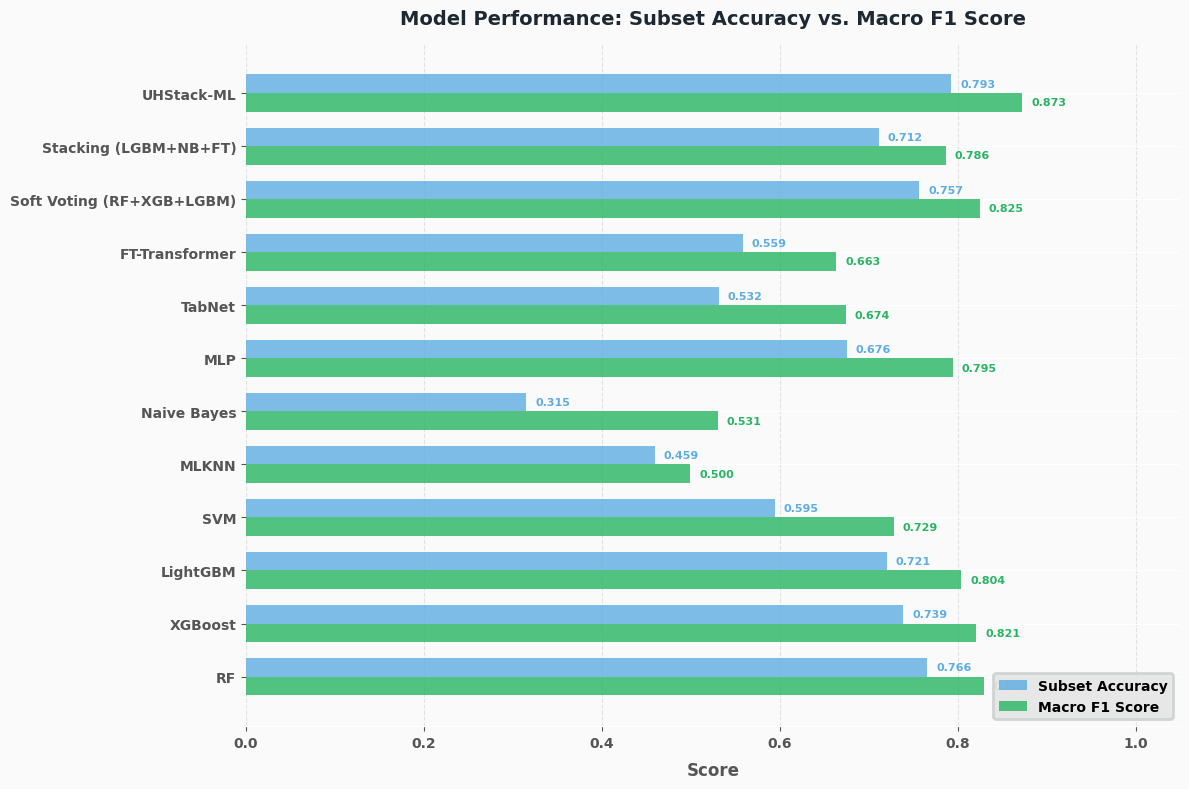

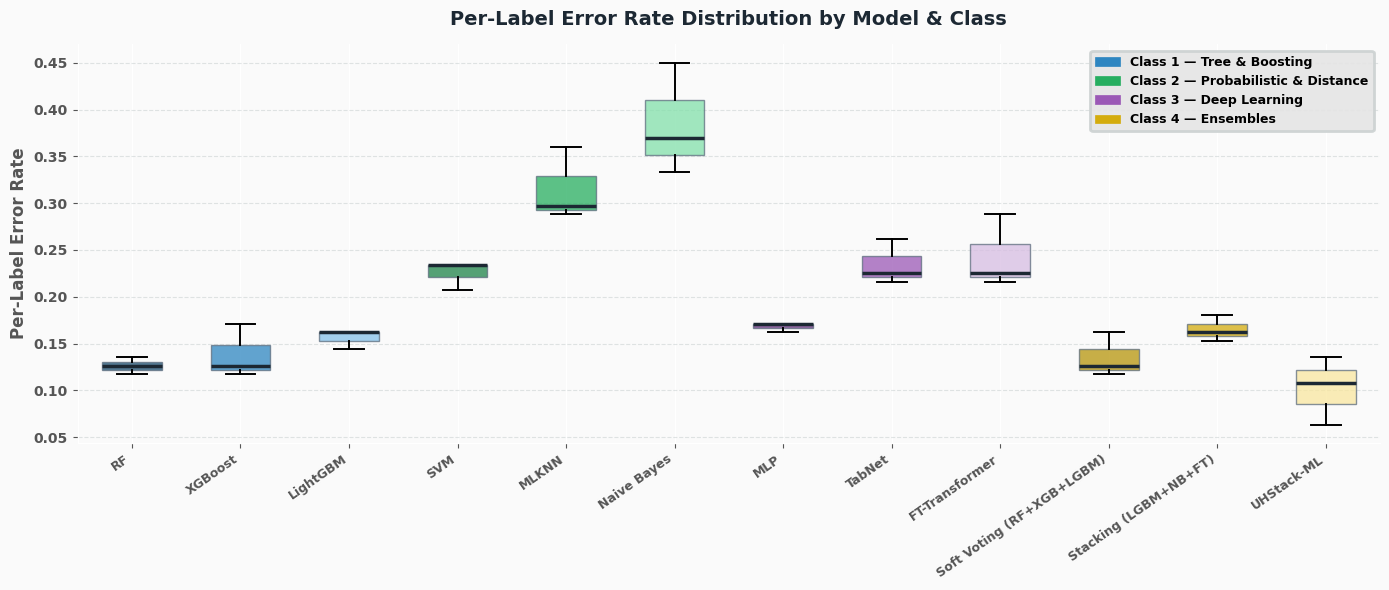

In [ ]:
# ───────────────────────────────────────────────
# STEP 2 — Combined Plot (Subset Accuracy & Macro F1) + Box Plot
# ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colour palettes per class ────────────────────────────
PALETTES = {
    1: ['#1B4F72', '#2E86C1', '#85C1E9'],          # Blues  — Class 1
    2: ['#1E8449', '#27AE60', '#82E0AA'],          # Greens — Class 2
    3: ['#6C3483', '#9B59B6', '#D7BDE2'],          # Purples — Class 3
    4: ['#B7950B', '#D4AC0D', '#F9E79F'],          # Golds  — Class 4
}

# Build per-model colour list
class_model_counter = {1:0, 2:0, 3:0, 4:0}
bar_colors_main = []
for cls in cmp_df['Class']:
    idx = class_model_counter[cls]
    bar_colors_main.append(PALETTES[cls][idx % len(PALETTES[cls])])
    class_model_counter[cls] += 1

N = len(cmp_df)
y_pos = np.arange(N)
labels = [n.replace('\n', ' ') for n in cmp_df['Model']]

legend_patches = [
    mpatches.Patch(color=PALETTES[1][1], label='Class 1 — Tree & Boosting'),
    mpatches.Patch(color=PALETTES[2][1], label='Class 2 — Probabilistic & Distance'),
    mpatches.Patch(color=PALETTES[3][1], label='Class 3 — Deep Learning'),
    mpatches.Patch(color=PALETTES[4][1], label='Class 4 — Ensembles'),
]

# ──────────────────────────────────
# FIG 1: Combined Grouped Bar Chart — Subset Accuracy & Macro F1
# ──────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 8), facecolor='#FAFAFA')
ax1.set_facecolor('#FAFAFA')

bar_width = 0.35
index = np.arange(N)

# Plotting Subset Accuracy
rects1 = ax1.barh(index + bar_width/2, cmp_df['Subset Acc'], bar_width, label='Subset Accuracy', color='#5DADE2', alpha=0.8)
# Plotting Macro F1
rects2 = ax1.barh(index - bar_width/2, cmp_df['Macro F1'], bar_width, label='Macro F1 Score', color='#28B463', alpha=0.8)

ax1.set_yticks(index)
ax1.set_yticklabels(labels, fontsize=10, fontweight='bold')
ax1.set_xlabel('Score', fontsize=12, labelpad=8, fontweight='bold')
ax1.set_title('Model Performance: Subset Accuracy vs. Macro F1 Score', fontsize=14, fontweight='bold', color='#1C2833', pad=14)
ax1.set_xlim(0, 1.05)
ax1.grid(axis='x', linestyle='--', alpha=0.35, color='#AAB7B8')
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9, edgecolor='#CCD1D1').get_frame().set_linewidth(2)

for i, rect in enumerate(rects1):
    ax1.text(rect.get_width() + 0.01, rect.get_y() + rect.get_height()/2, f'{cmp_df["Subset Acc"].iloc[i]:.3f}', ha='left', va='center', fontsize=8, color='#5DADE2', fontweight='bold')
for i, rect in enumerate(rects2):
    ax1.text(rect.get_width() + 0.01, rect.get_y() + rect.get_height()/2, f'{cmp_df["Macro F1"].iloc[i]:.3f}', ha='left', va='center', fontsize=8, color='#28B463', fontweight='bold')

for sp in ['top','right','left']:
    ax1.spines[sp].set_visible(False)

# Make x-tick labels bold
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')

# Make legend text bold
for text in ax1.get_legend().get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('combined_subset_acc_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()


# ──────────────────────────────
# FIG 2: Box Plot — Per-Label Error Rate
# ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6), facecolor='#FAFAFA')
ax2.set_facecolor('#FAFAFA')

bp = ax2.boxplot(
    error_rates,
    vert=True,
    patch_artist=True,
    notch=False,
    widths=0.55,
    medianprops=dict(color='#1C2833', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=5, alpha=0.6)
)

for patch, c in zip(bp['boxes'], bar_colors_main):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
    patch.set_edgecolor('#5D6D7E')

# Colour fliers to match box
flier_idx = 0
for flier, c in zip(bp['fliers'], bar_colors_main):
    flier.set_markerfacecolor(c)
    flier.set_markeredgecolor(c)

ax2.set_xticks(range(1, N+1))
ax2.set_xticklabels(labels, rotation=35, ha='right', fontsize=9, fontweight='bold')
ax2.set_ylabel('Per-Label Error Rate', fontsize=12, fontweight='bold')
ax2.set_title('Per-Label Error Rate Distribution by Model & Class',
              fontsize=14, fontweight='bold', color='#1C2833', pad=14)
ax2.grid(axis='y', linestyle='--', alpha=0.35, color='#AAB7B8')
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
ax2.legend(handles=legend_patches, loc='upper right', fontsize=9,
           framealpha=0.9, edgecolor='#CCD1D1').get_frame().set_linewidth(2)

# Make x-tick labels bold
for label in ax2.get_xticklabels():
    label.set_fontweight('bold')

# Make y-tick labels bold
for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

# Make legend text bold
for text in ax2.get_legend().get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('boxplot_error_rate.png', dpi=150, bbox_inches='tight')
plt.show()
